# SVM

El objetivo es utilizar SVM para clasificación de tumores mamarios (malignos o benignos).

#### Bibliotecas

In [1]:
#General
import numpy as np
import pandas as pd
from skimpy import skim


#Graficas
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import andrews_curves

from matplotlib.colors import ListedColormap

from plotnine import ggplot, aes, geom_boxplot, geom_density, facet_wrap, theme_bw, labs, ggtitle

#Valores atipicos
from pyod.models.mcd import MCD

#Modelo de clasificacion
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.decomposition import PCA

#### Opciones globables

In [2]:
np.random.seed(1989)

In [3]:
pd.options.display.float_format = '{:,.3f}'.format

In [4]:
%matplotlib inline

## Carga de datos

In [5]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

df = pd.concat([X,y], axis = 1)
df["Diagnosis"] = df["Diagnosis"].astype("category")

In [6]:
df

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.990,10.380,122.800,"1,001.000",0.118,0.278,0.300,0.147,0.242,0.079,...,17.330,184.600,"2,019.000",0.162,0.666,0.712,0.265,0.460,0.119,M
1,20.570,17.770,132.900,"1,326.000",0.085,0.079,0.087,0.070,0.181,0.057,...,23.410,158.800,"1,956.000",0.124,0.187,0.242,0.186,0.275,0.089,M
2,19.690,21.250,130.000,"1,203.000",0.110,0.160,0.197,0.128,0.207,0.060,...,25.530,152.500,"1,709.000",0.144,0.424,0.450,0.243,0.361,0.088,M
3,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,...,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,M
4,20.290,14.340,135.100,"1,297.000",0.100,0.133,0.198,0.104,0.181,0.059,...,16.670,152.200,"1,575.000",0.137,0.205,0.400,0.163,0.236,0.077,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.560,22.390,142.000,"1,479.000",0.111,0.116,0.244,0.139,0.173,0.056,...,26.400,166.100,"2,027.000",0.141,0.211,0.411,0.222,0.206,0.071,M
565,20.130,28.250,131.200,"1,261.000",0.098,0.103,0.144,0.098,0.175,0.055,...,38.250,155.000,"1,731.000",0.117,0.192,0.322,0.163,0.257,0.066,M
566,16.600,28.080,108.300,858.100,0.085,0.102,0.093,0.053,0.159,0.056,...,34.120,126.700,"1,124.000",0.114,0.309,0.340,0.142,0.222,0.078,M
567,20.600,29.330,140.100,"1,265.000",0.118,0.277,0.351,0.152,0.240,0.070,...,39.420,184.600,"1,821.000",0.165,0.868,0.939,0.265,0.409,0.124,M


In [7]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 569    │ │ float64     │ 30    │ │ Diagnosis             │                                │
│ │ Number of columns │ 31     │ │ category    │ 1     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column    ┃ NA ┃ NA % ┃ mean     ┃ sd       ┃ p0       ┃ p25      ┃ p50      ┃ p75      ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ radius1   │  0 │    0 │    14.13 │    3.524 │    6.981 │     11.7 │    13.37 │    15.78 │   28.11 │  ▂▇▃▂  │  │
│ │ texture1  │  0 │    0 │    19.29 │    4.301 │     9.71 │    16.17 │    18.84 │     21.8 │   39.28 │  ▂▇▆▂  │  │
│ │ perimeter │  0 │    0 │    91.97 │     24.3 │    43.79 │    75.17 │    86.24 │    104.1 │   188.5 │  ▂▇▃▂  │  │
│ │ 1         │    │      │          │          │          │          │          │          │         │        │  │
│ │ area1     │  0 │    0 │    654.9 │    351.9 │    143.5 │    420.3 │    551.1 │    782.7 │    2501 │  ▇▆▂▁  │  │
│ │ smoothnes │  0 │    0 │  0.09636 │  0.01406 │  0.05263 │  0.08637 │  0.09587 │   0.1053 │  0.1634 │   ▅▇▃  │  │
│ │ s1        │    │      │          │          │          │          │          │          │         │        │  │
│ │ compactne │  0 │    0 │   0.1043 │  0.05281 │  0.01938 │  0.06492 │  0.09263 │   0.1304 │  0.3454 │  ▇▇▃▁  │  │
│ │ ss1       │    │      │          │          │          │          │          │          │         │        │  │
│ │ concavity │  0 │    0 │   0.0888 │  0.07972 │        0 │  0.02956 │  0.06154 │   0.1307 │  0.4268 │  ▇▃▂▁  │  │
│ │ 1         │    │      │          │          │          │          │          │          │         │        │  │
│ │ concave_p │  0 │    0 │  0.04892 │   0.0388 │        0 │  0.02031 │   0.0335 │    0.074 │  0.2012 │  ▇▃▃▁  │  │
│ │ oints1    │    │      │          │          │          │          │          │          │         │        │  │
│ │ symmetry1 │  0 │    0 │   0.1812 │  0.02741 │    0.106 │   0.1619 │   0.1792 │   0.1957 │   0.304 │ ▁▇▇▂▁  │  │
│ │ fractal_d │  0 │    0 │   0.0628 │  0.00706 │  0.04996 │   0.0577 │  0.06154 │  0.06612 │ 0.09744 │  ▅▇▃▁  │  │
│ │ imension1 │    │      │          │          │          │          │          │          │         │        │  │
│ │ radius2   │  0 │    0 │   0.4052 │   0.2773 │   0.1115 │   0.2324 │   0.3242 │   0.4789 │   2.873 │   ▇▁   │  │
│ │ texture2  │  0 │    0 │    1.217 │   0.5516 │   0.3602 │   0.8339 │    1.108 │    1.474 │   4.885 │  ▇▆▁   │  │
│ │ perimeter │  0 │    0 │    2.866 │    2.022 │    0.757 │    1.606 │    2.287 │    3.357 │   21.98 │   ▇▁   │  │
│ │ 2         │    │      │          │          │          │          │          │          │         │        │  │
│ │ area2     │  0 │    0 │    40.34 │    45.49 │    6.802 │    17.85 │    24.53 │    45.19 │   542.2 │   ▇▁   │  │
│ │ smoothnes │  0 │    0 │ 0.007041 │ 0.003003 │ 0.001713 │ 0.005169 │  0.00638 │ 0.008146 │ 0.03113 │  ▇▆▁   │  │
│ │ s2        │    │      │          │          │       

Se calculan diez características de valor real para cada núcleo celular:

	a) radio (media de las distancias desde el centro a los puntos del perímetro)
	b) textura (desviación estándar de los valores de la escala de grises)
	c) perímetro
	d) área
	e) suavidad (variación local en las longitudes de los radios)
	f) compacidad (perímetro^2 / área - 1,0)
	g) concavidad (severidad de las porciones cóncavas del contorno)
	h) puntos cóncavos (número de porciones cóncavas del contorno)
	i) simetría 
	j) dimensión fractal ("aproximación de la línea frontera" - 1)

## EDA

In [8]:
var_cat = ["Diagnosis"]
var_num = list(set(df.columns) - set(var_cat))

In [9]:
df["Diagnosis"].value_counts(normalize = True)

Diagnosis
B   0.627
M   0.373
Name: proportion, dtype: float64

In [10]:
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars):
        self.df = df
        self.num_vars = num_vars

    # Método para graficar variables numéricas 
    def plot_num(self, explicativa=None):
        for var in self.num_vars:
            if explicativa and explicativa in self.df.columns:
                # Boxplot por categoría
                p1 = (
                    ggplot(self.df, aes(x=explicativa, y=var, fill=explicativa))
                    + geom_boxplot(alpha=0.6, outlier_color="red")
                    + theme_bw()
                    + labs(title=f"Boxplot {var}", x=explicativa, y=var)
                )

                # Densidad por categoría
                p2 = (
                    ggplot(self.df, aes(x=var, fill=explicativa))
                    + geom_density(alpha=0.6)
                    + theme_bw()
                    + labs(title=f"Densidad {var}", x=var, y="Densidad")
                )

            else:
                # Boxplot simple
                p1 = (
                    ggplot(self.df, aes(y=var))
                    + geom_boxplot(fill="#de3163", alpha=0.6)
                    + theme_bw()
                    + labs(title=f"Boxplot de {var}", y=var)
                )

                # Densidad simple
                p2 = (
                    ggplot(self.df, aes(x=var))
                    + geom_density(fill="#31deac", alpha=0.6)
                    + theme_bw()
                    + labs(title=f"Densidad de {var}", x=var, y="Densidad")
                )

            # Mostrar gráficos
            display(p1)
            display(p2)

    # Método para graficar la matriz de correlación
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        plt.figure(figsize=(16, 12))
        sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")
        plt.title("Matriz de Correlación")
        plt.show()

In [11]:
analisis = analyze(df, var_num)

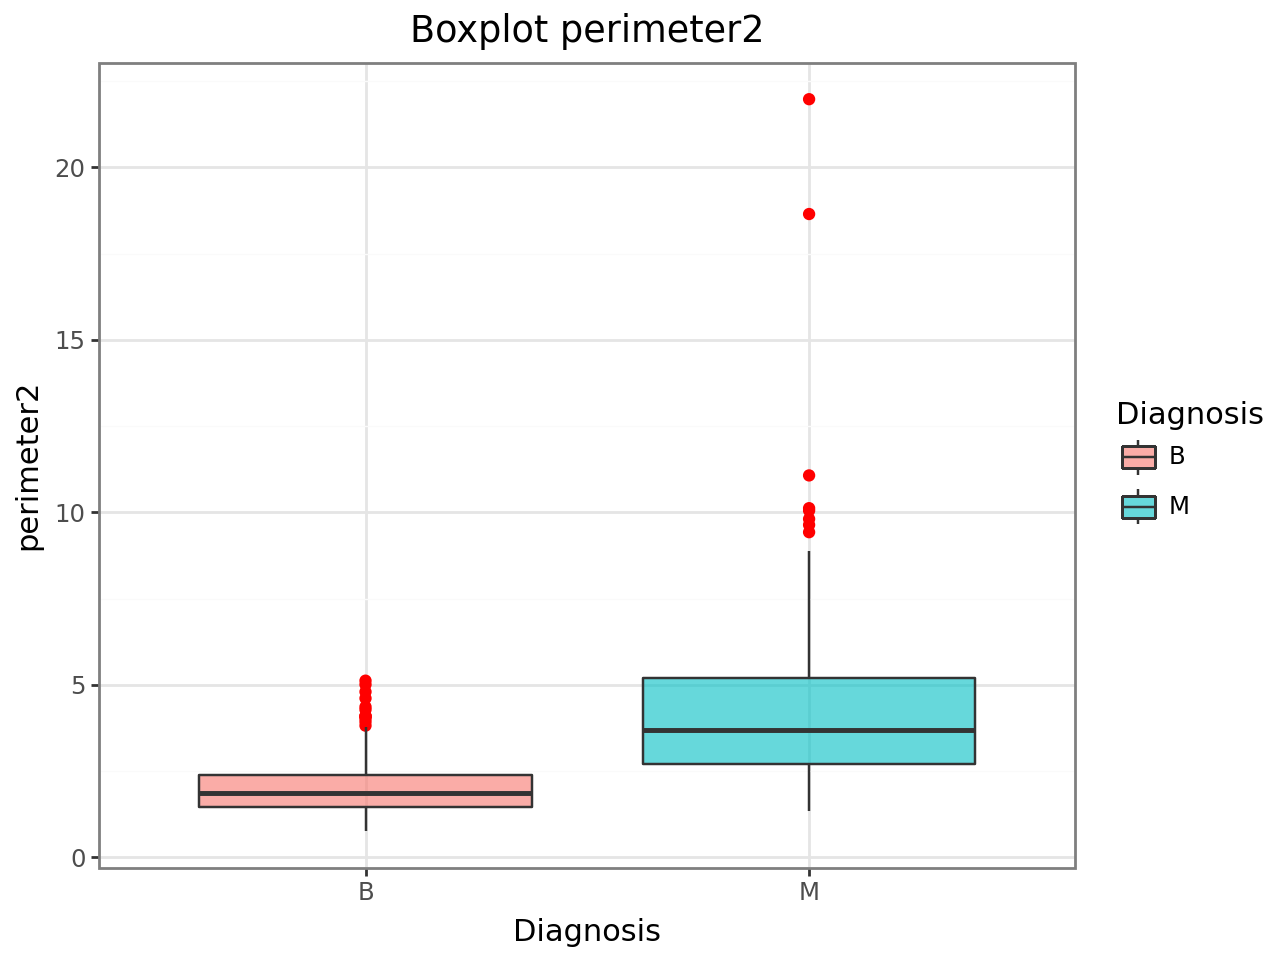

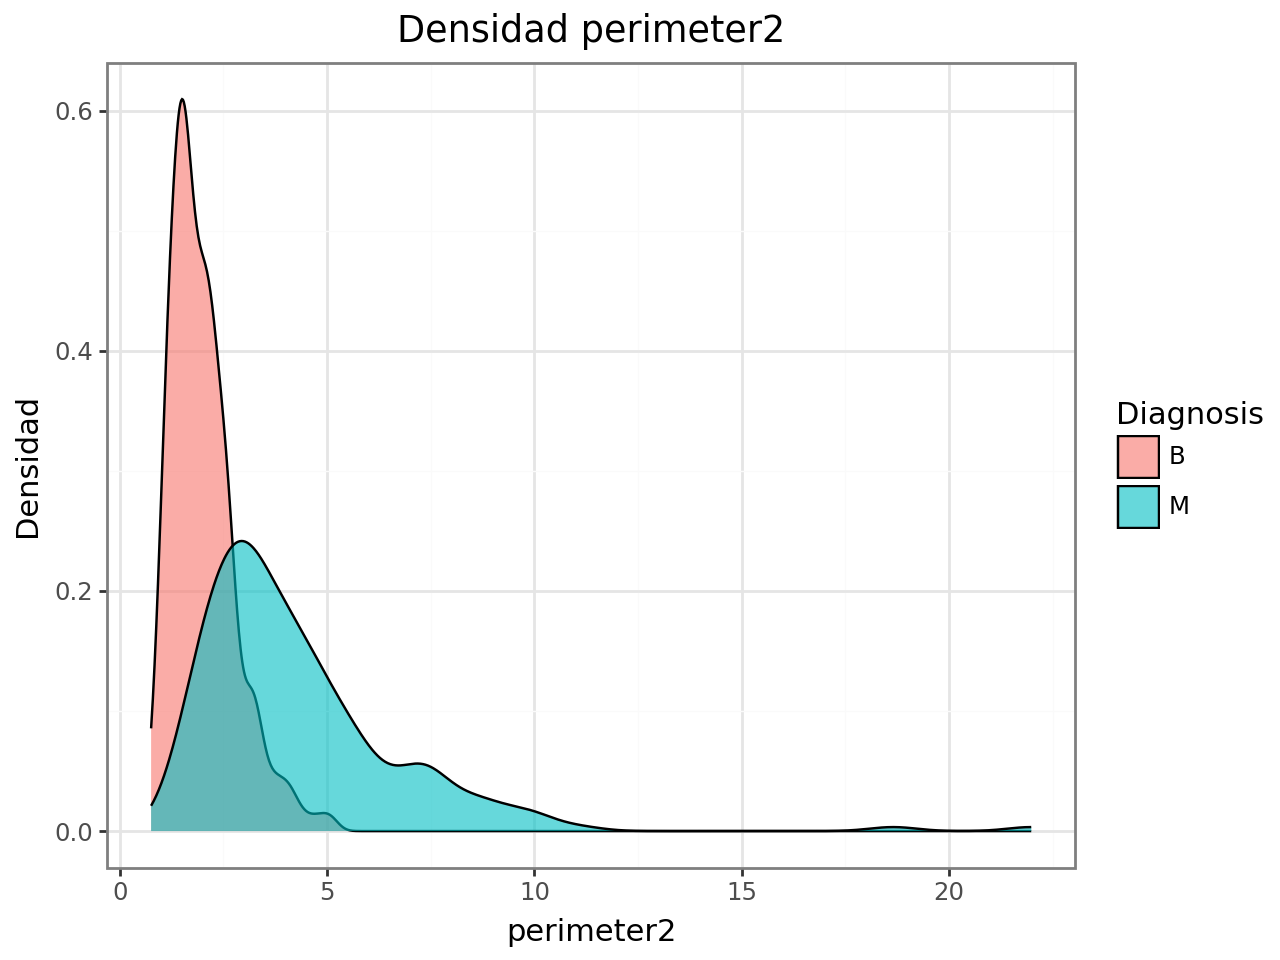

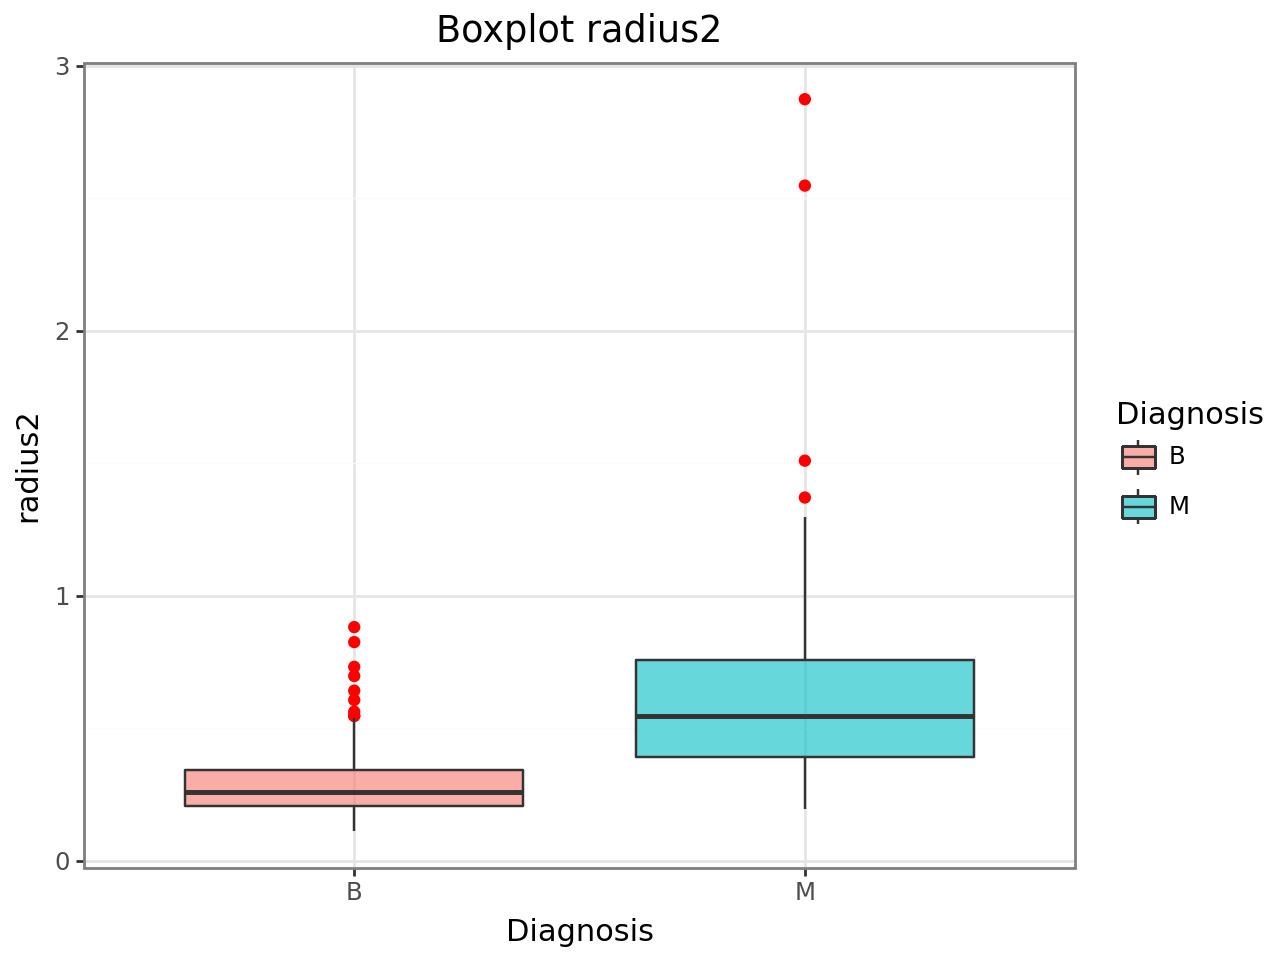

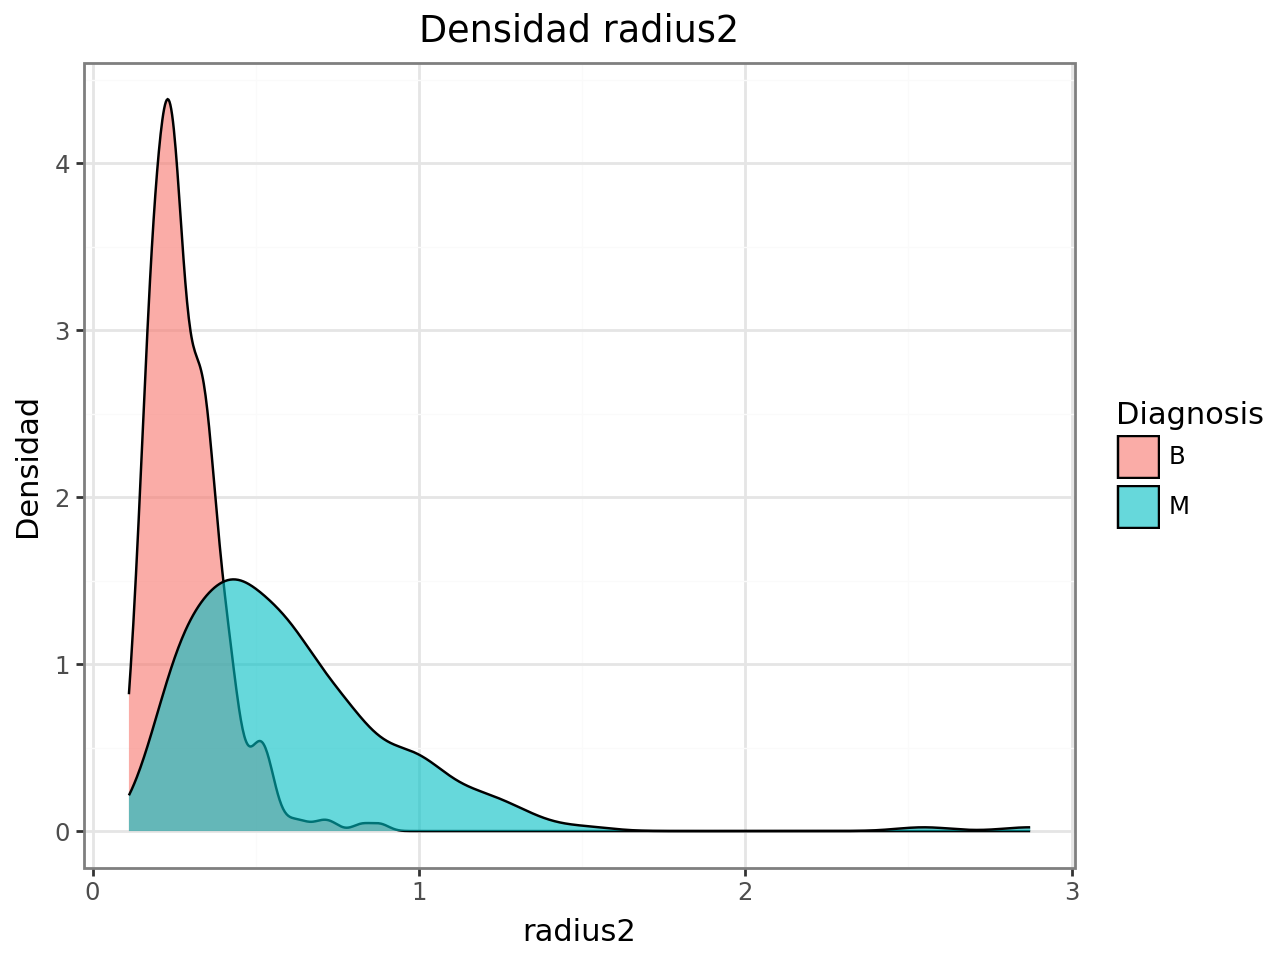

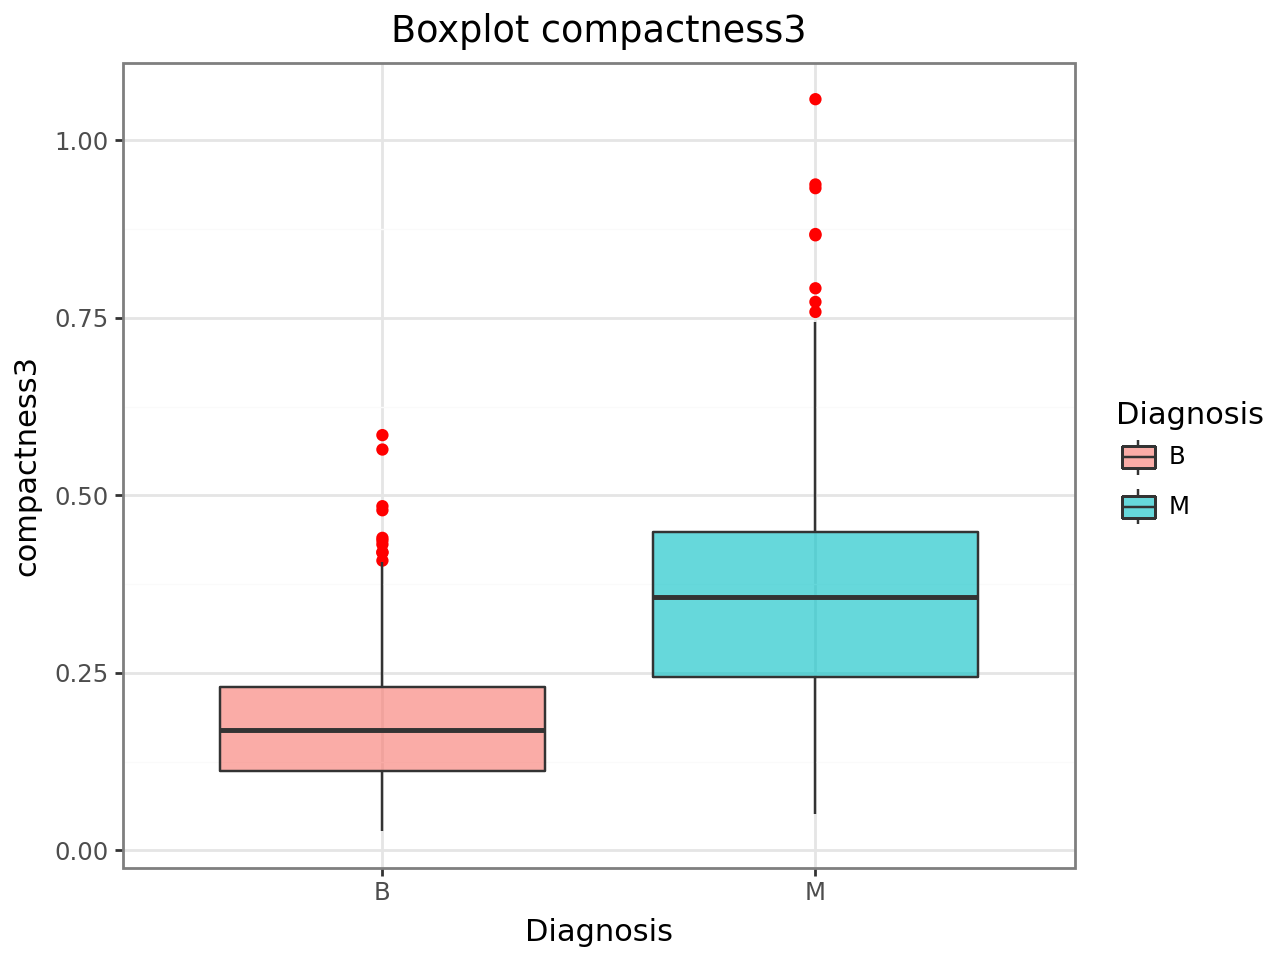

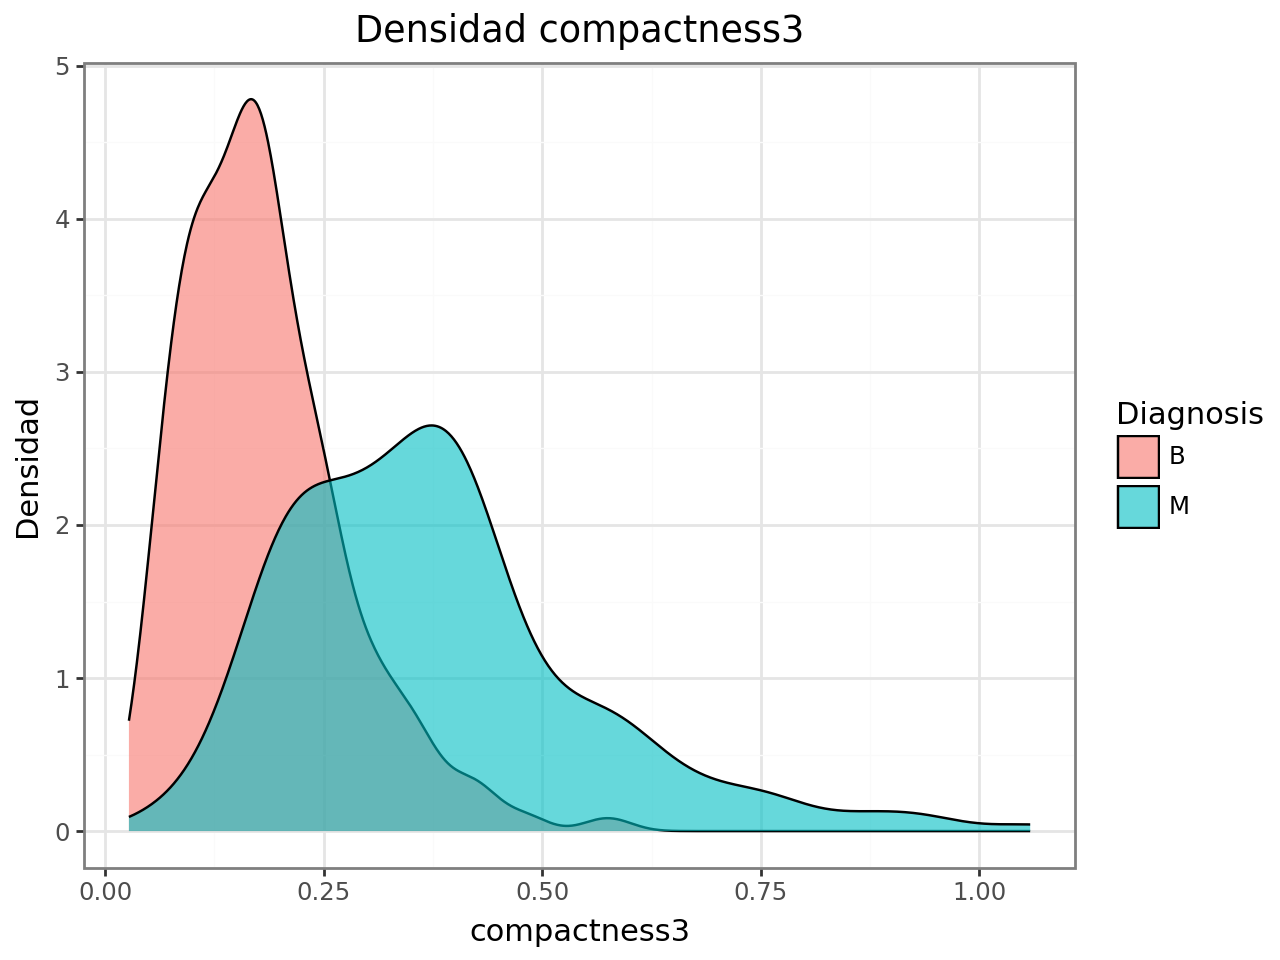

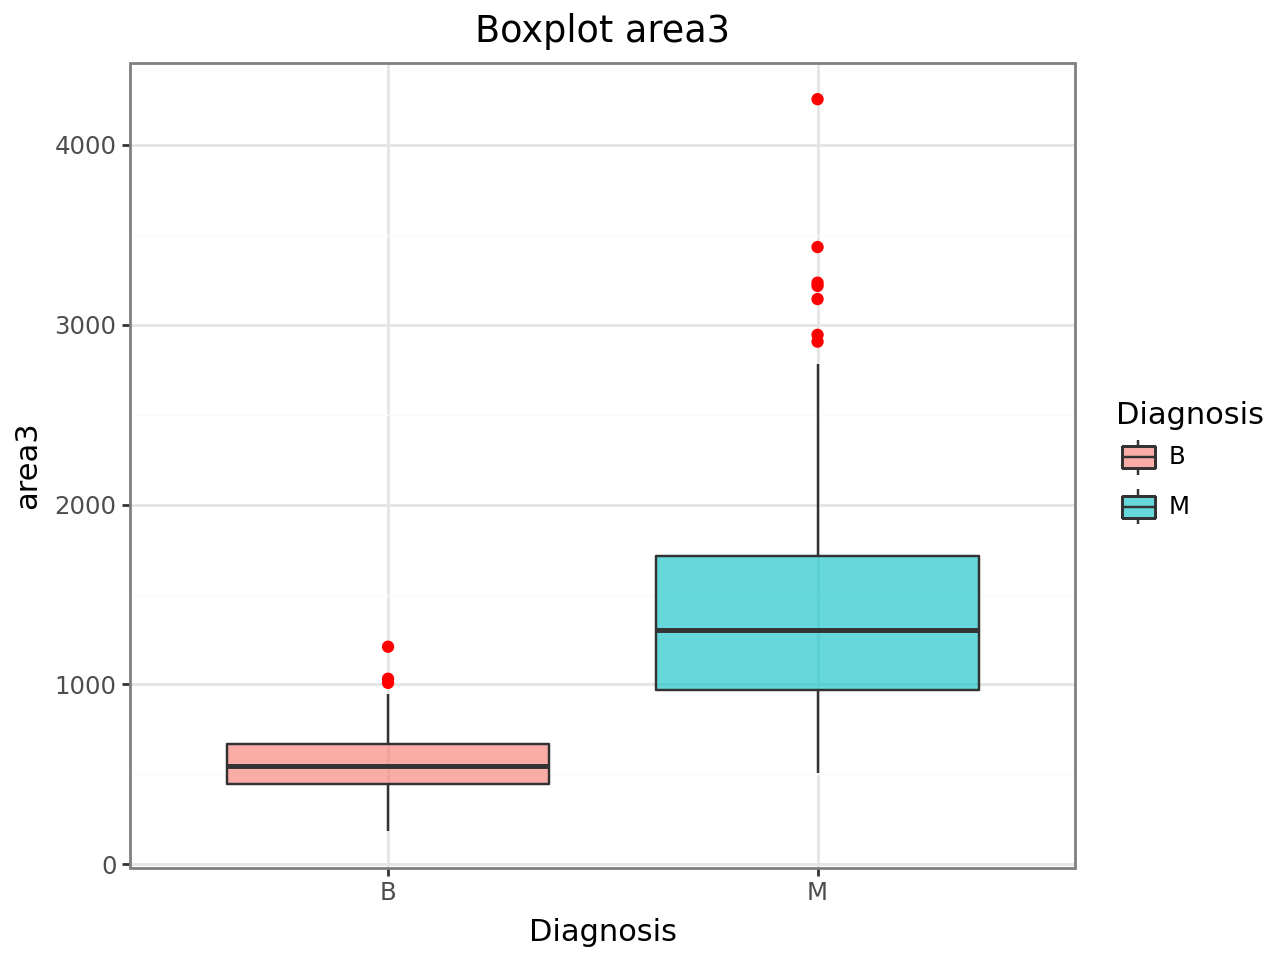

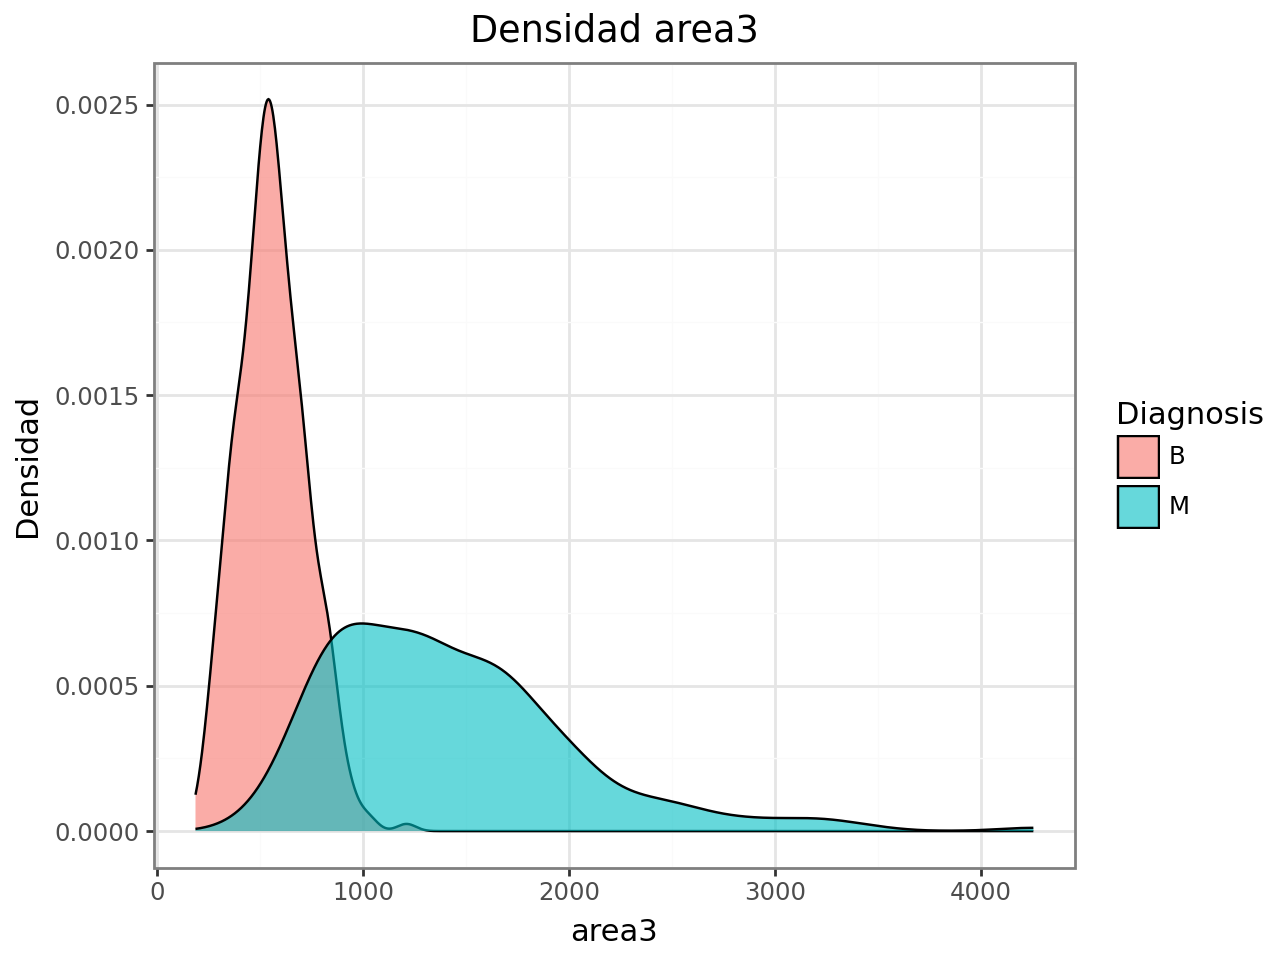

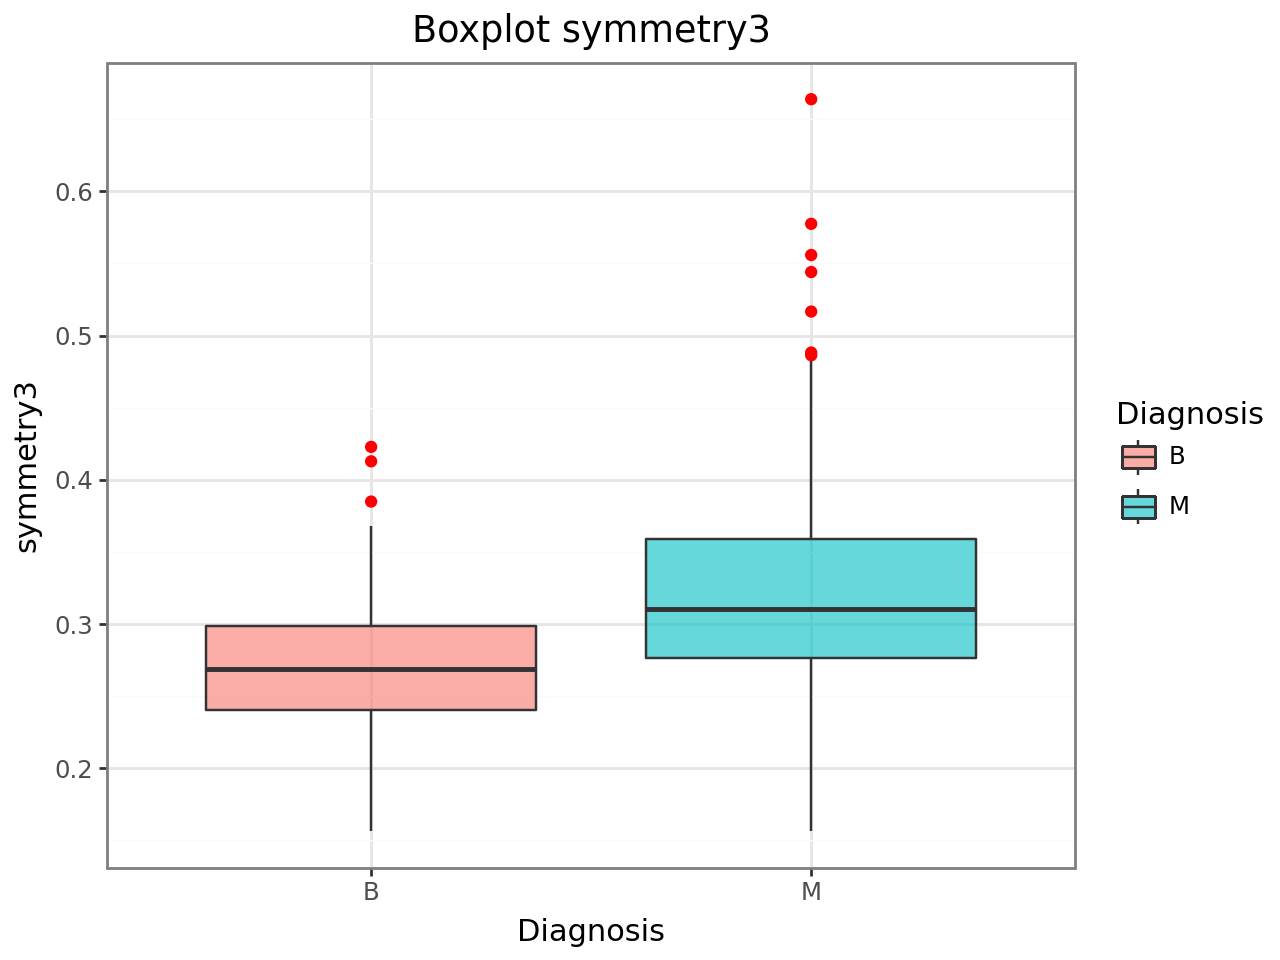

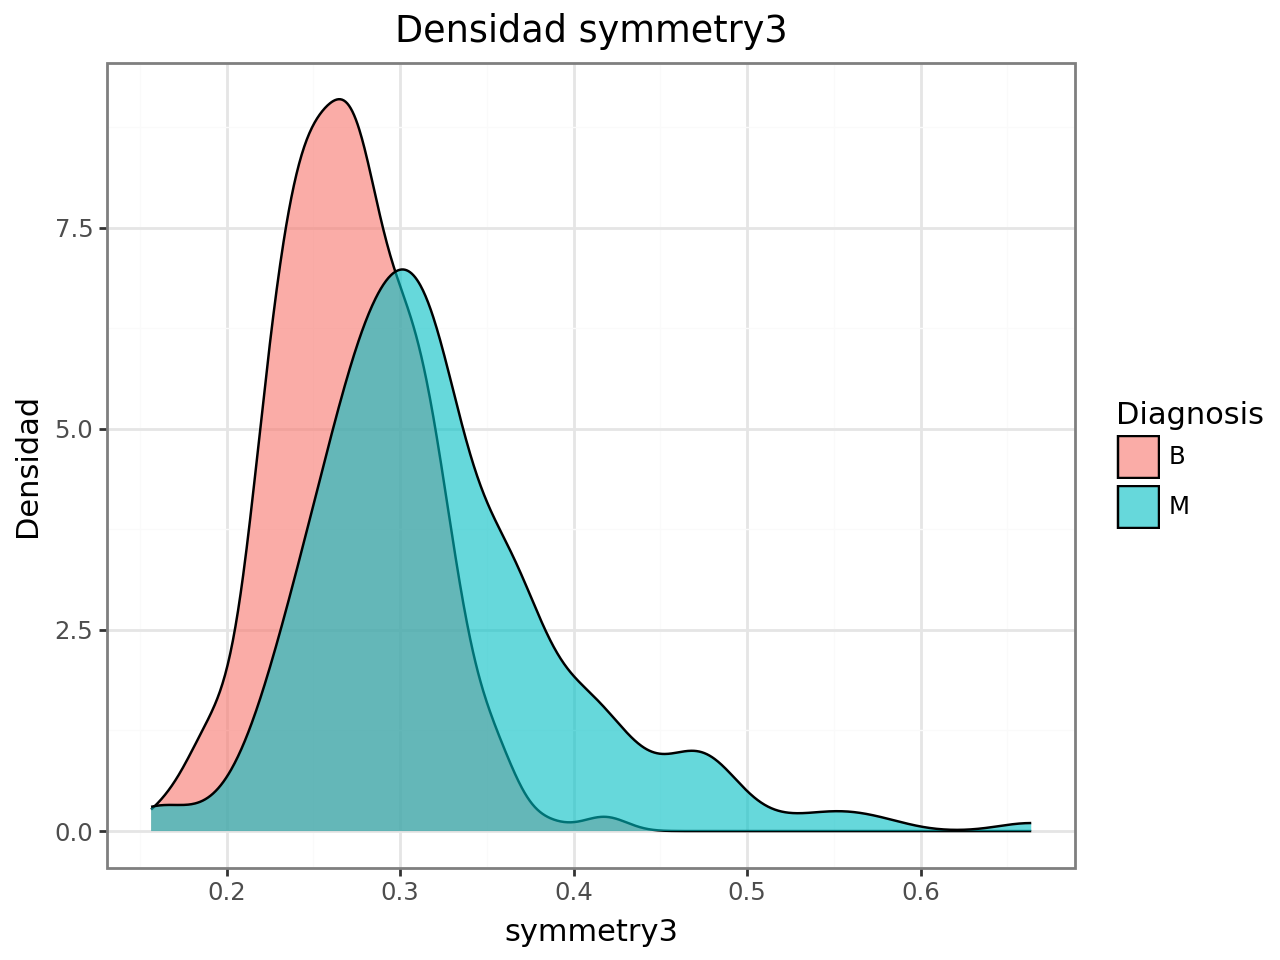

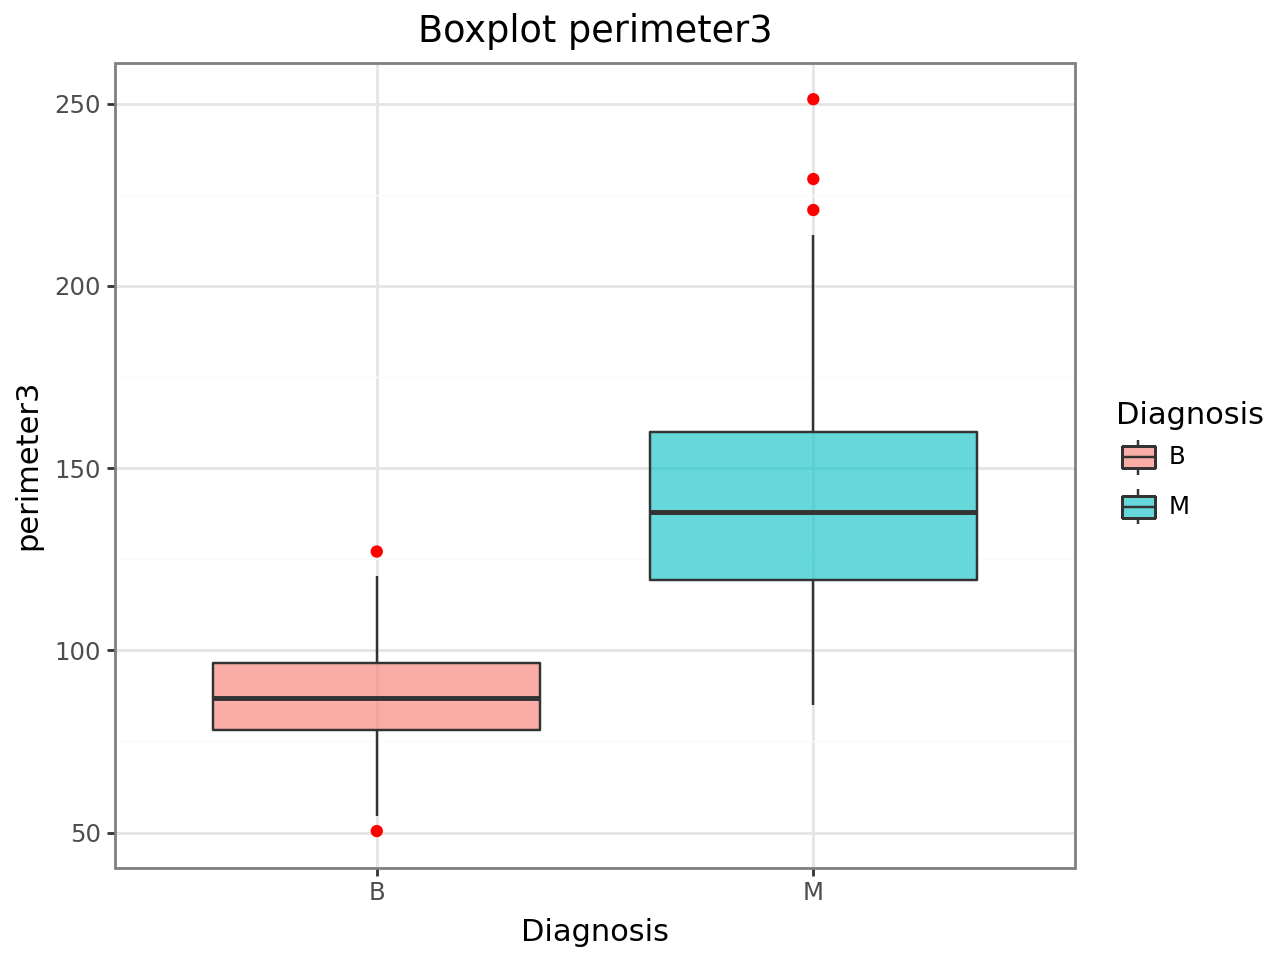

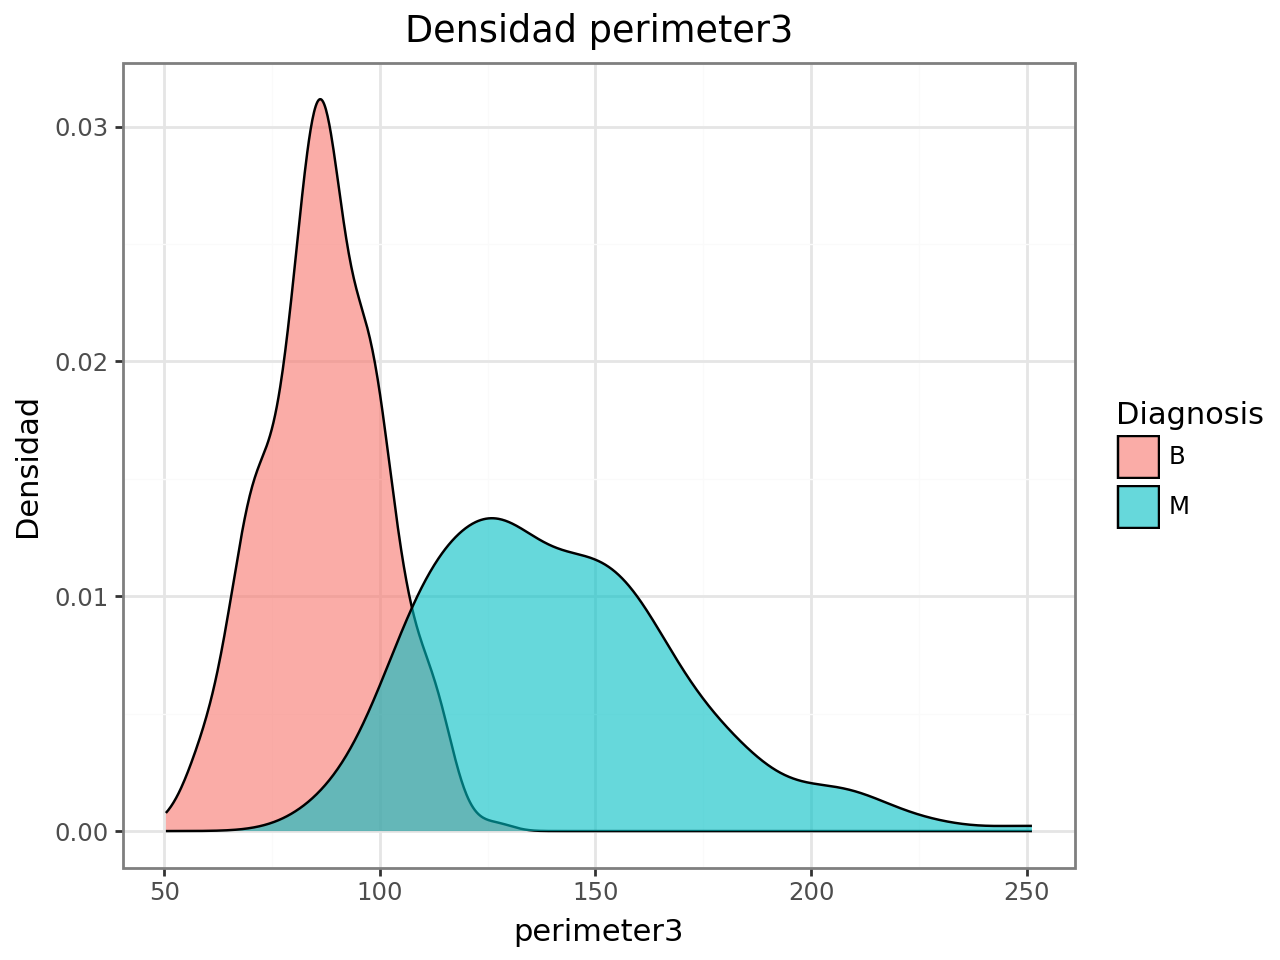

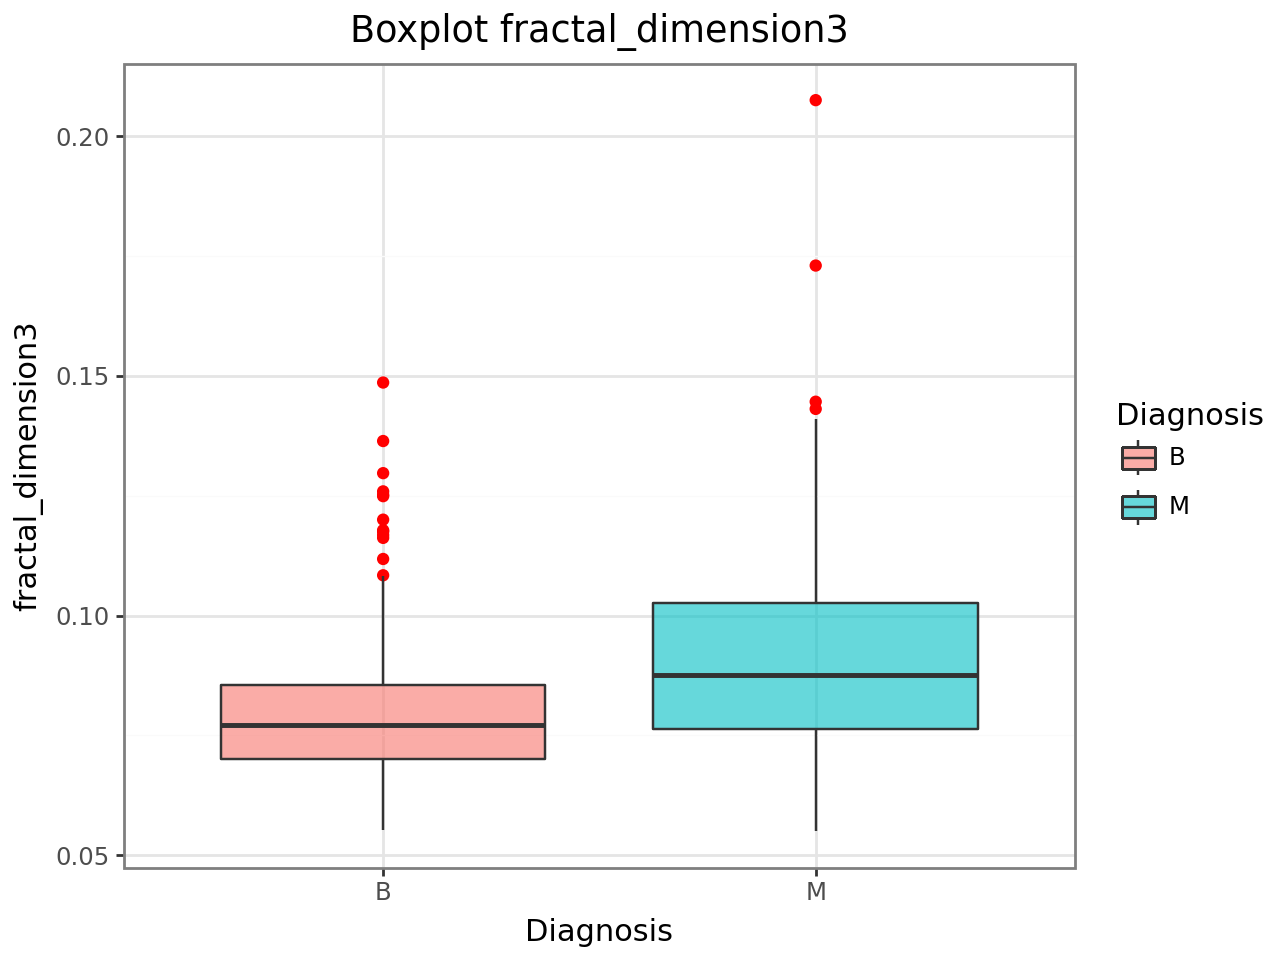

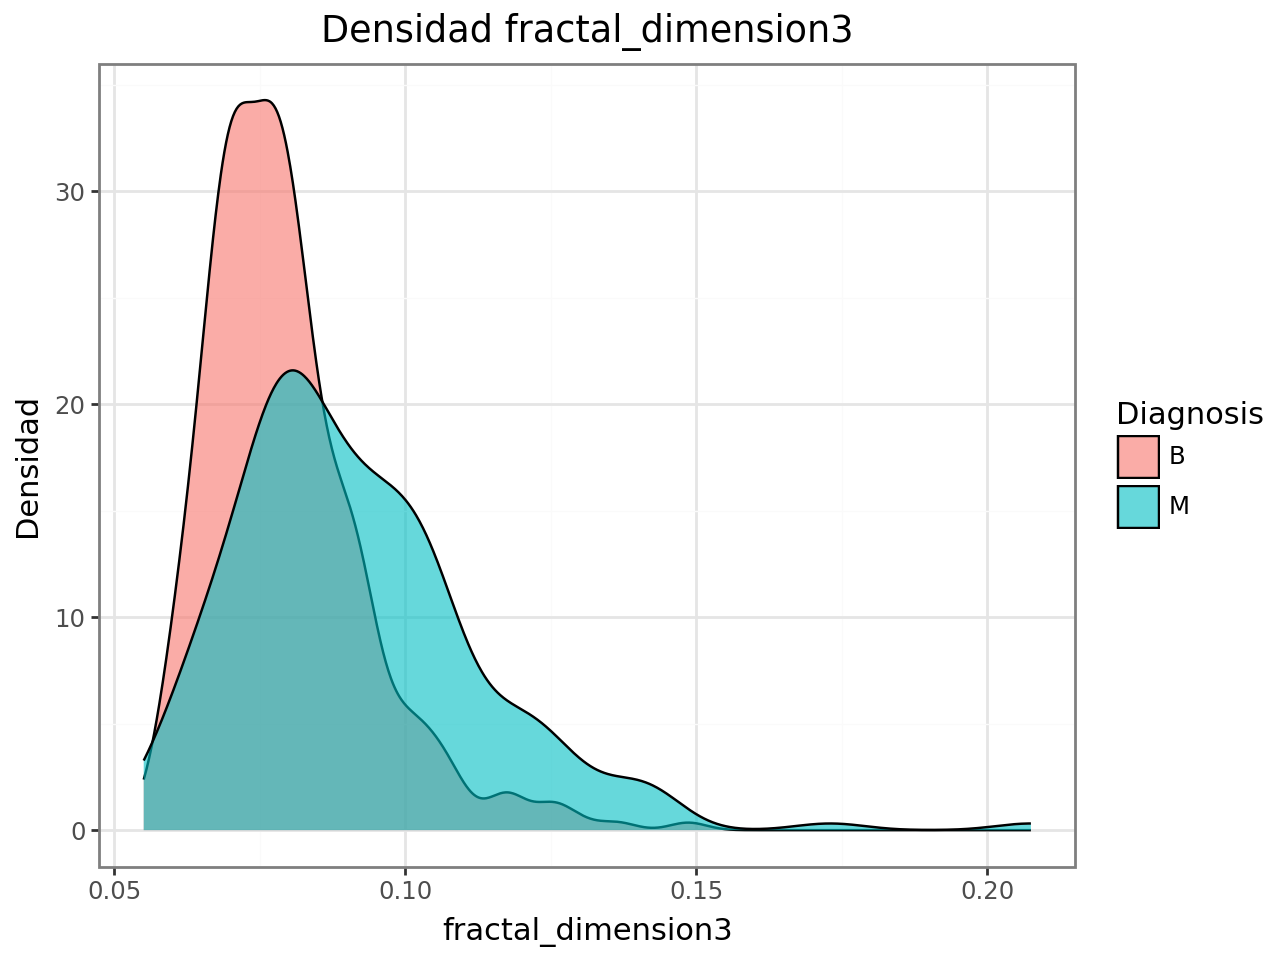

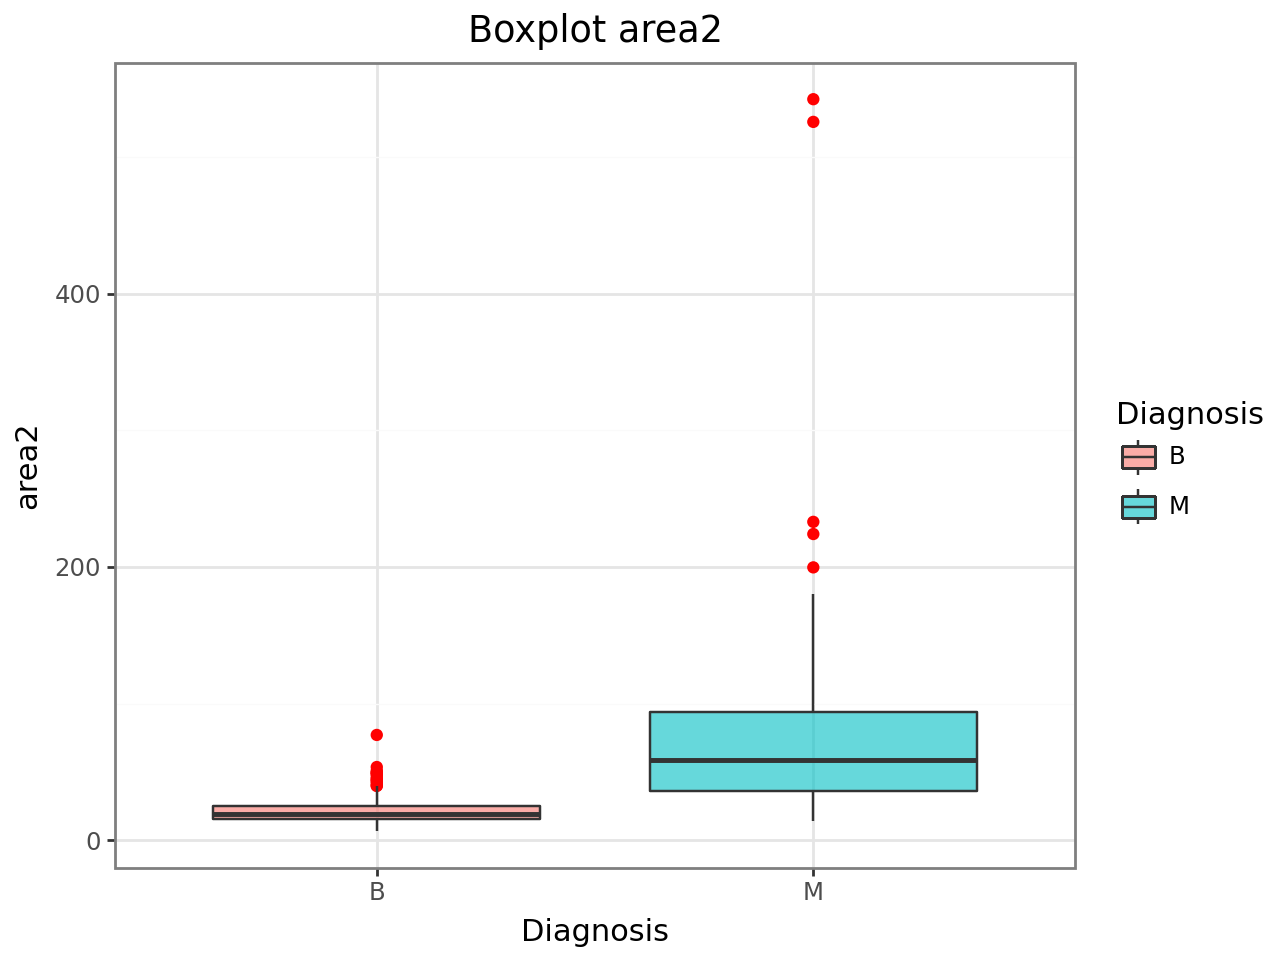

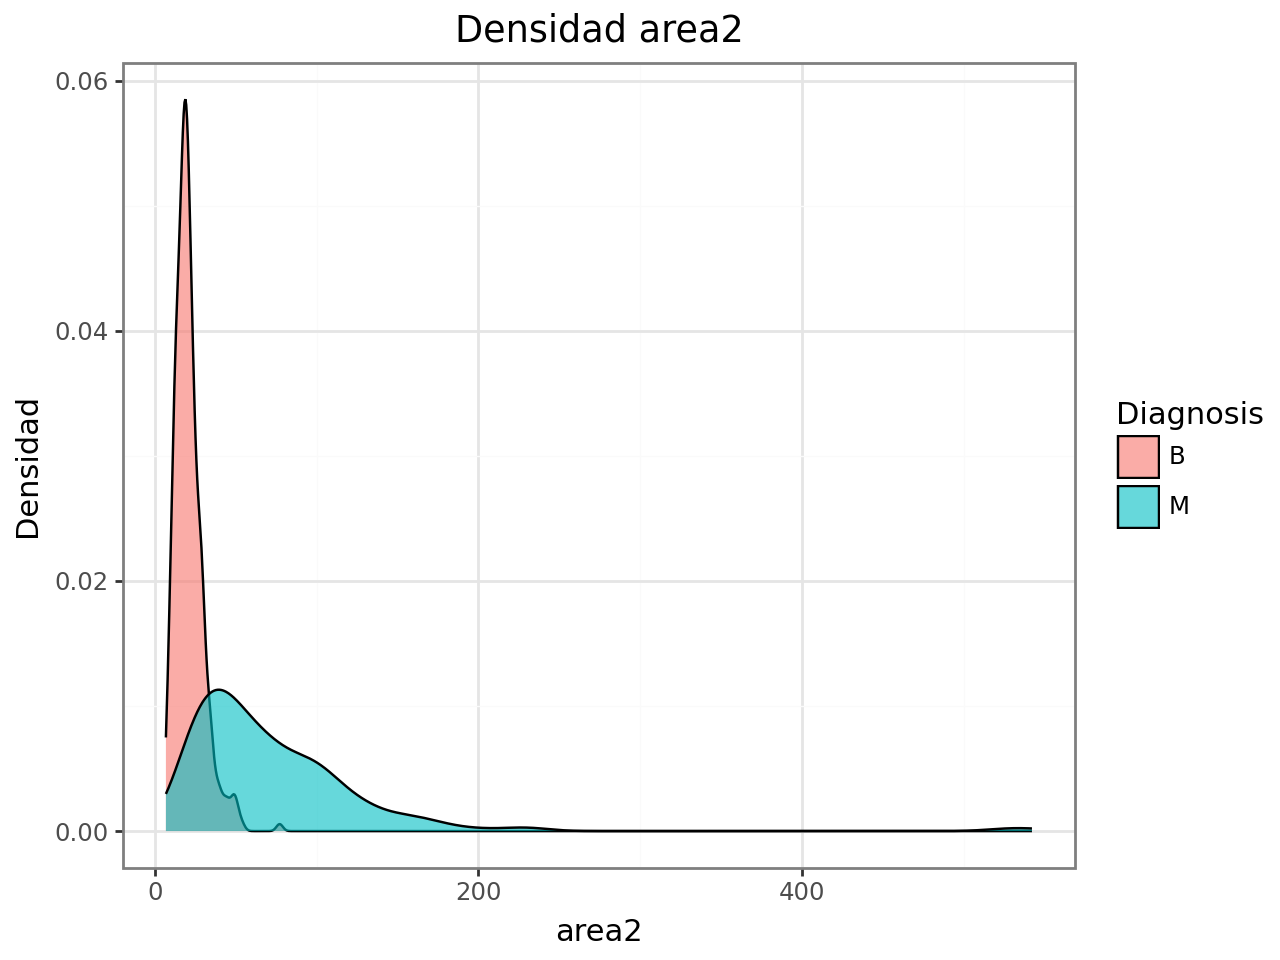

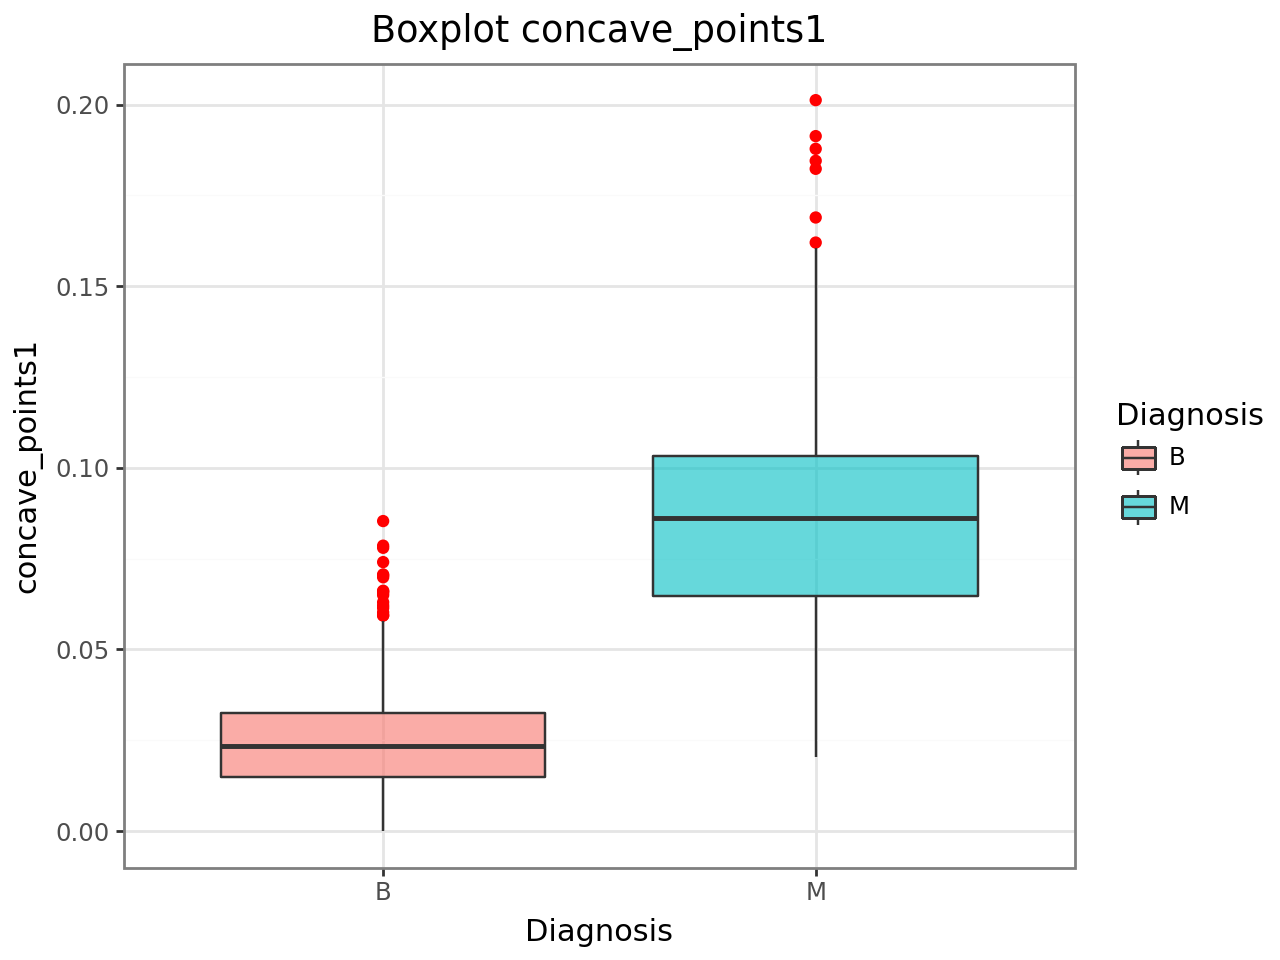

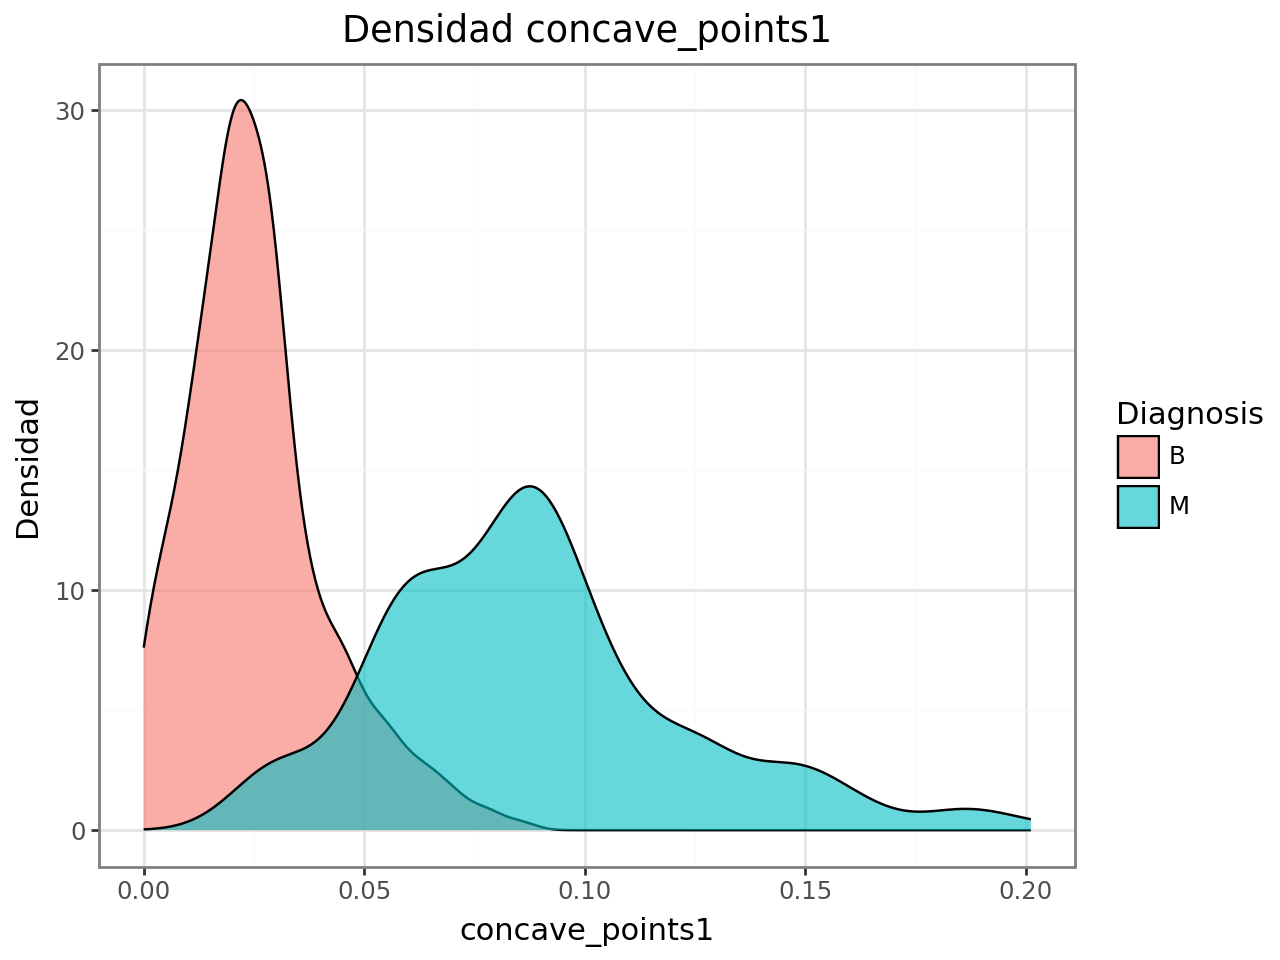

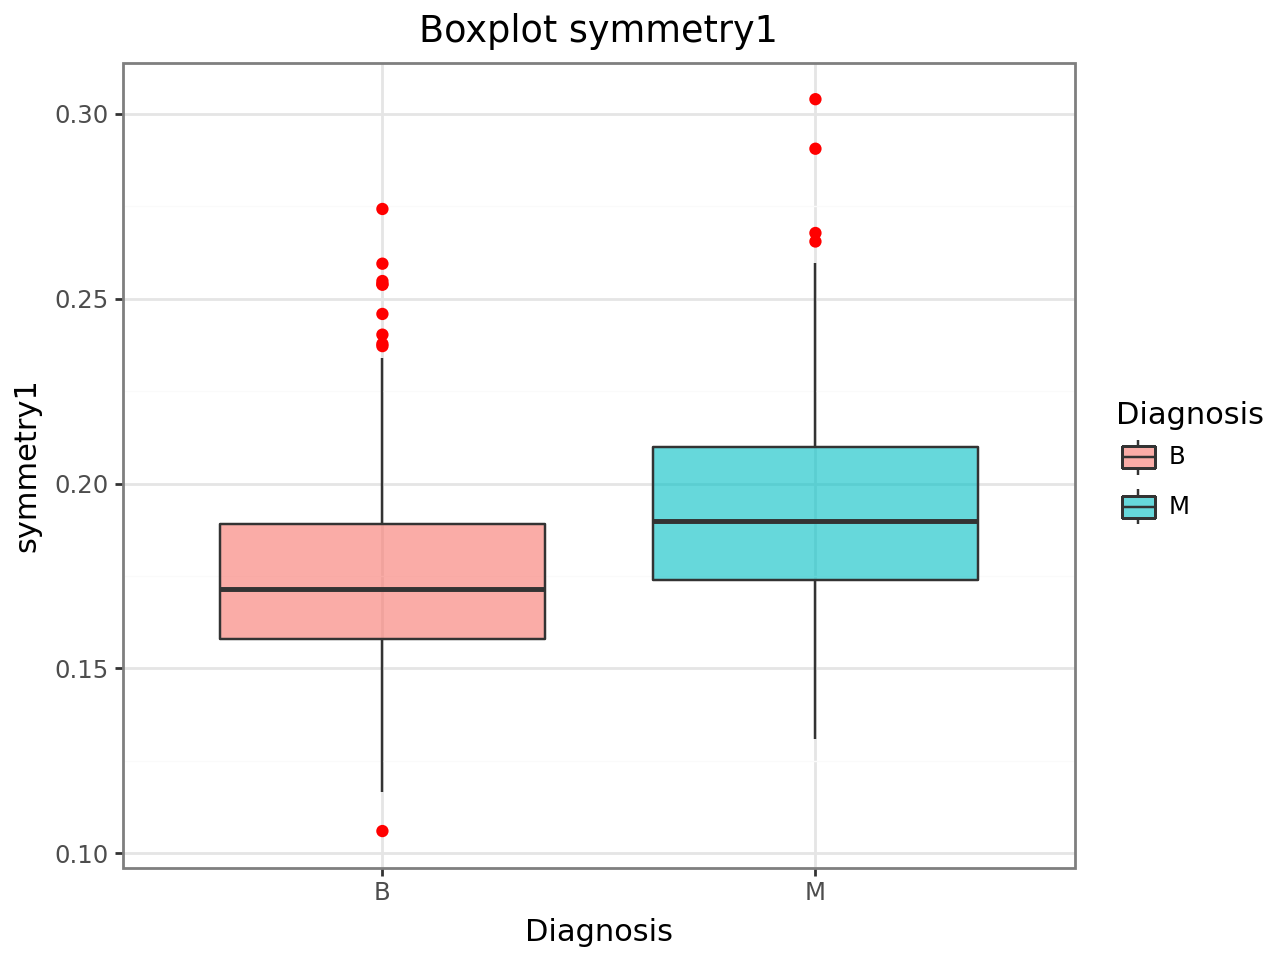

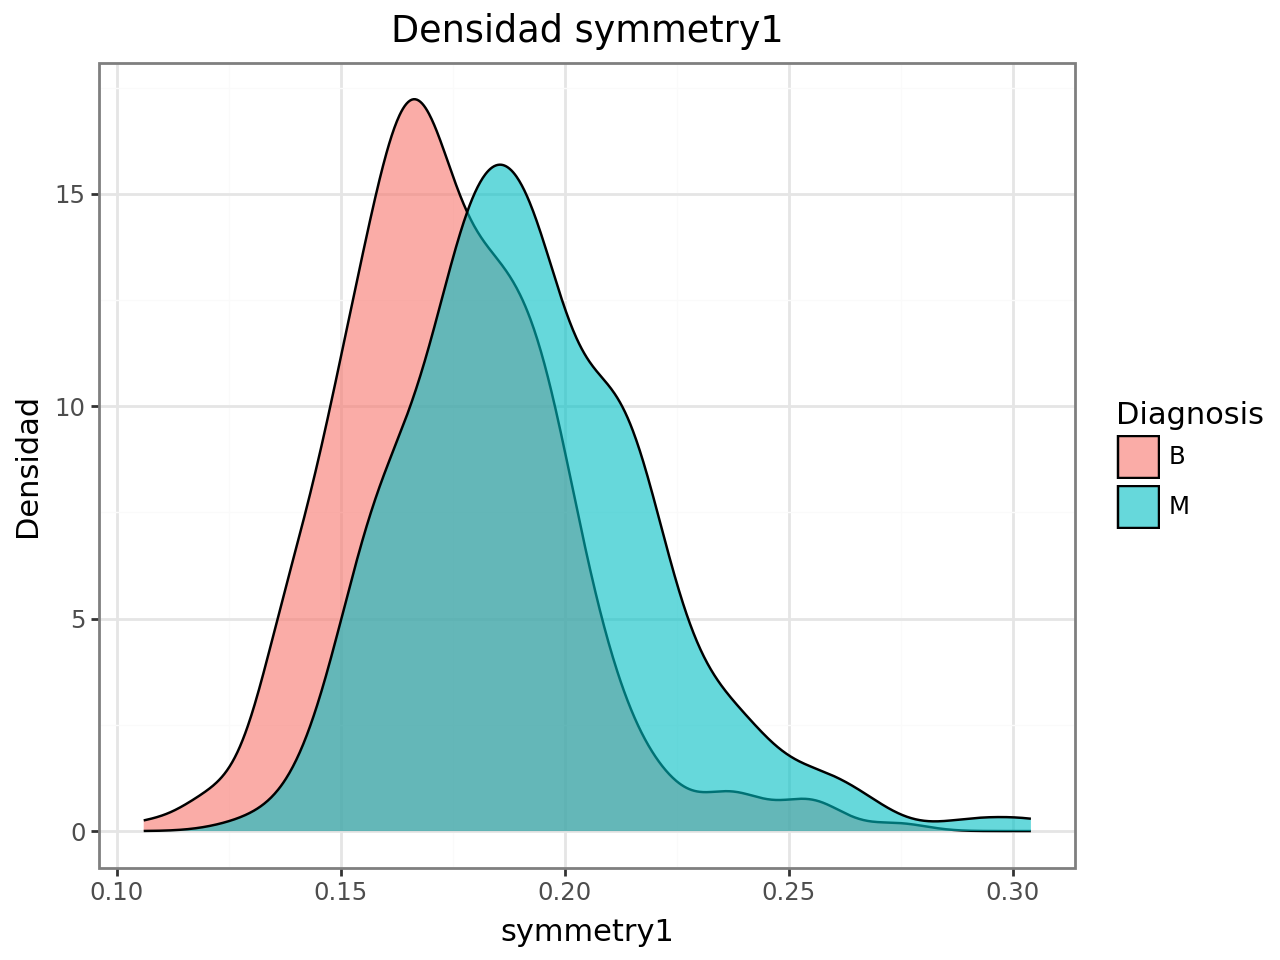

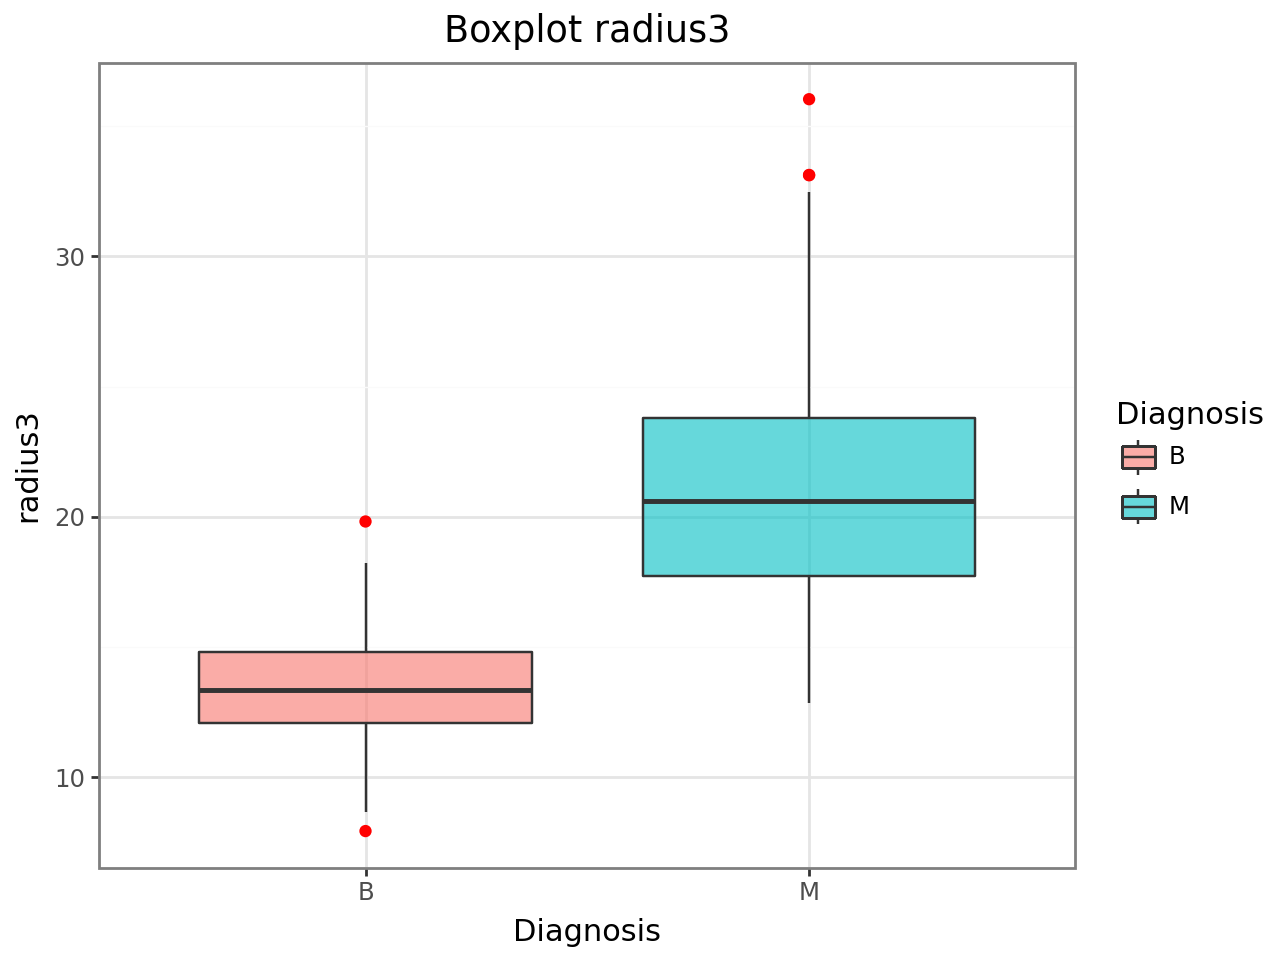

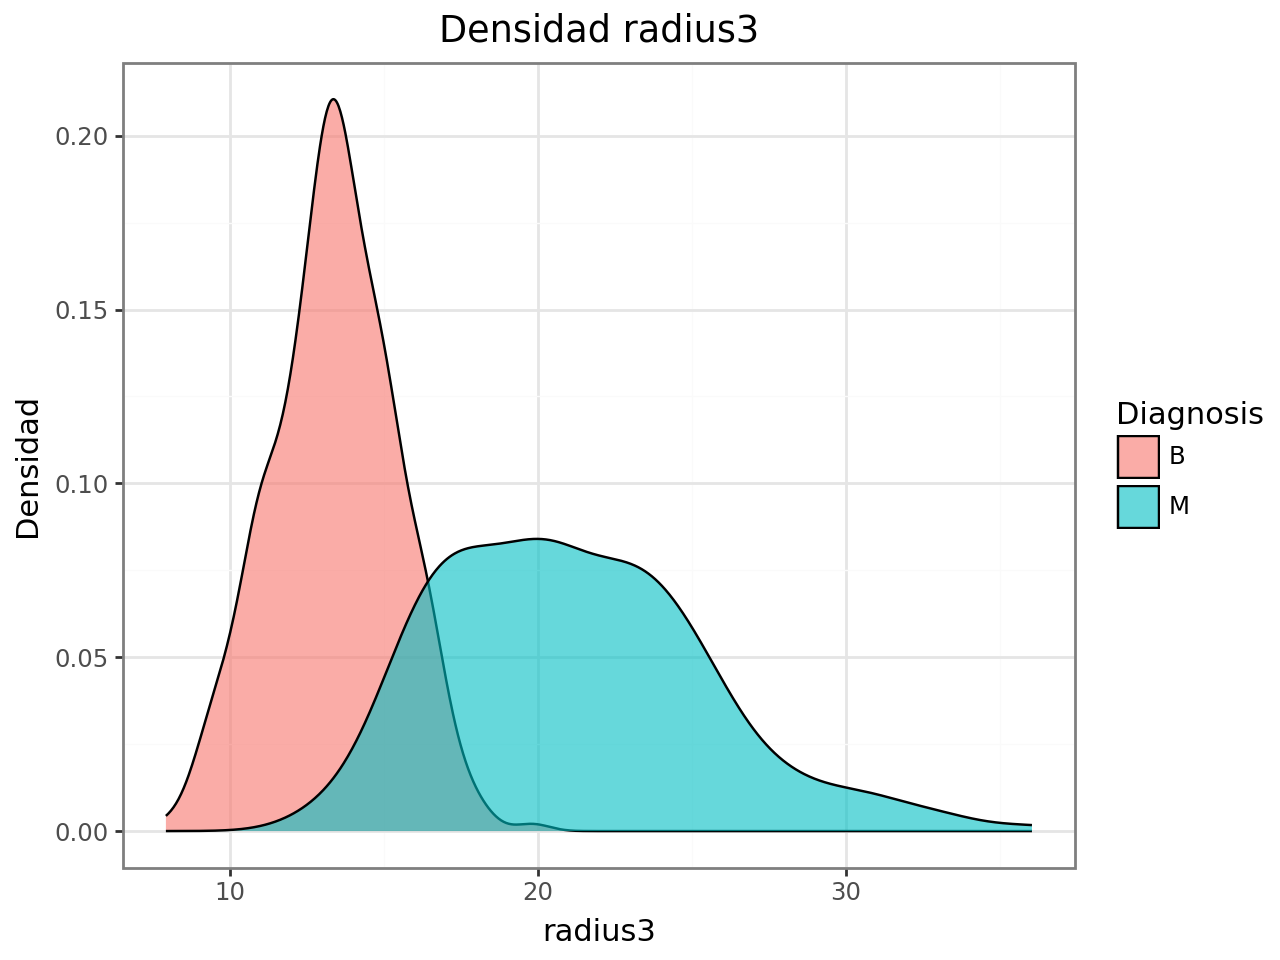

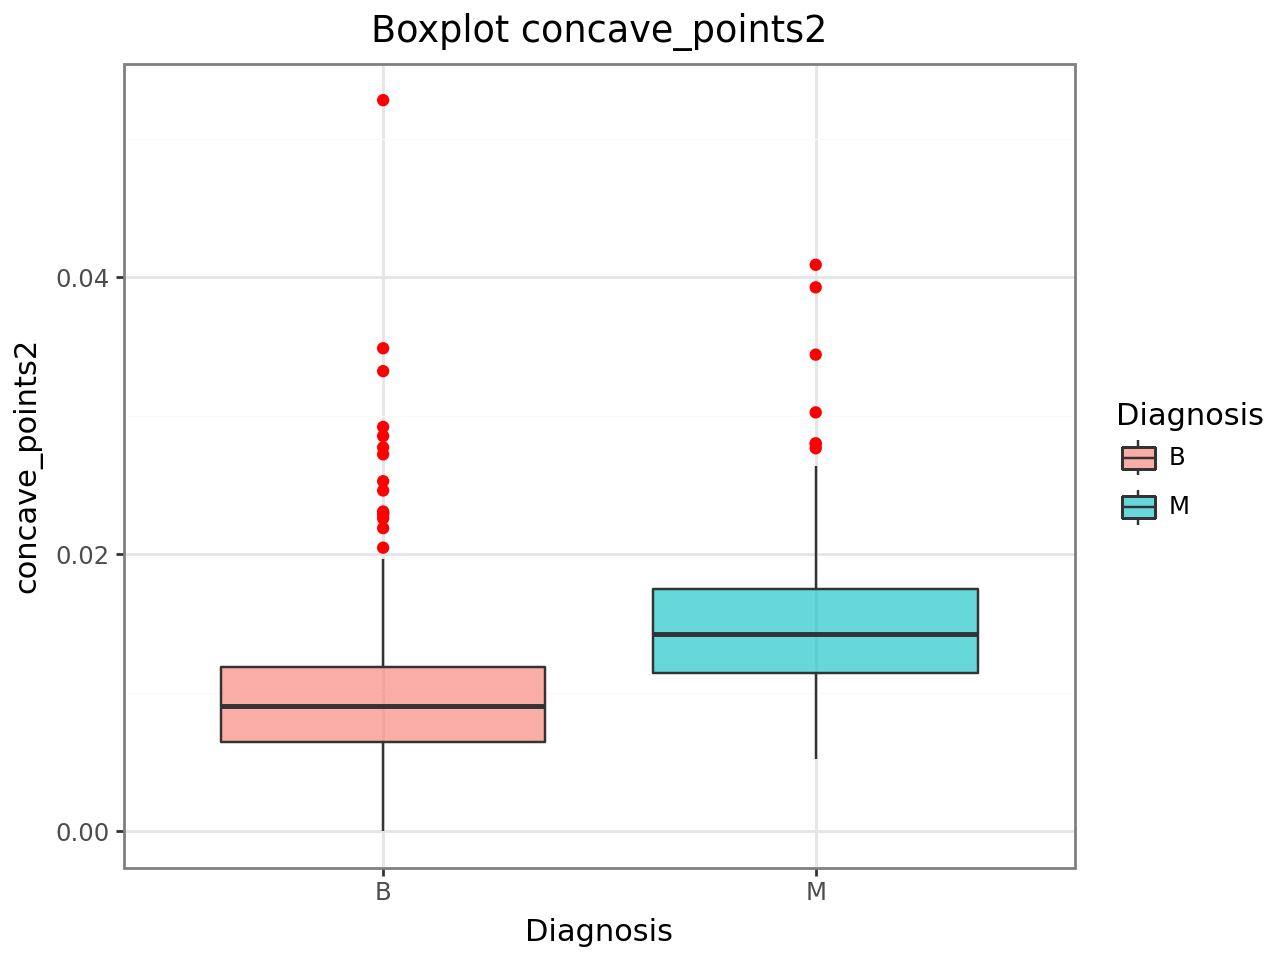

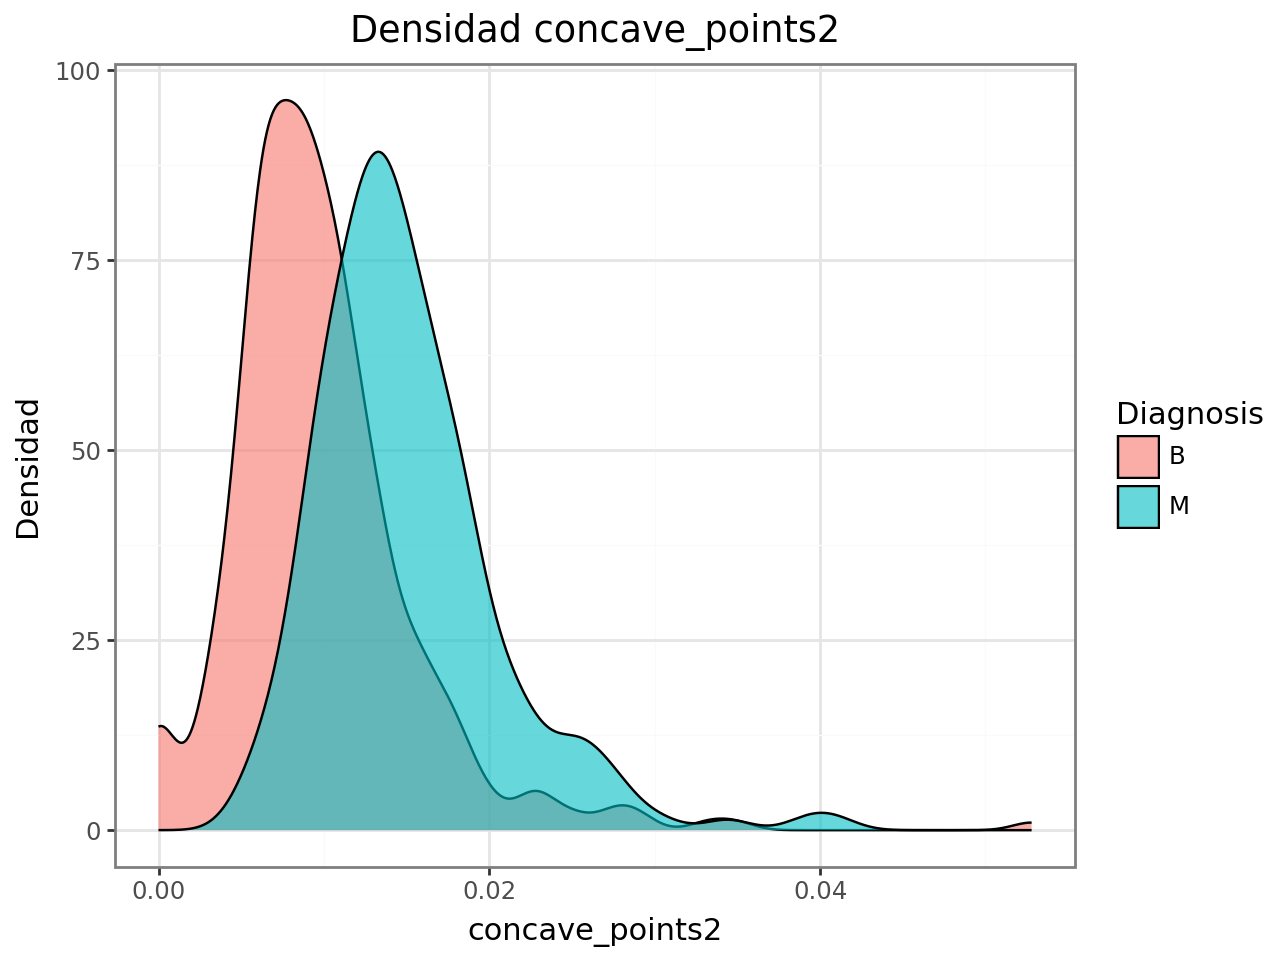

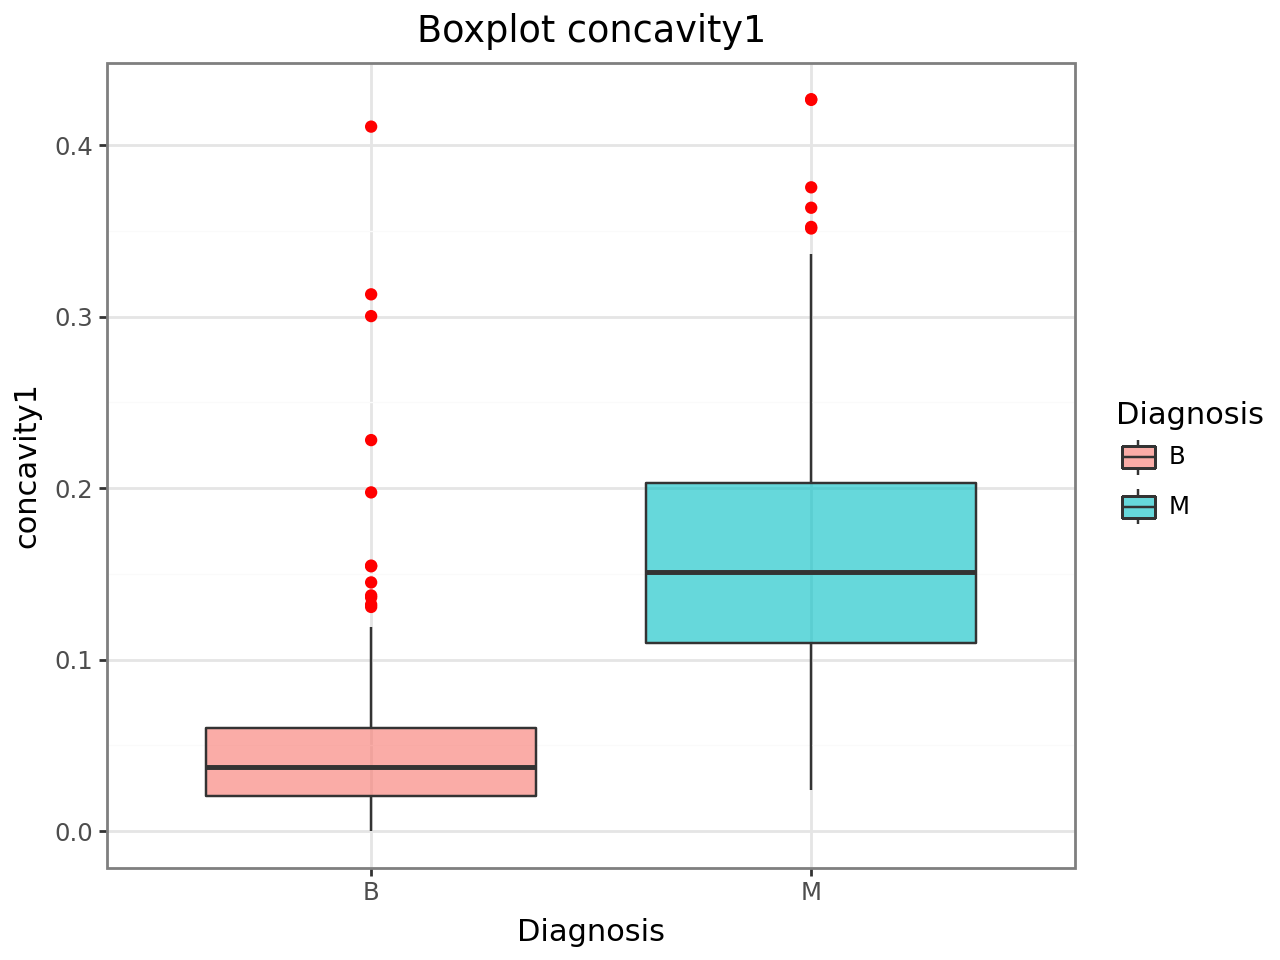

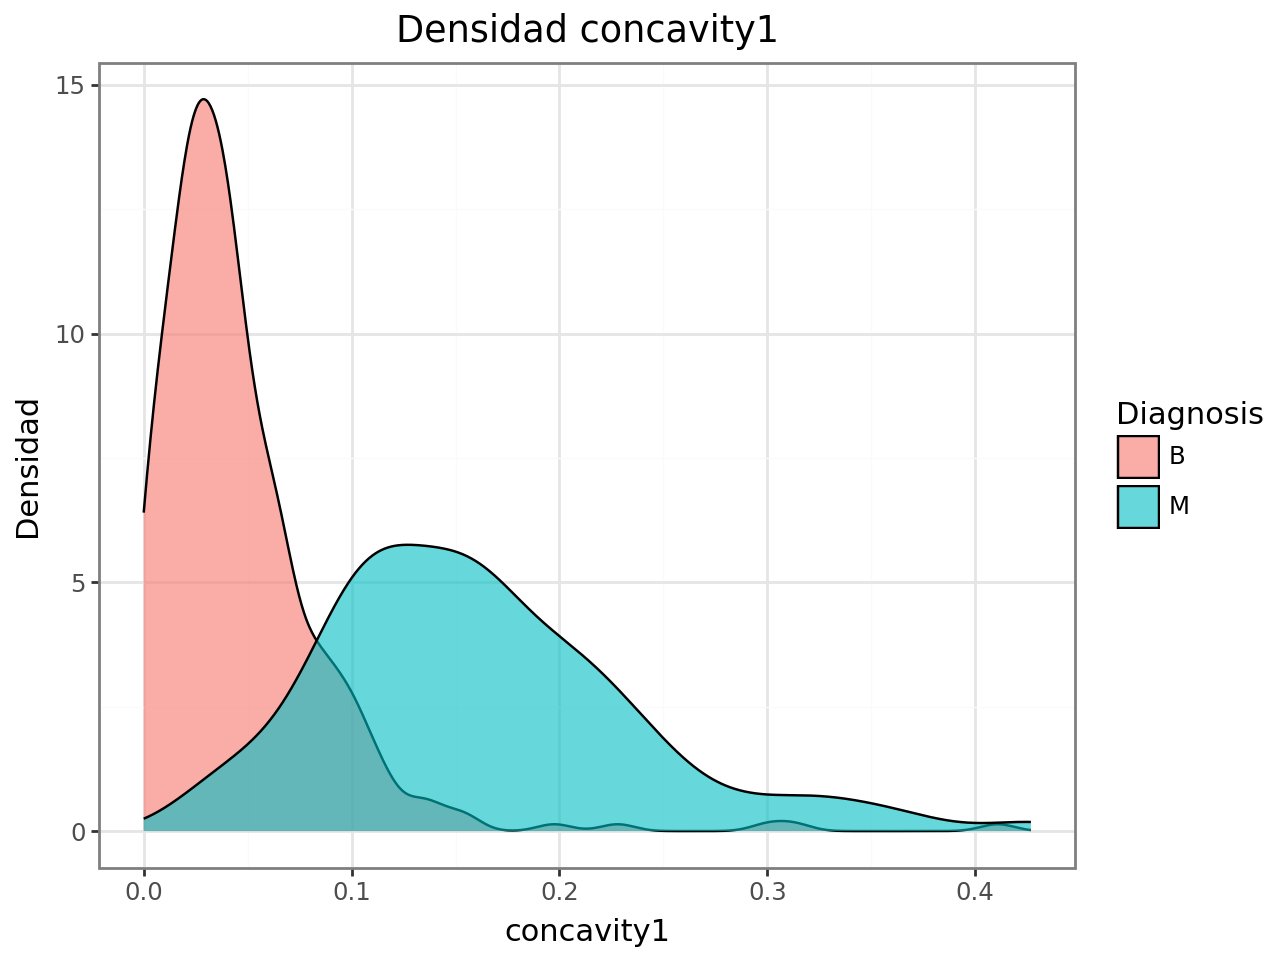

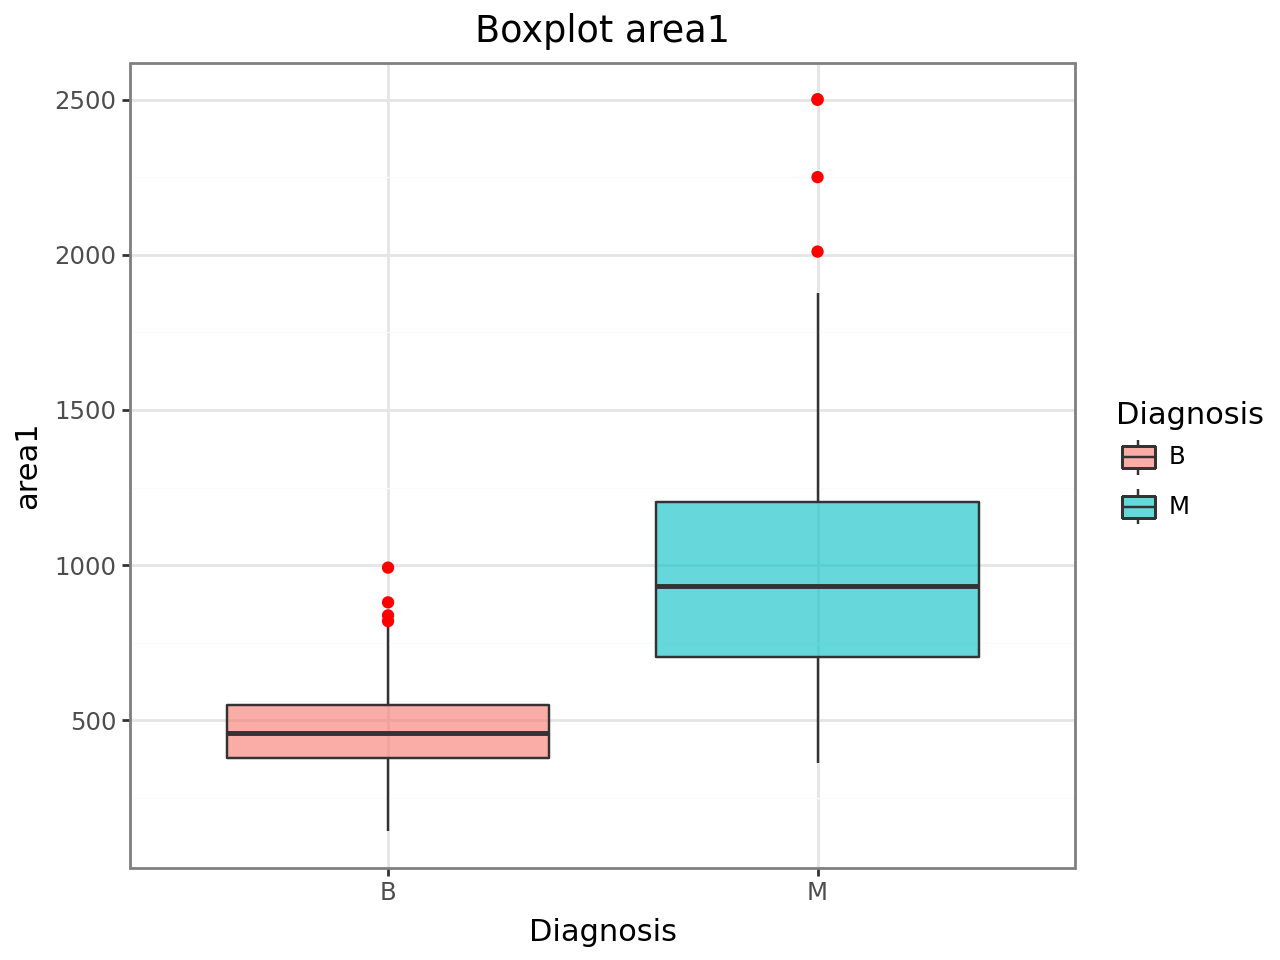

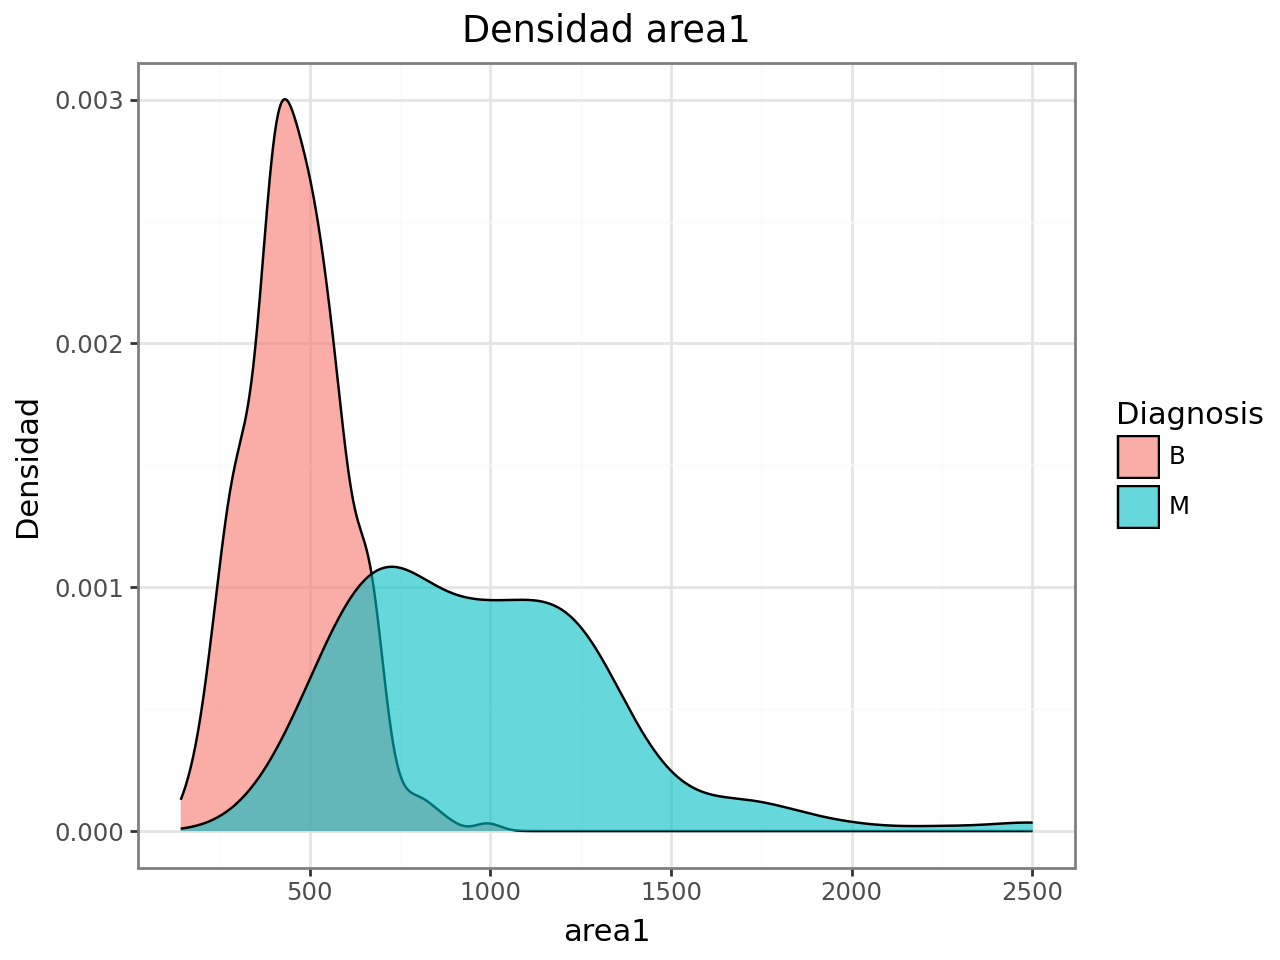

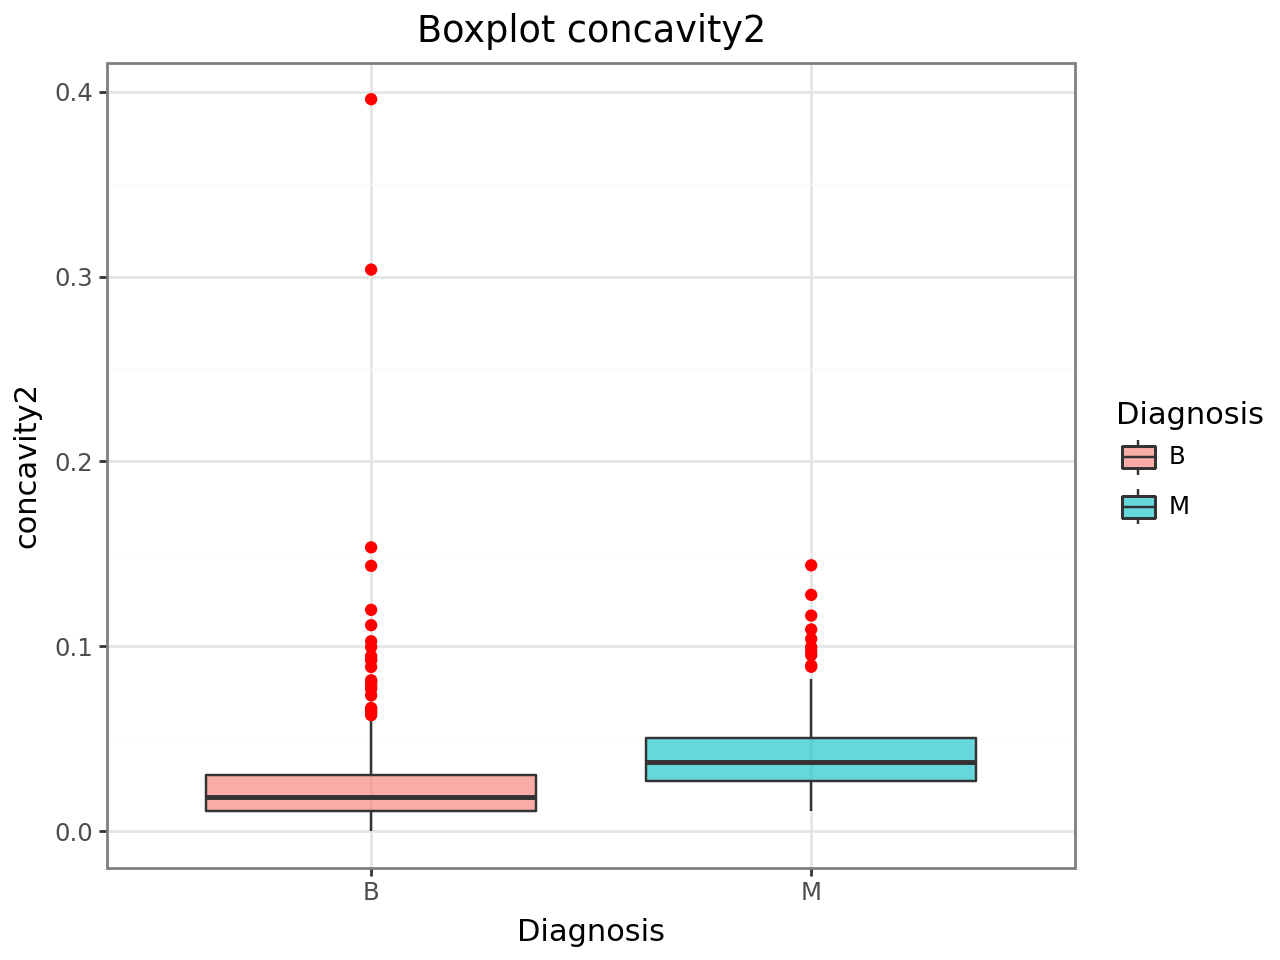

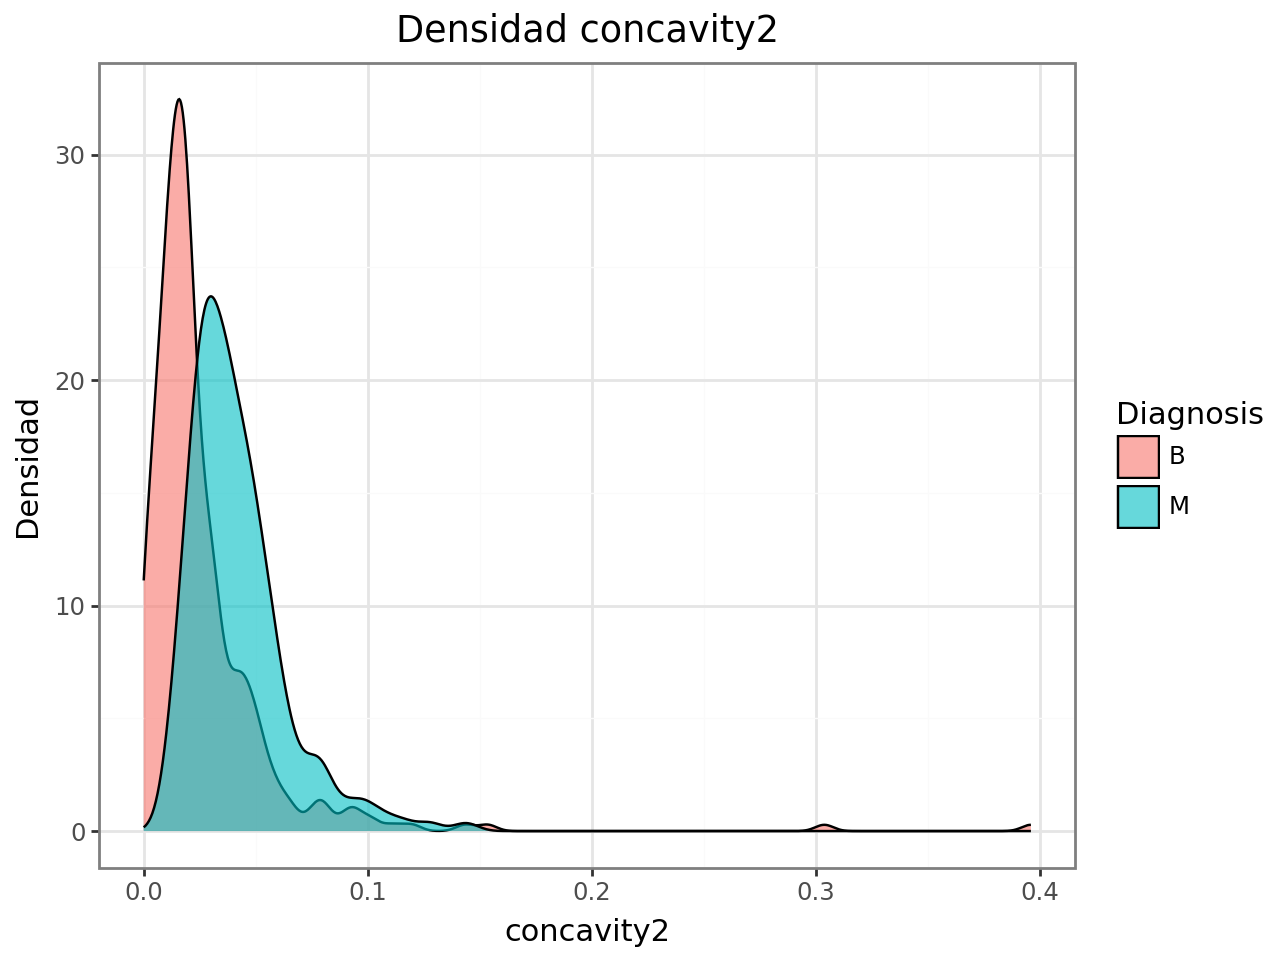

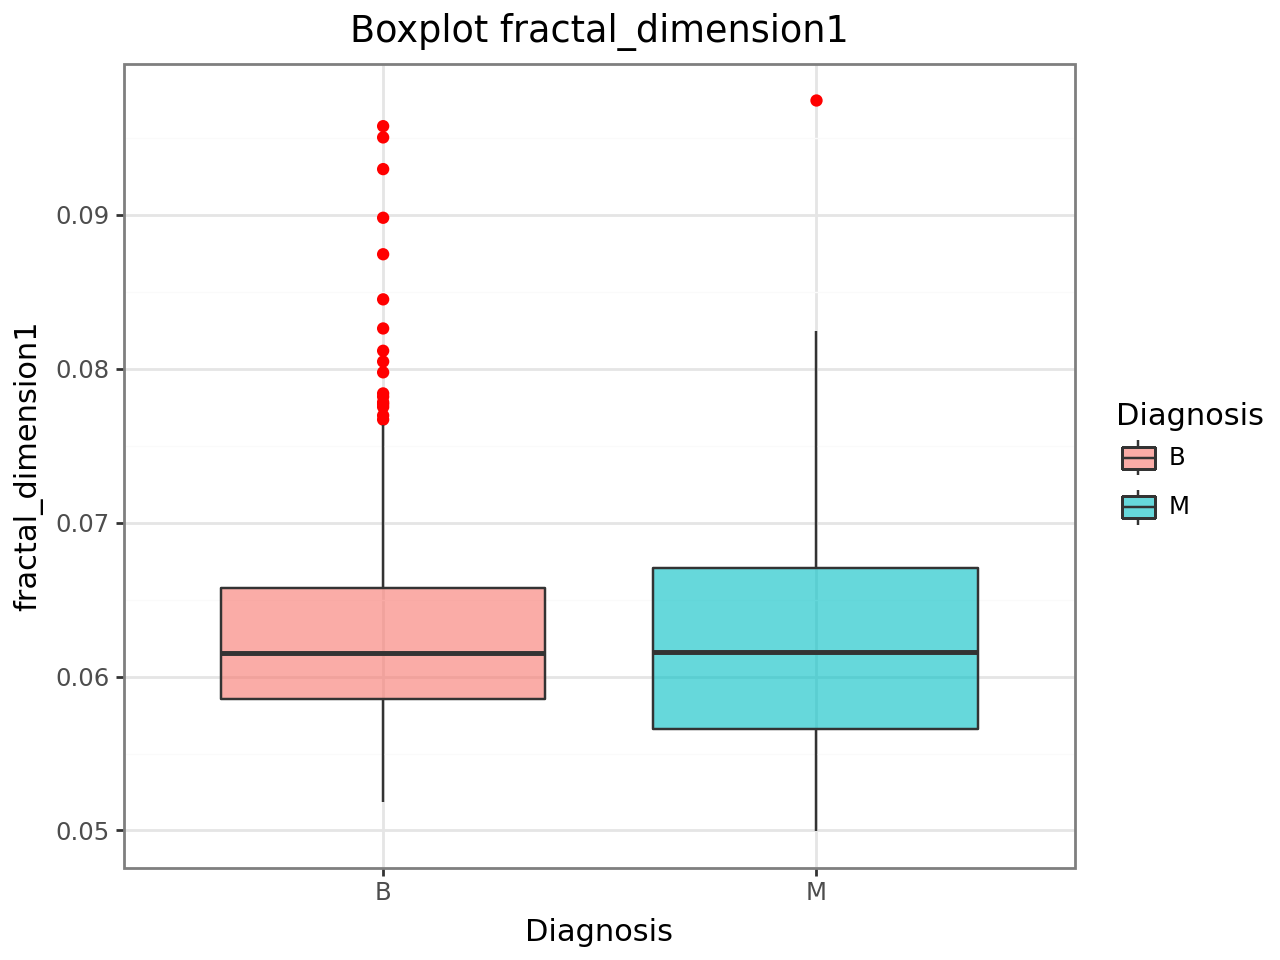

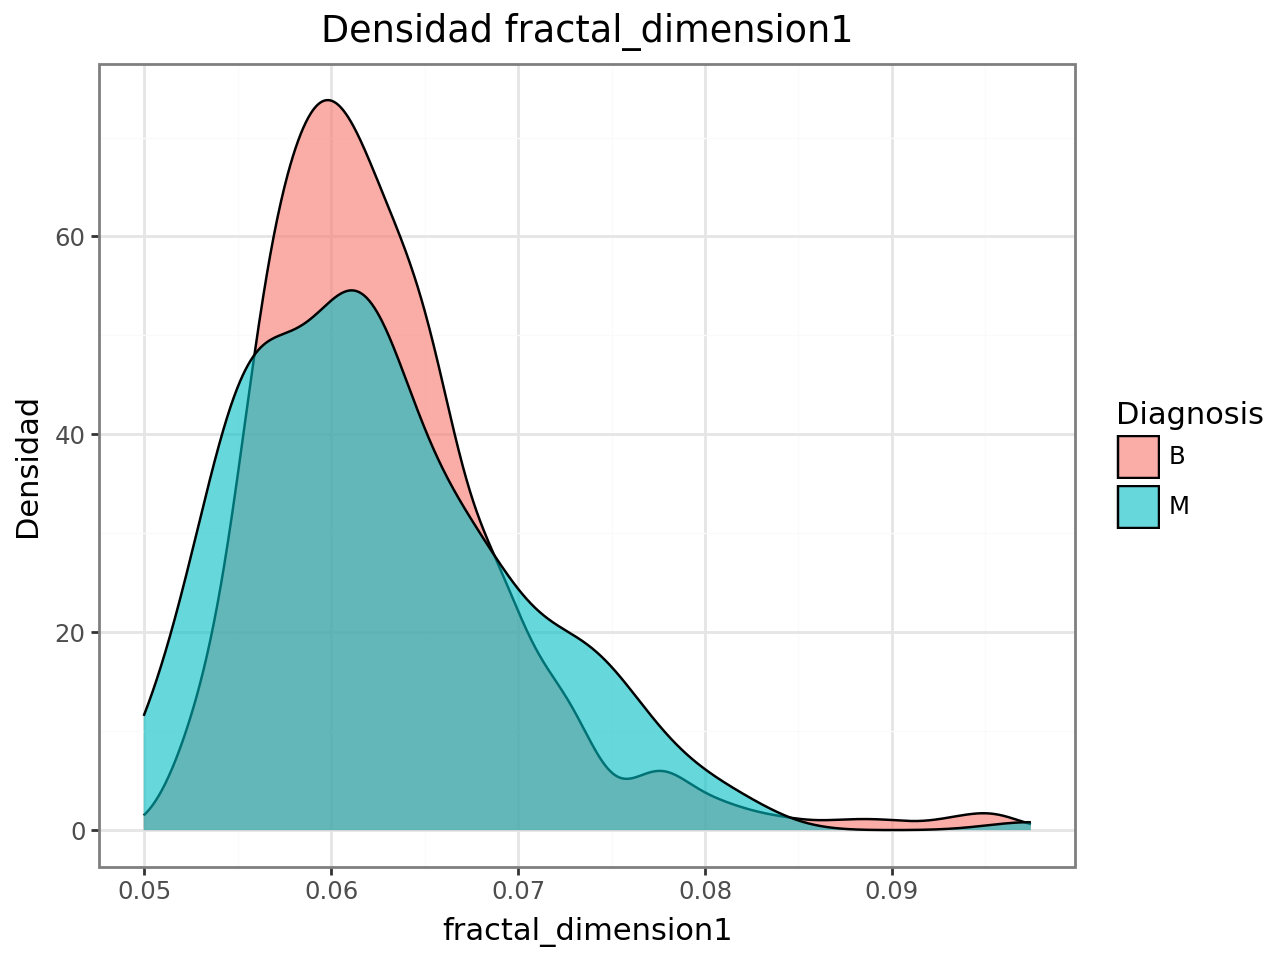

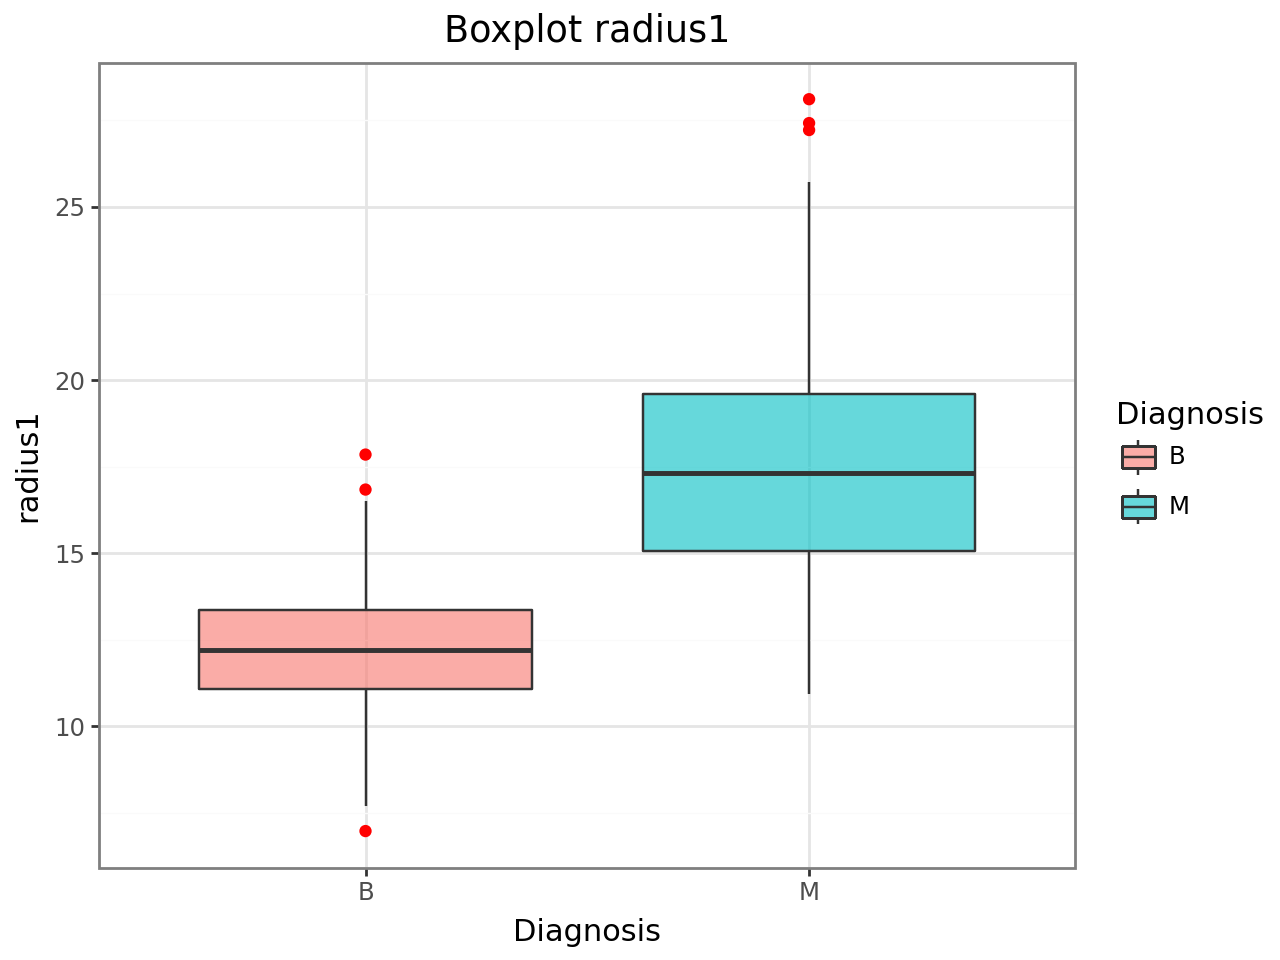

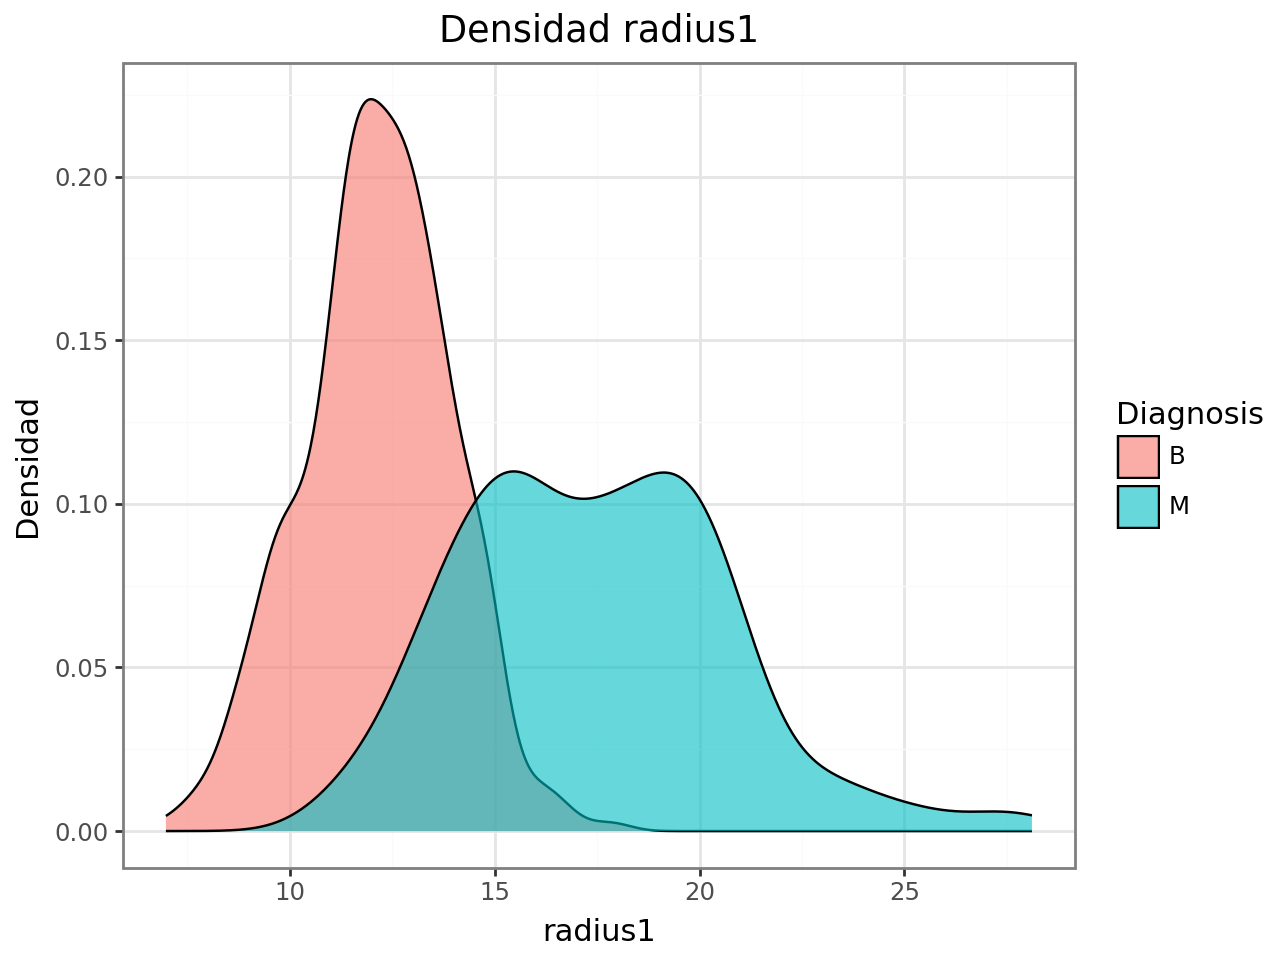

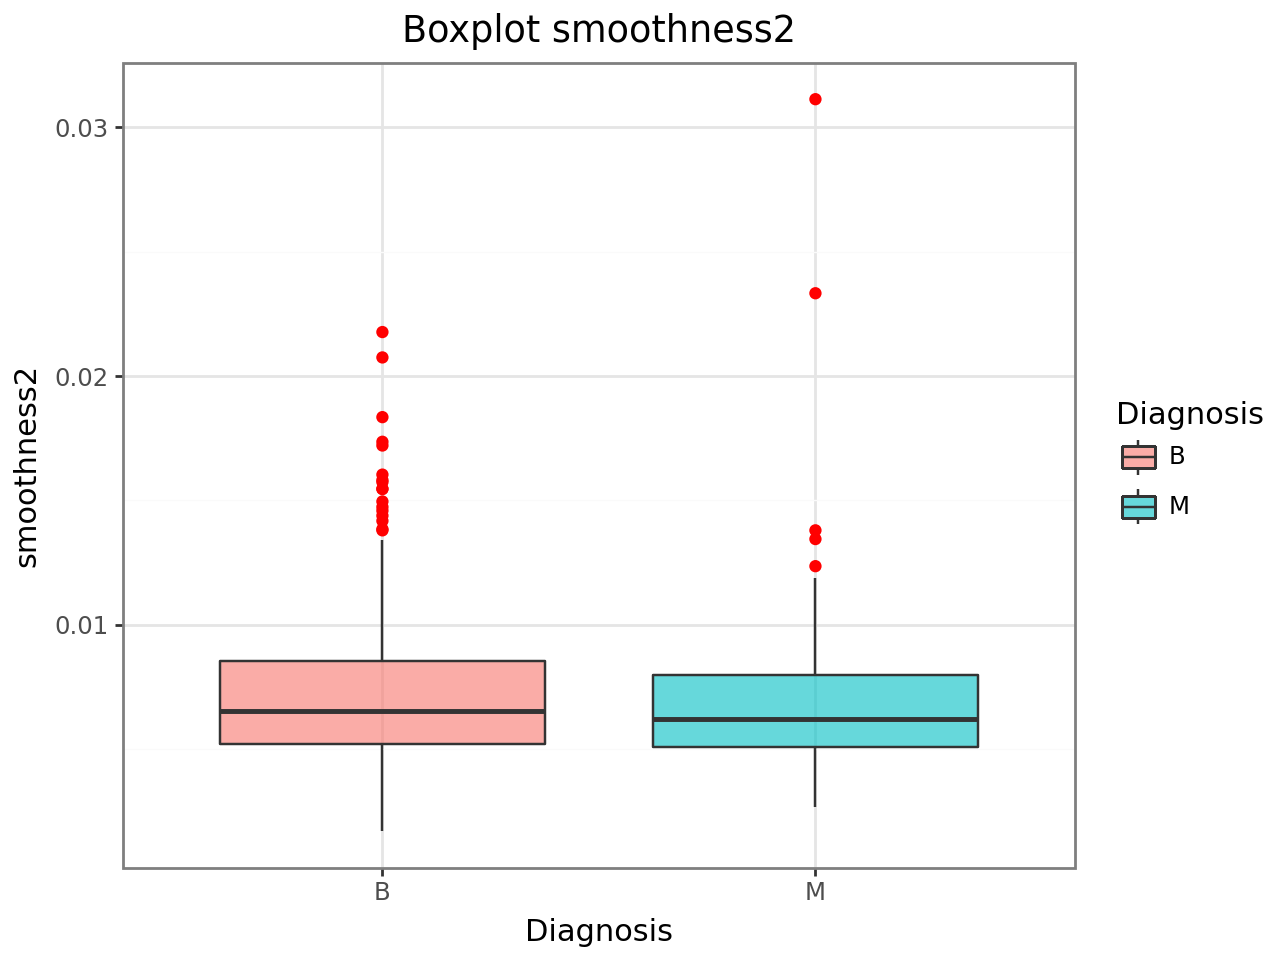

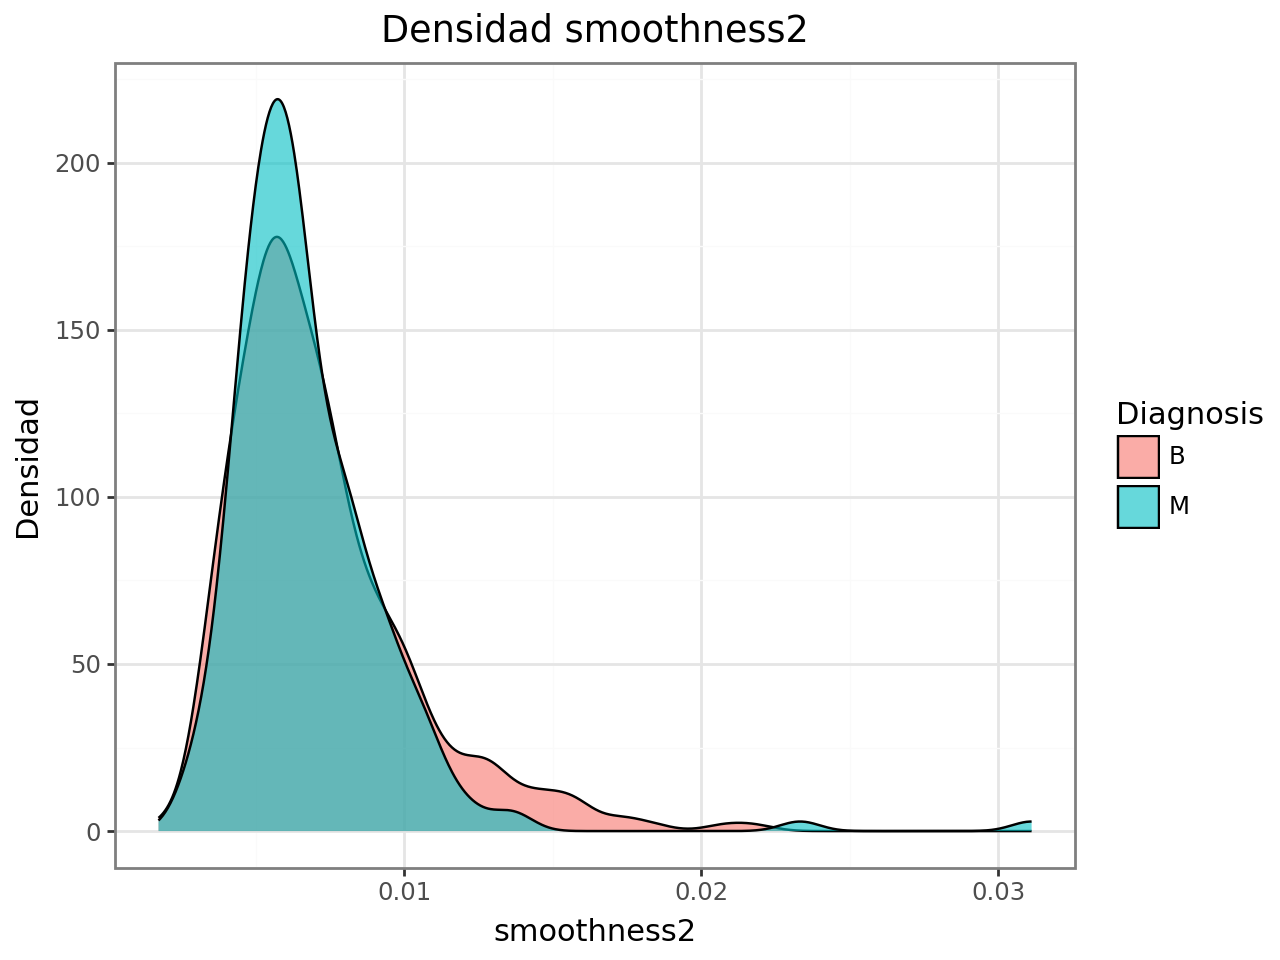

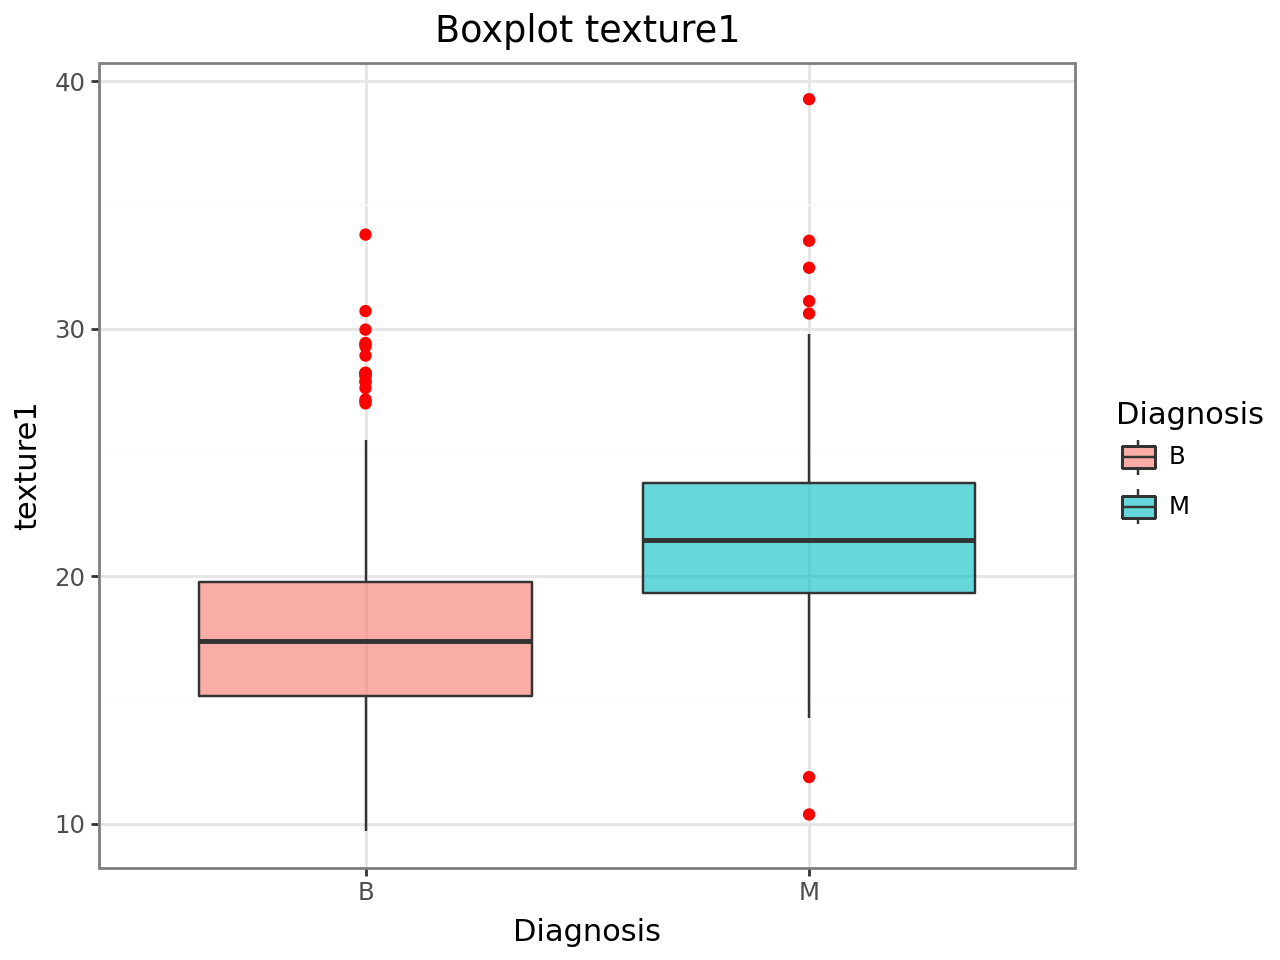

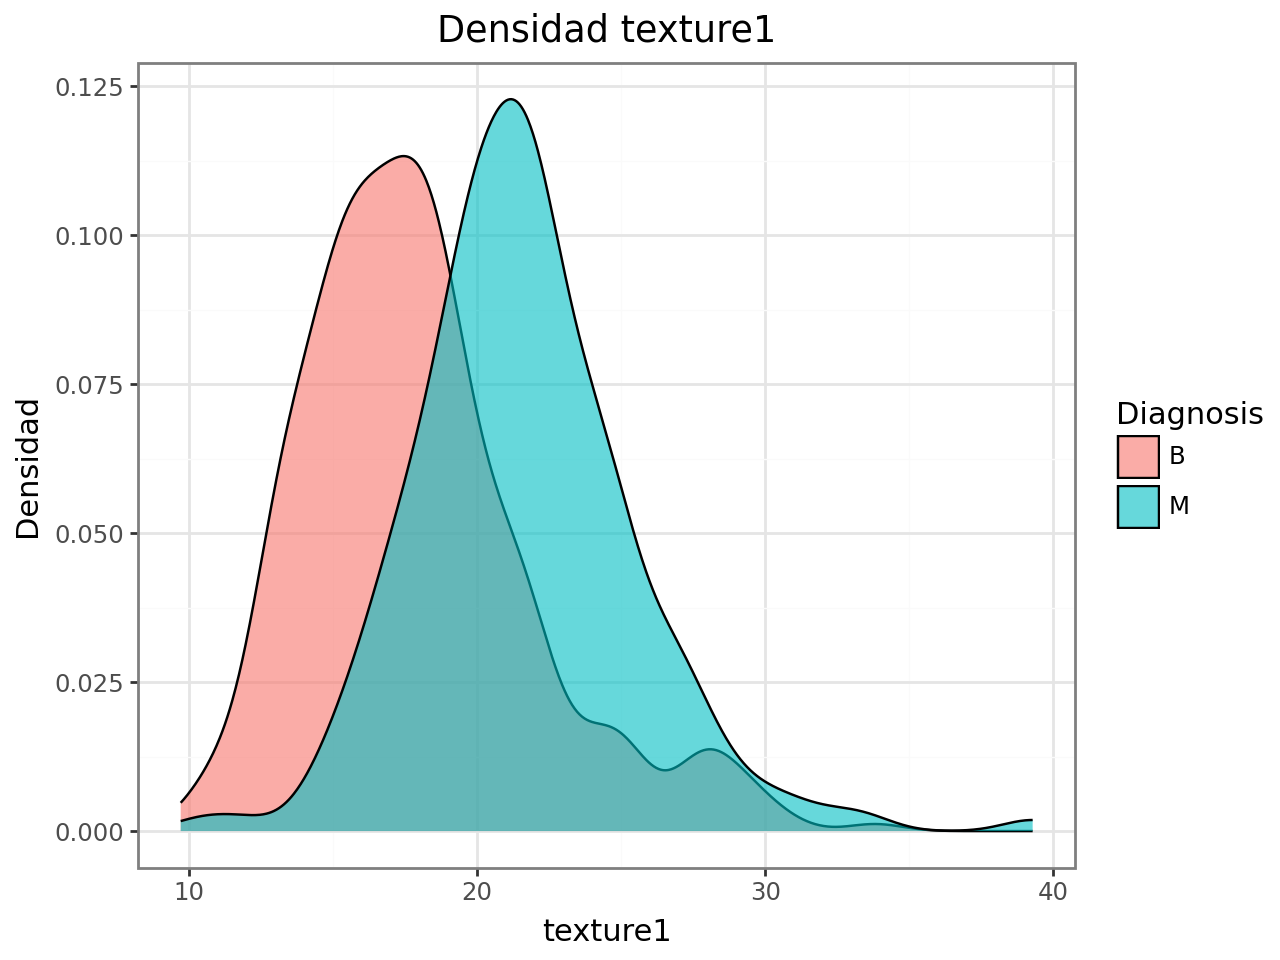

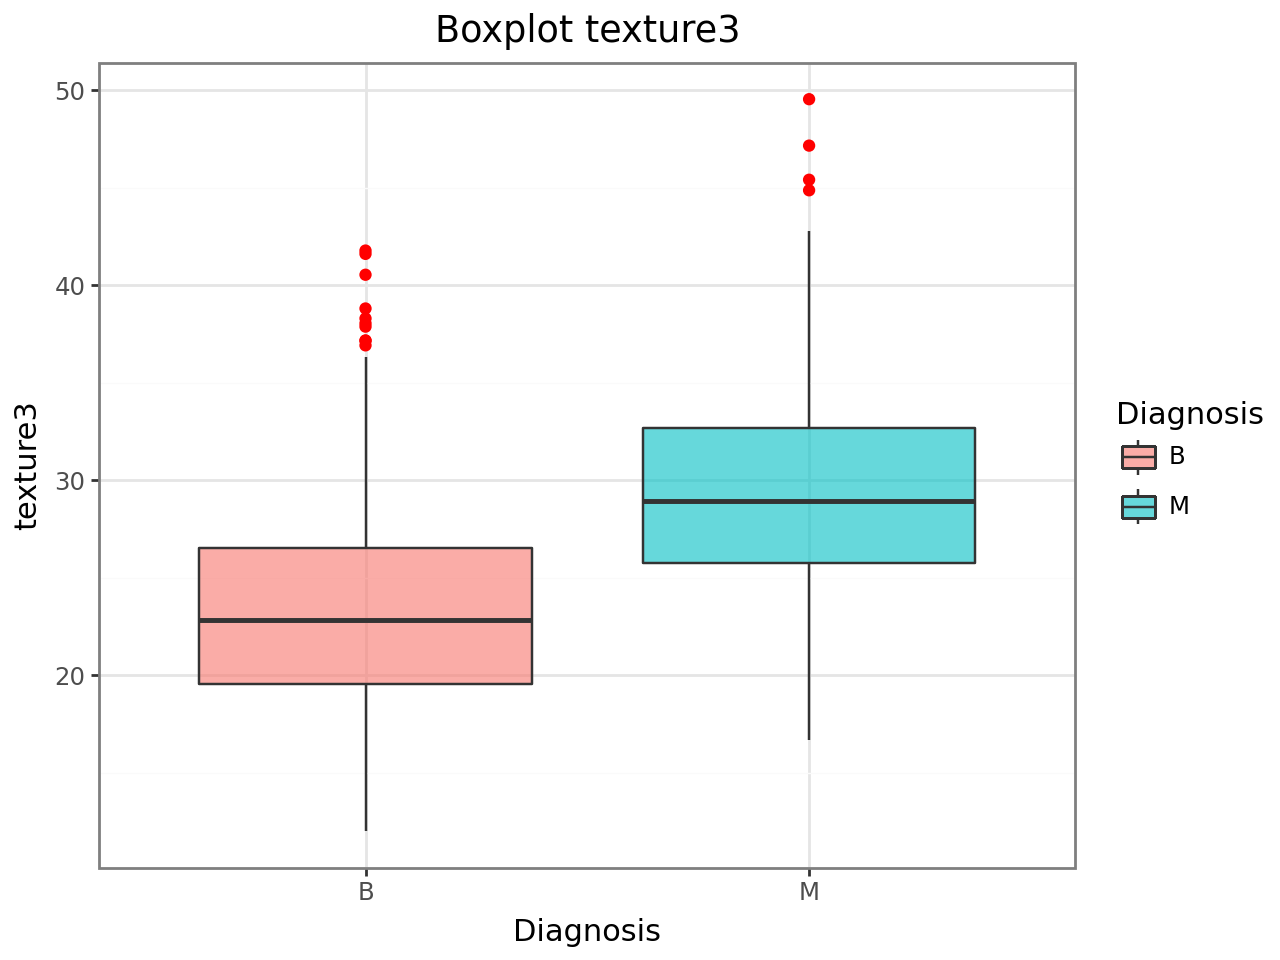

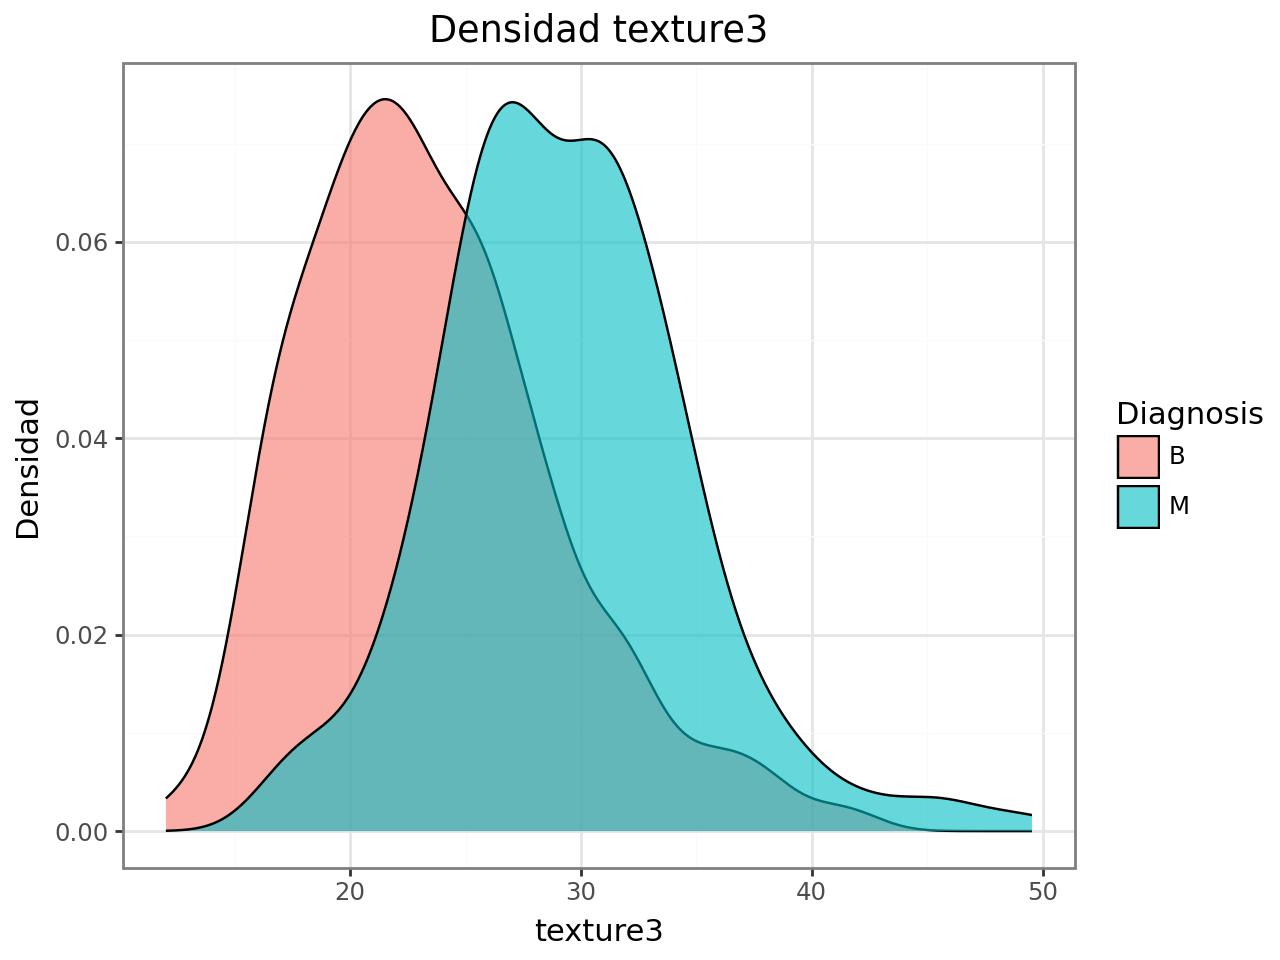

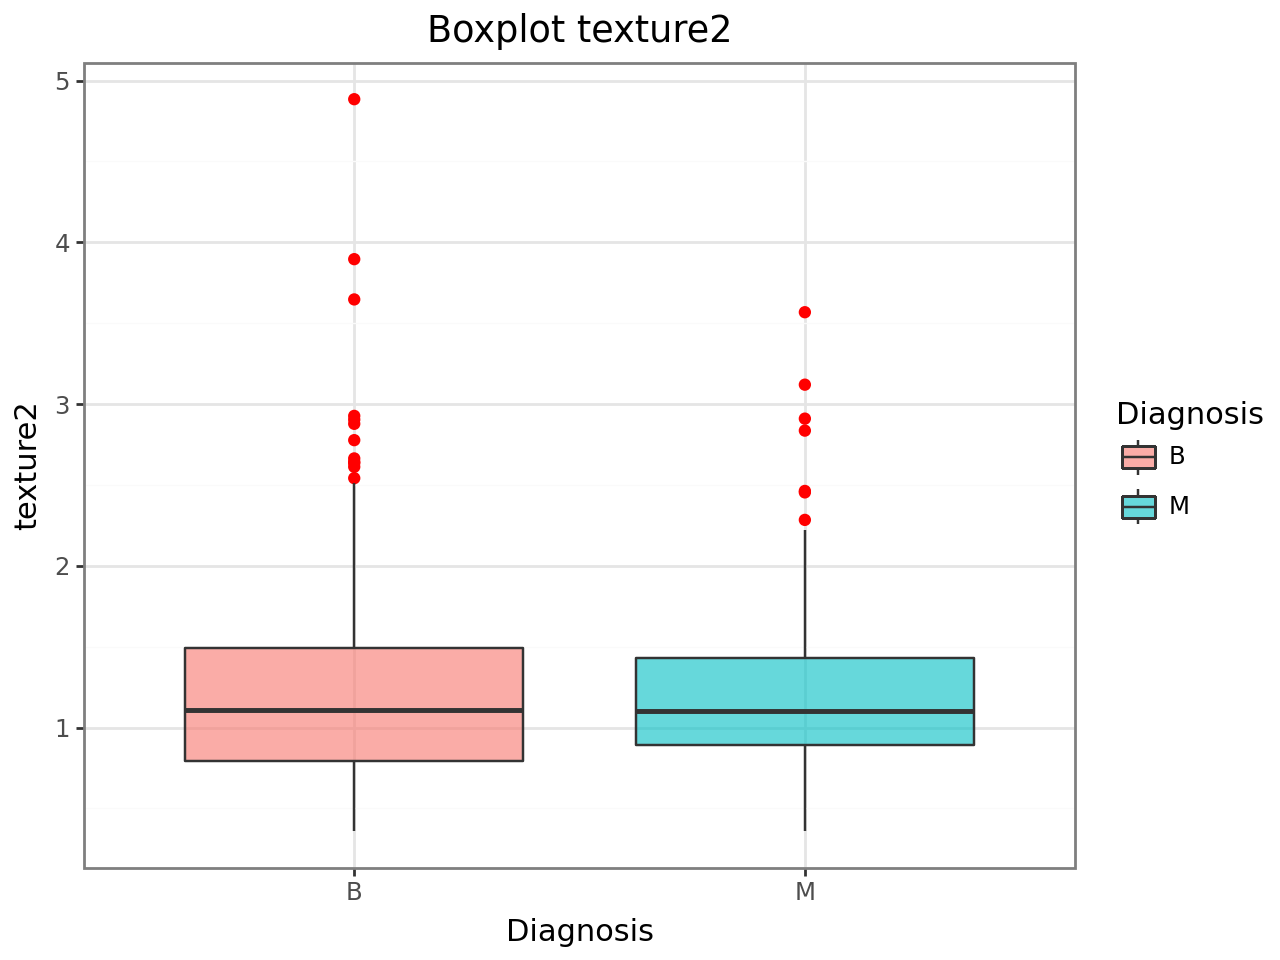

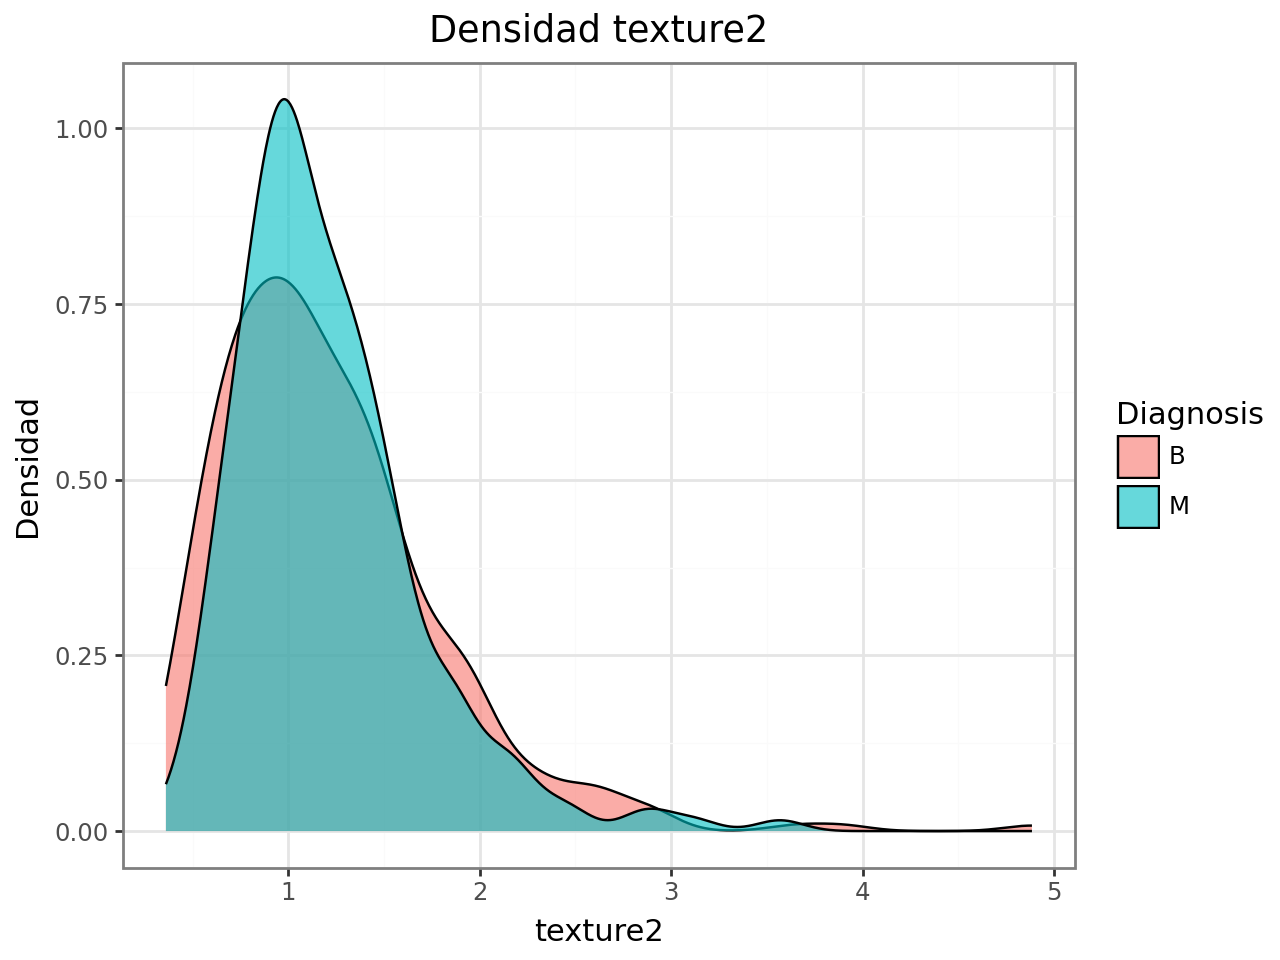

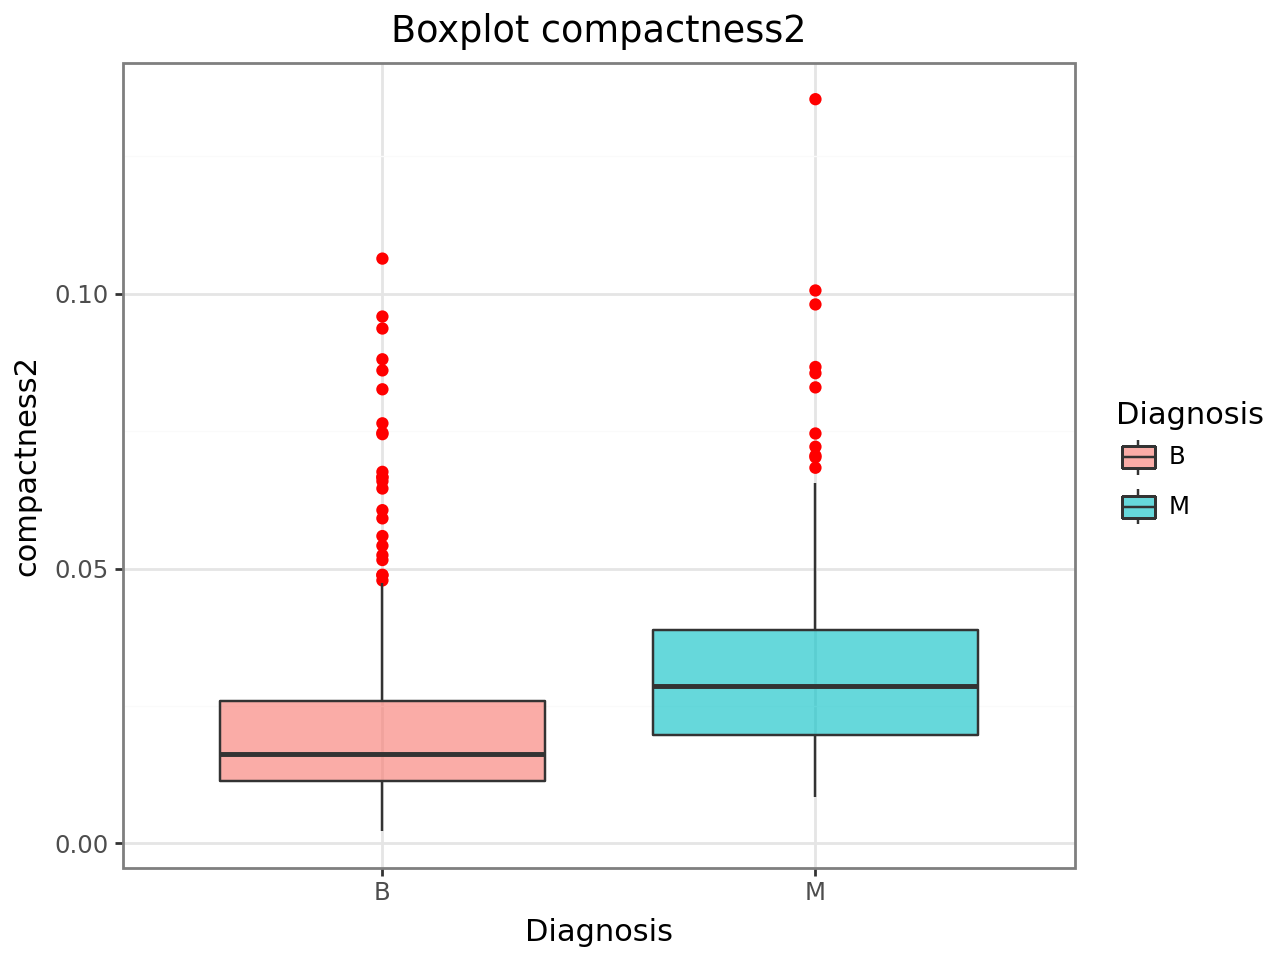

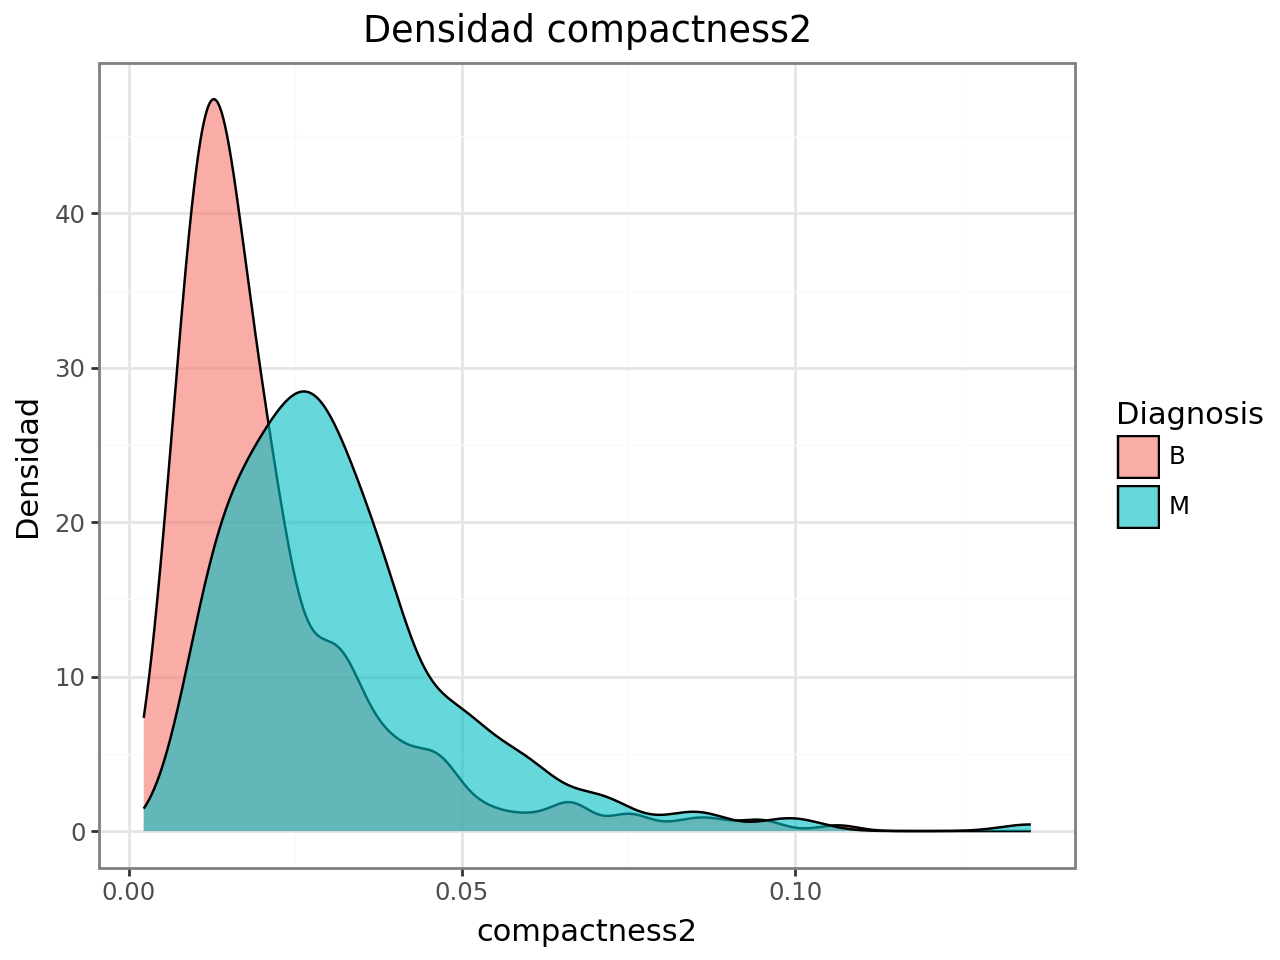

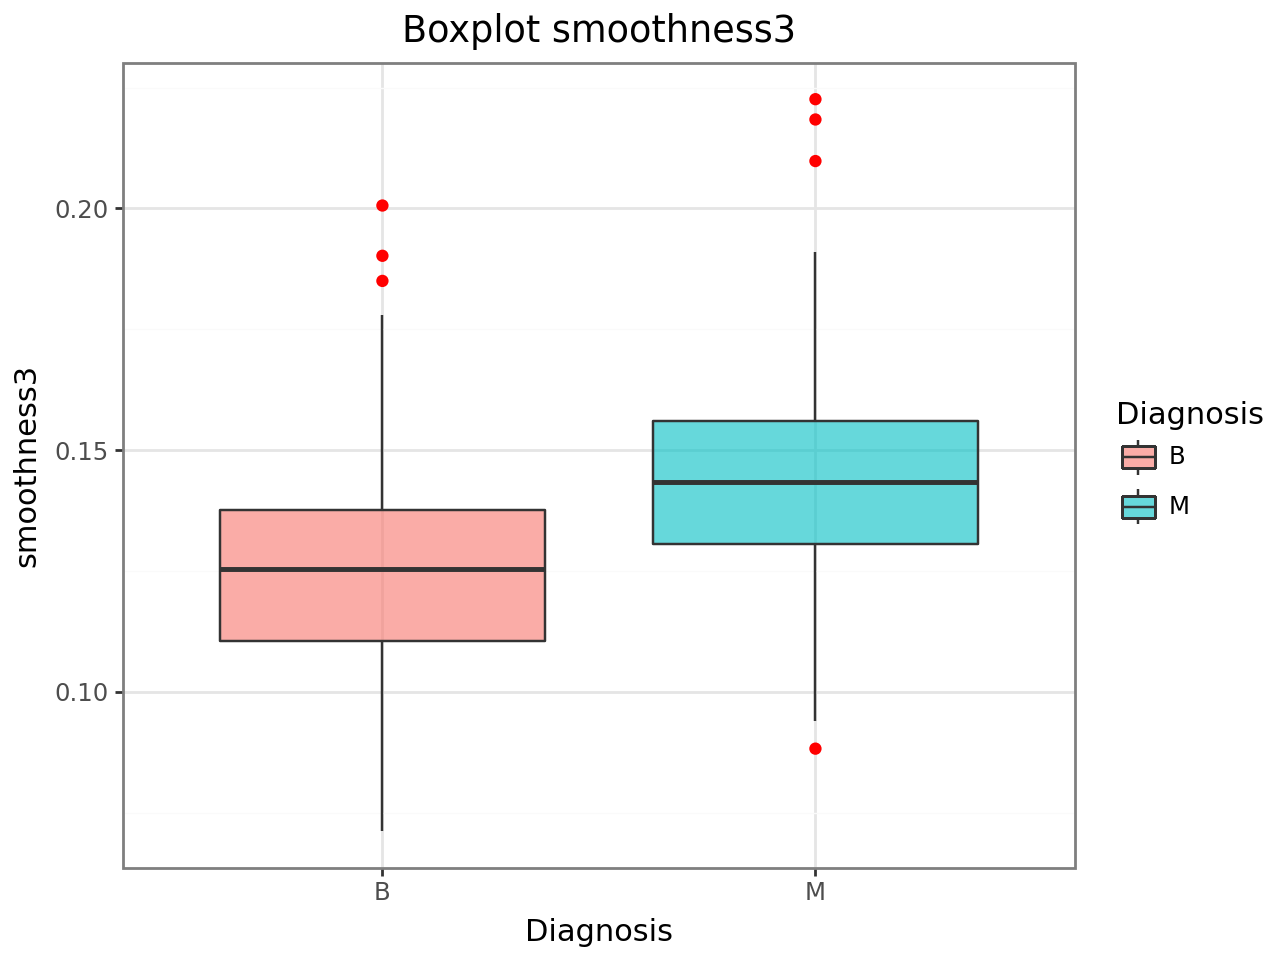

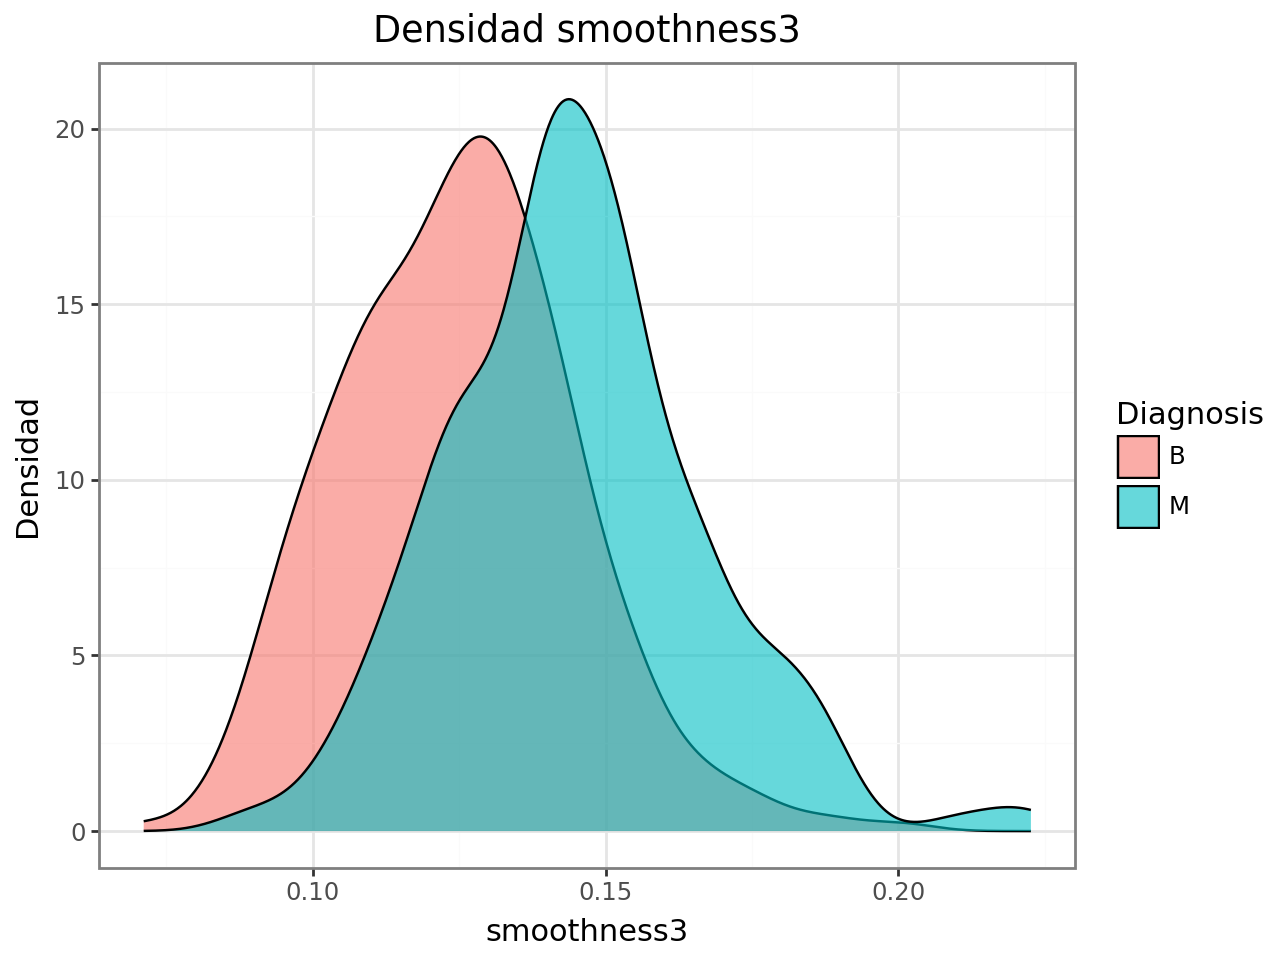

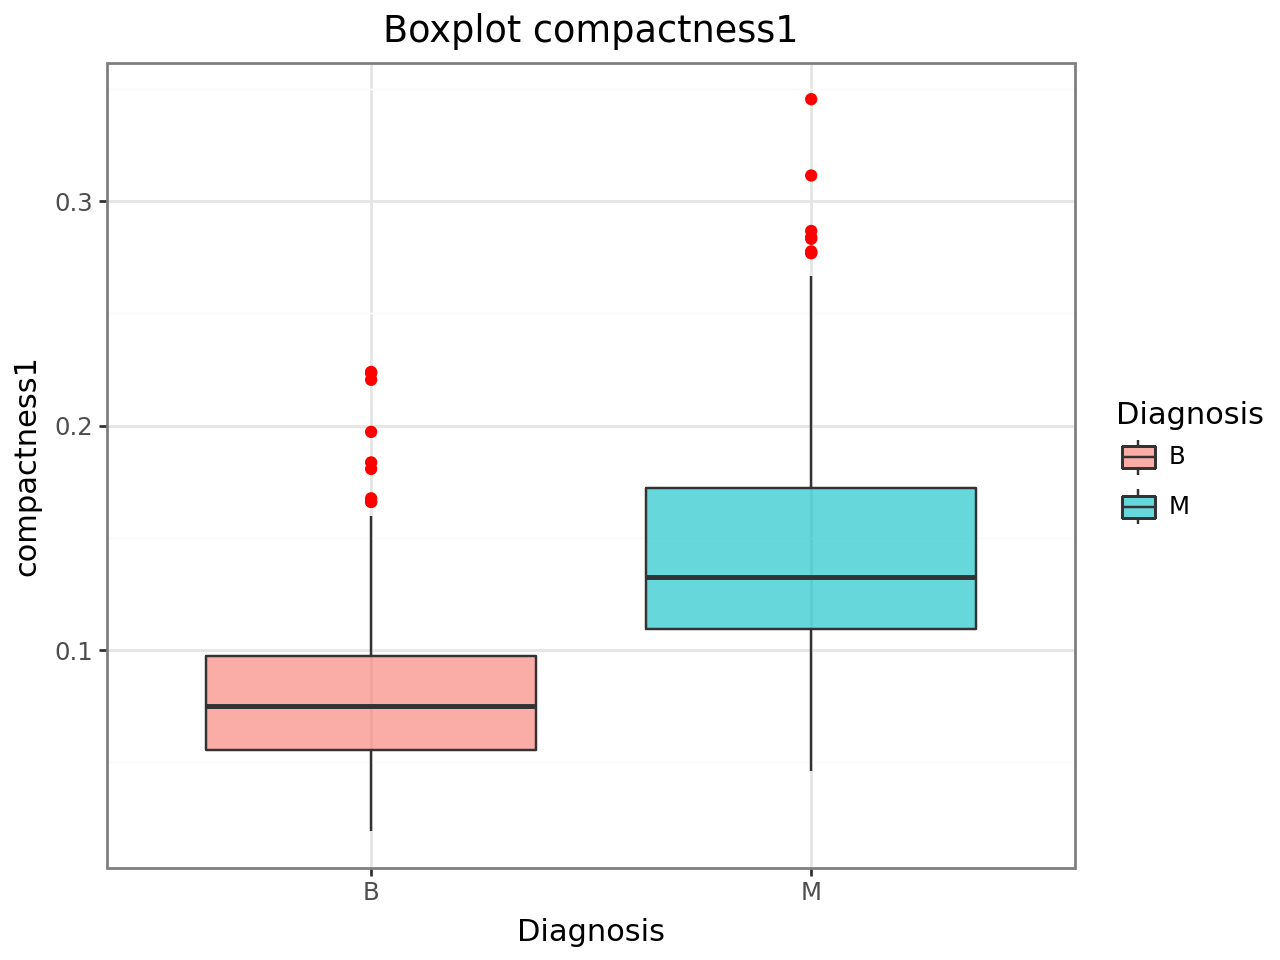

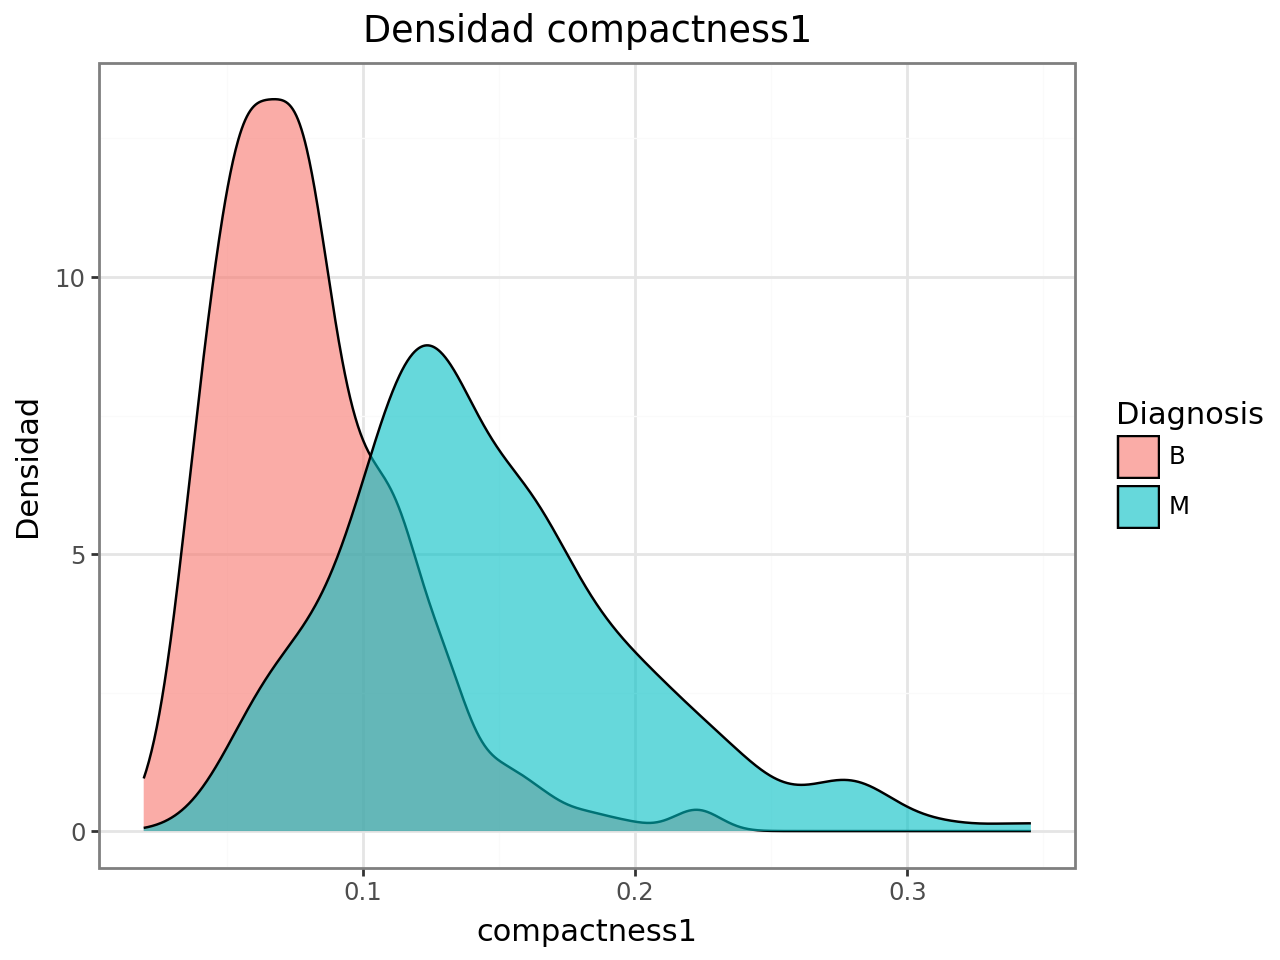

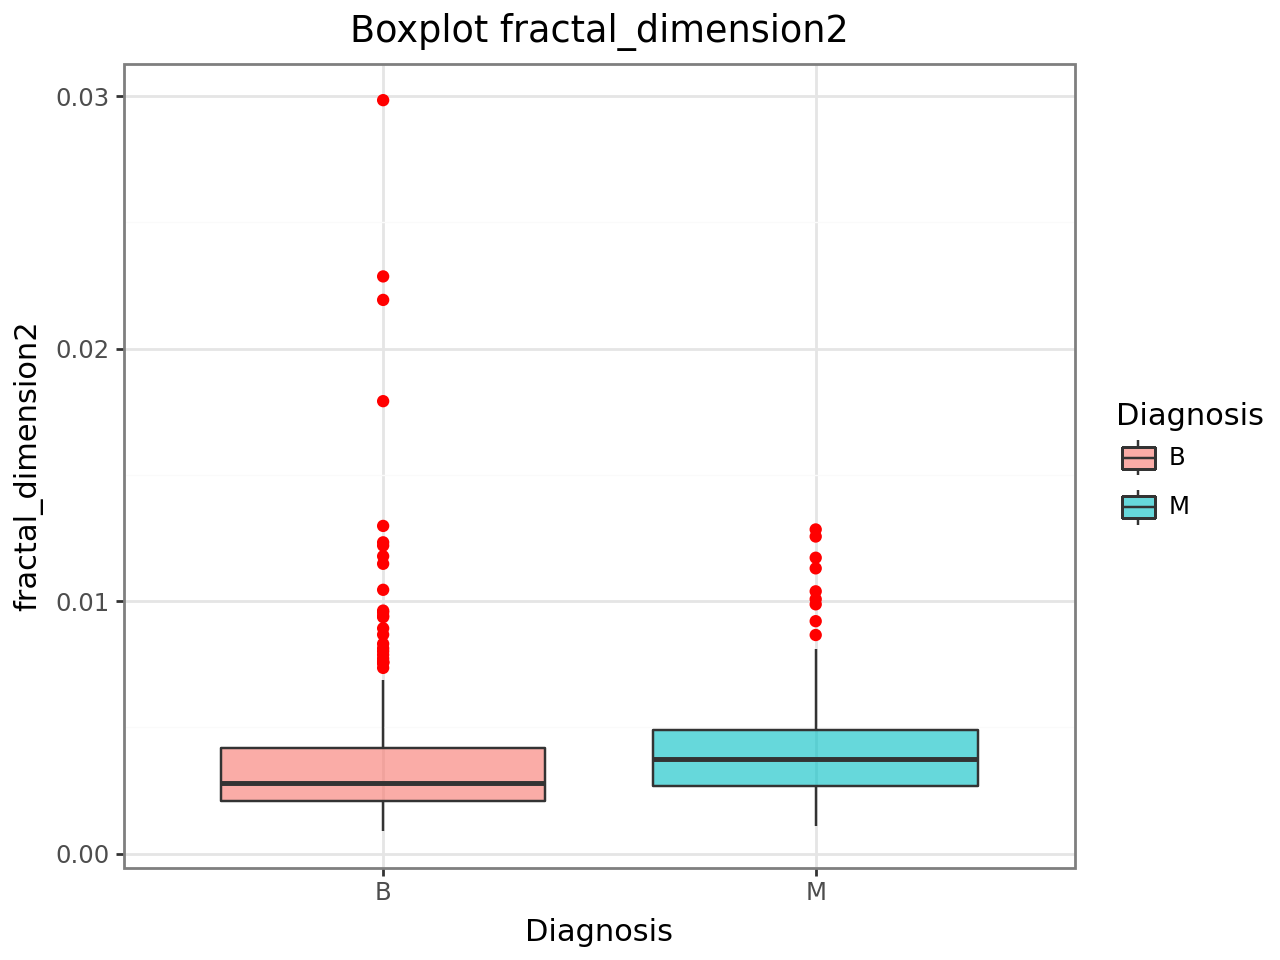

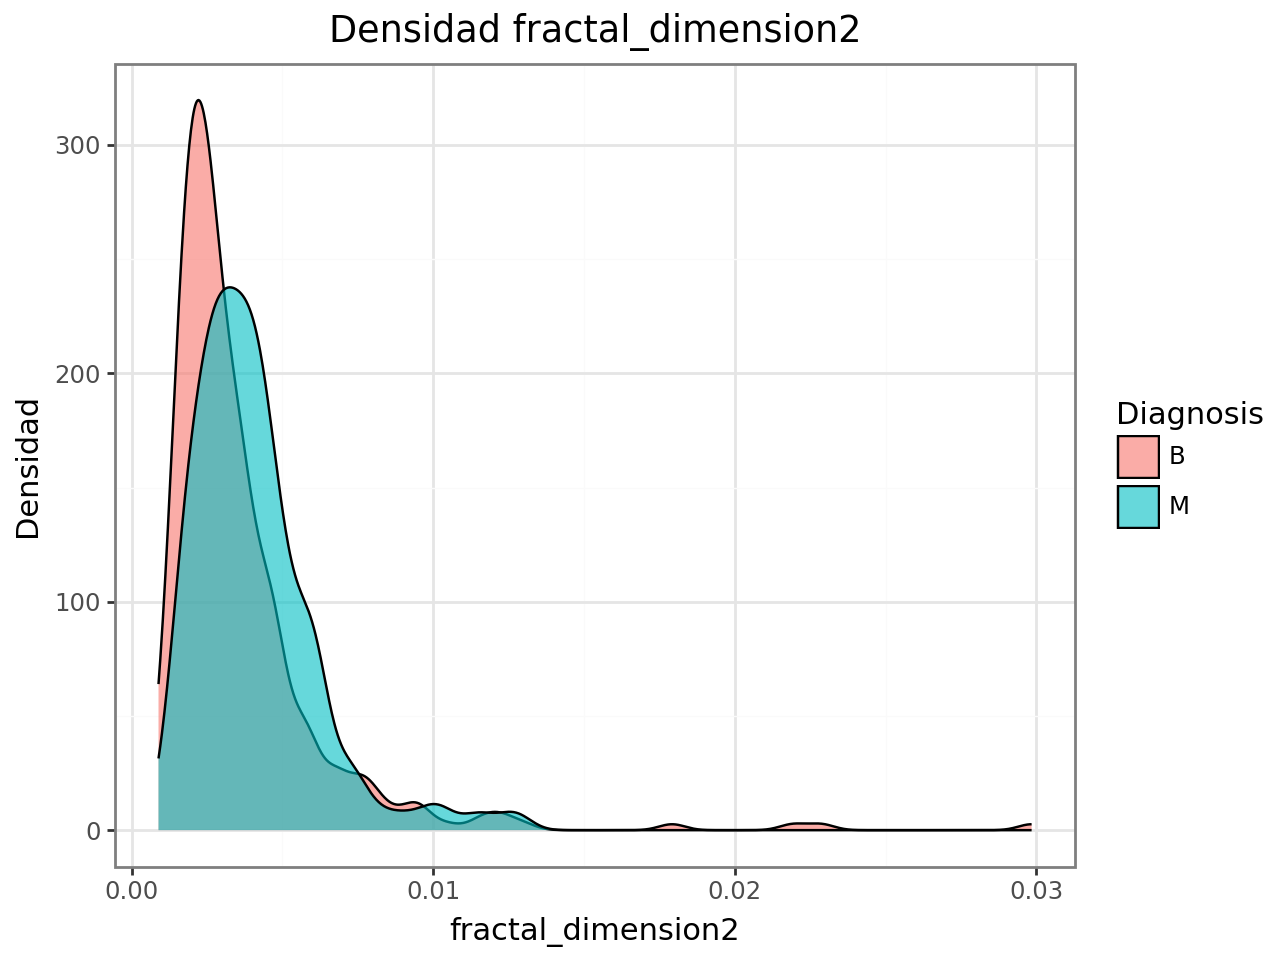

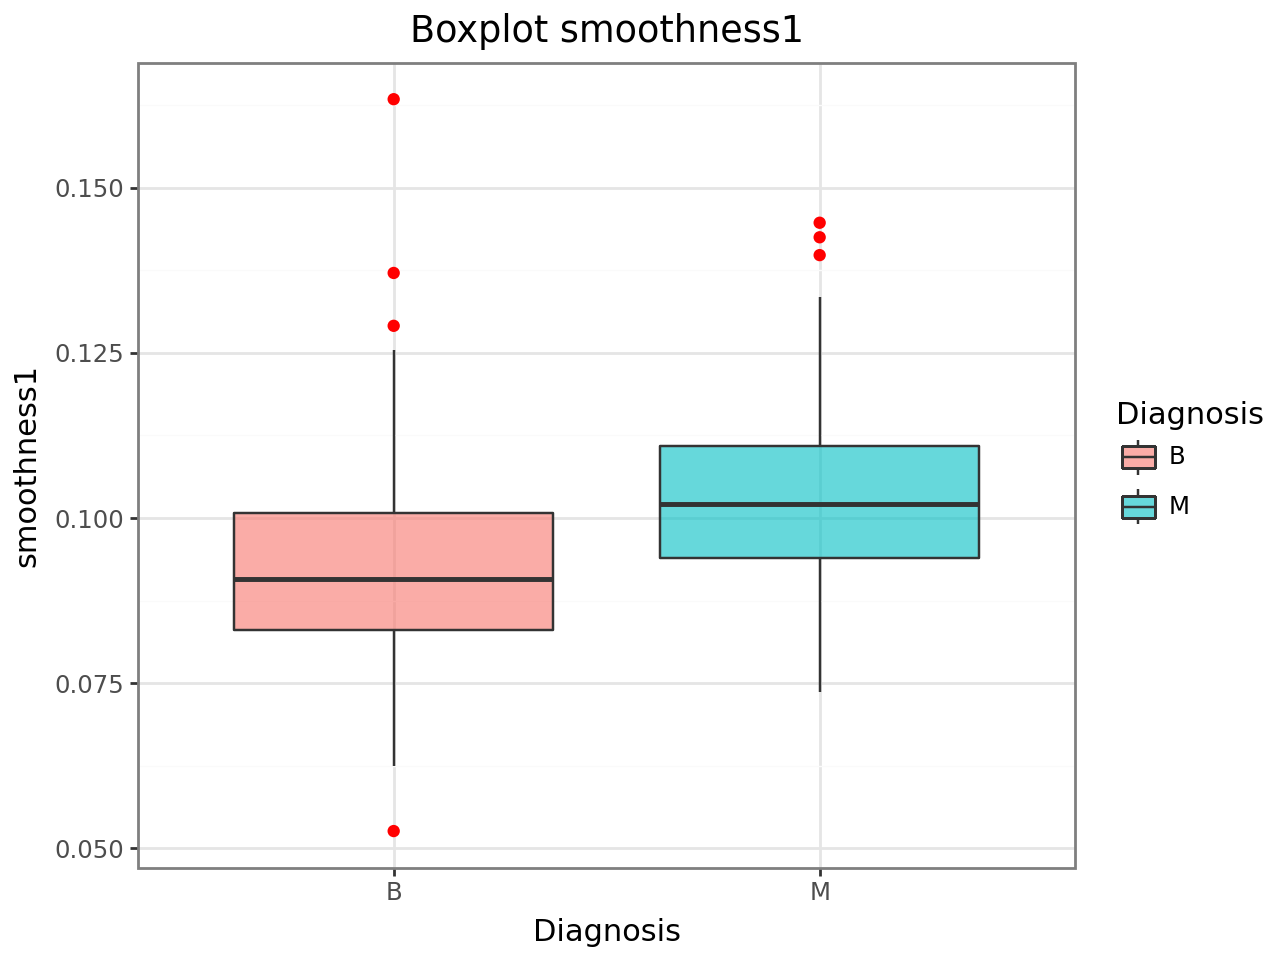

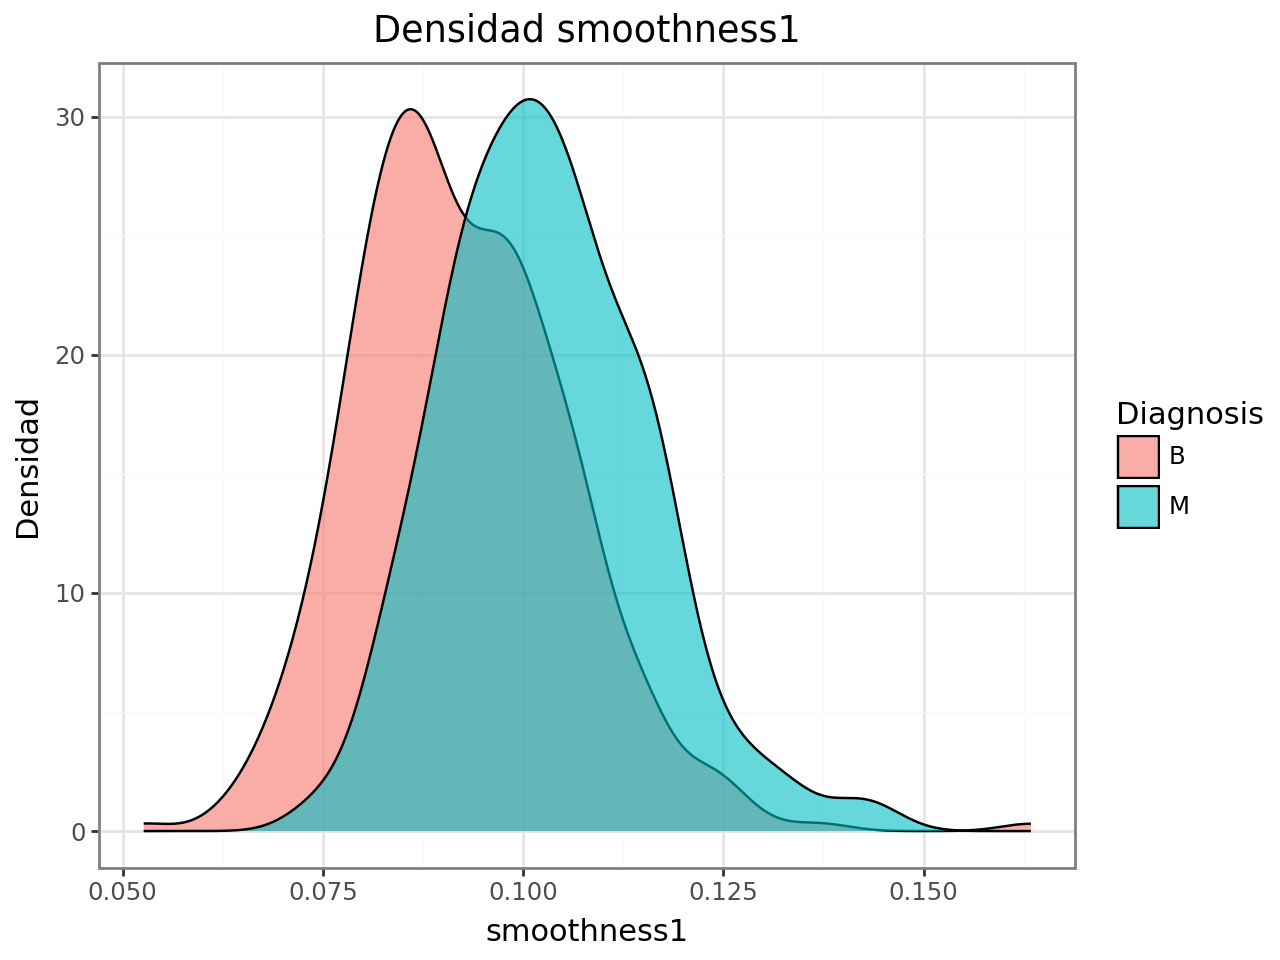

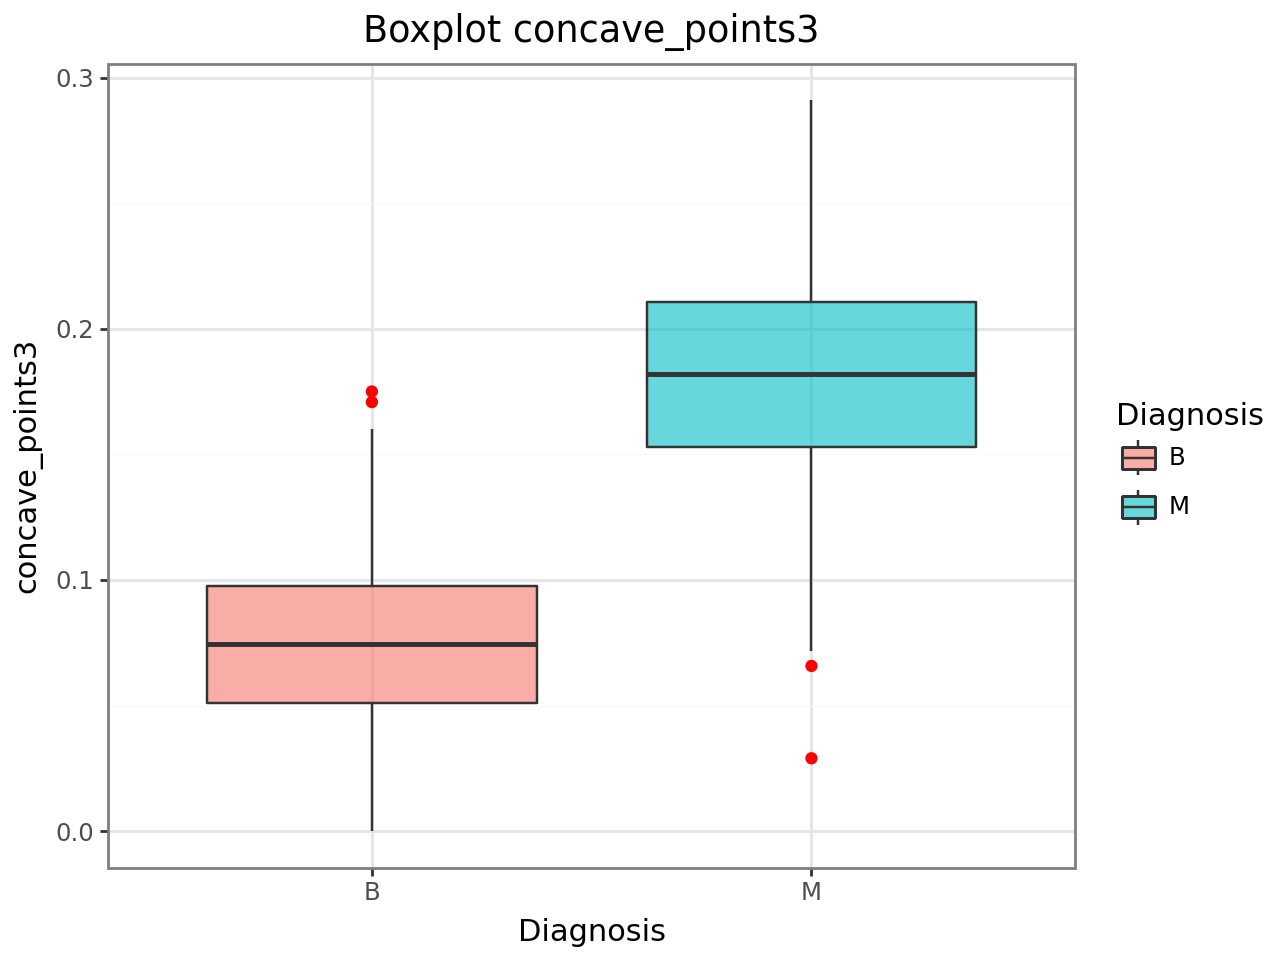

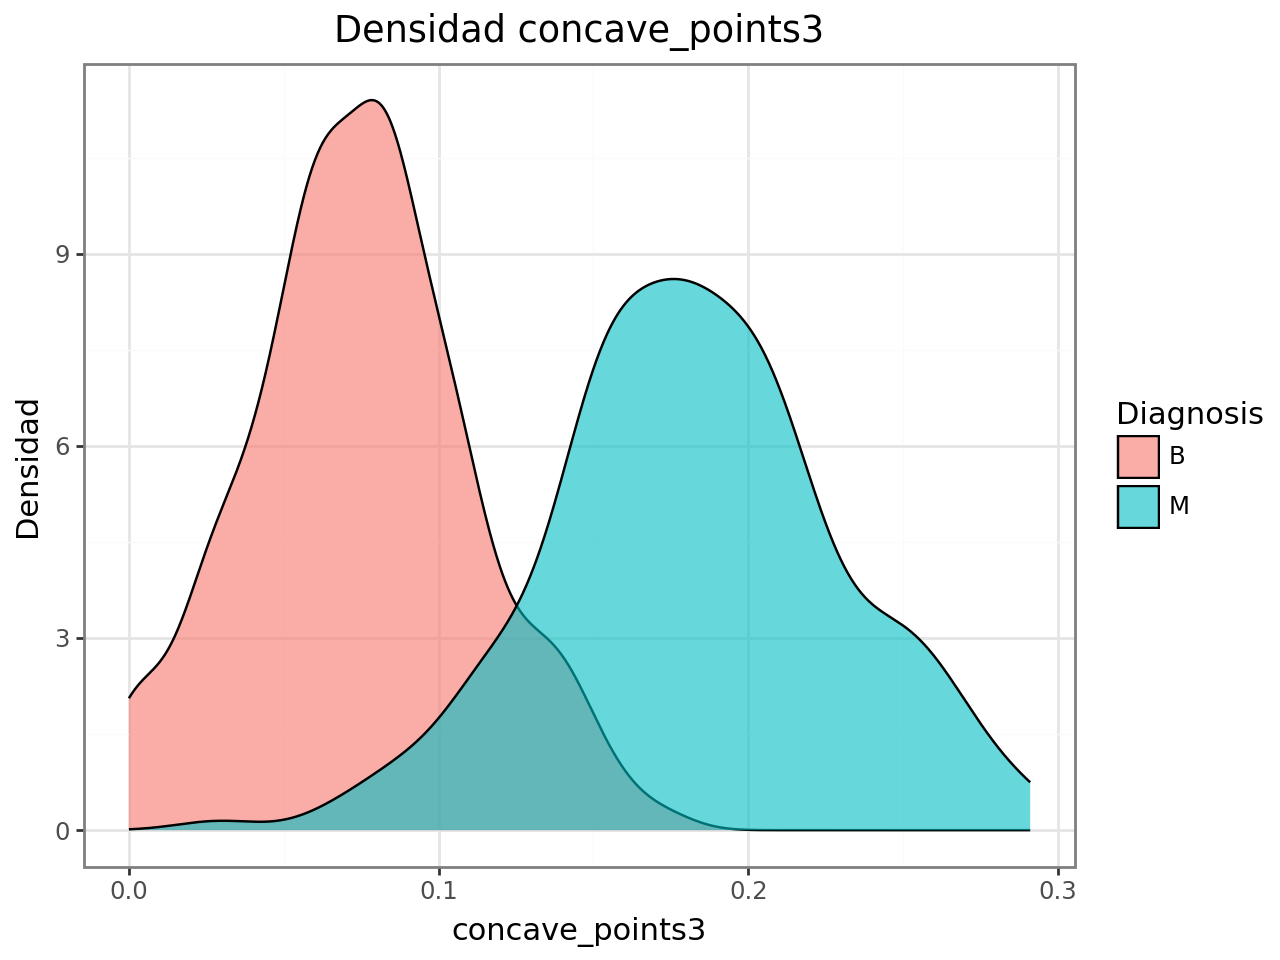

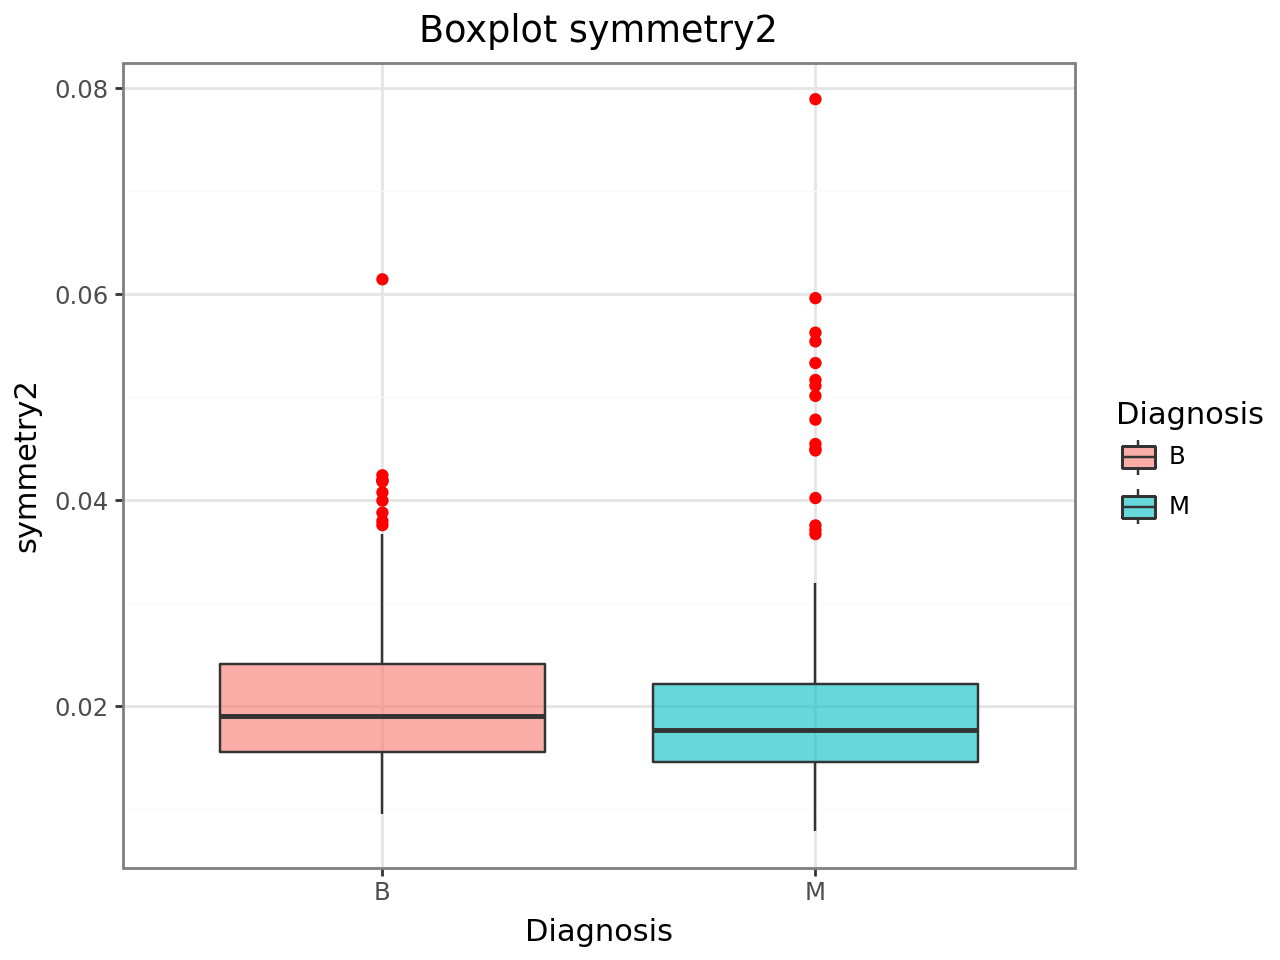

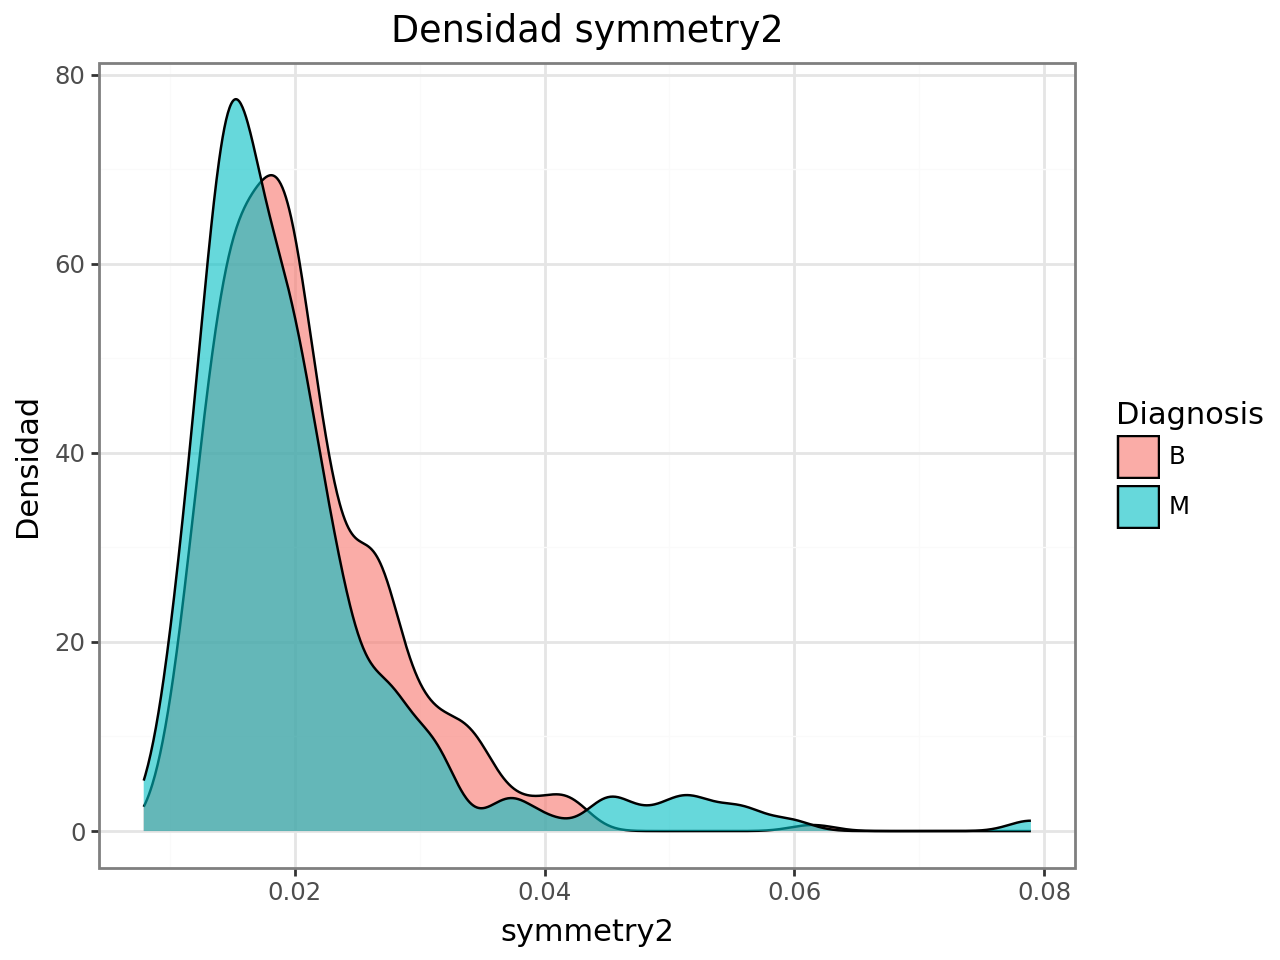

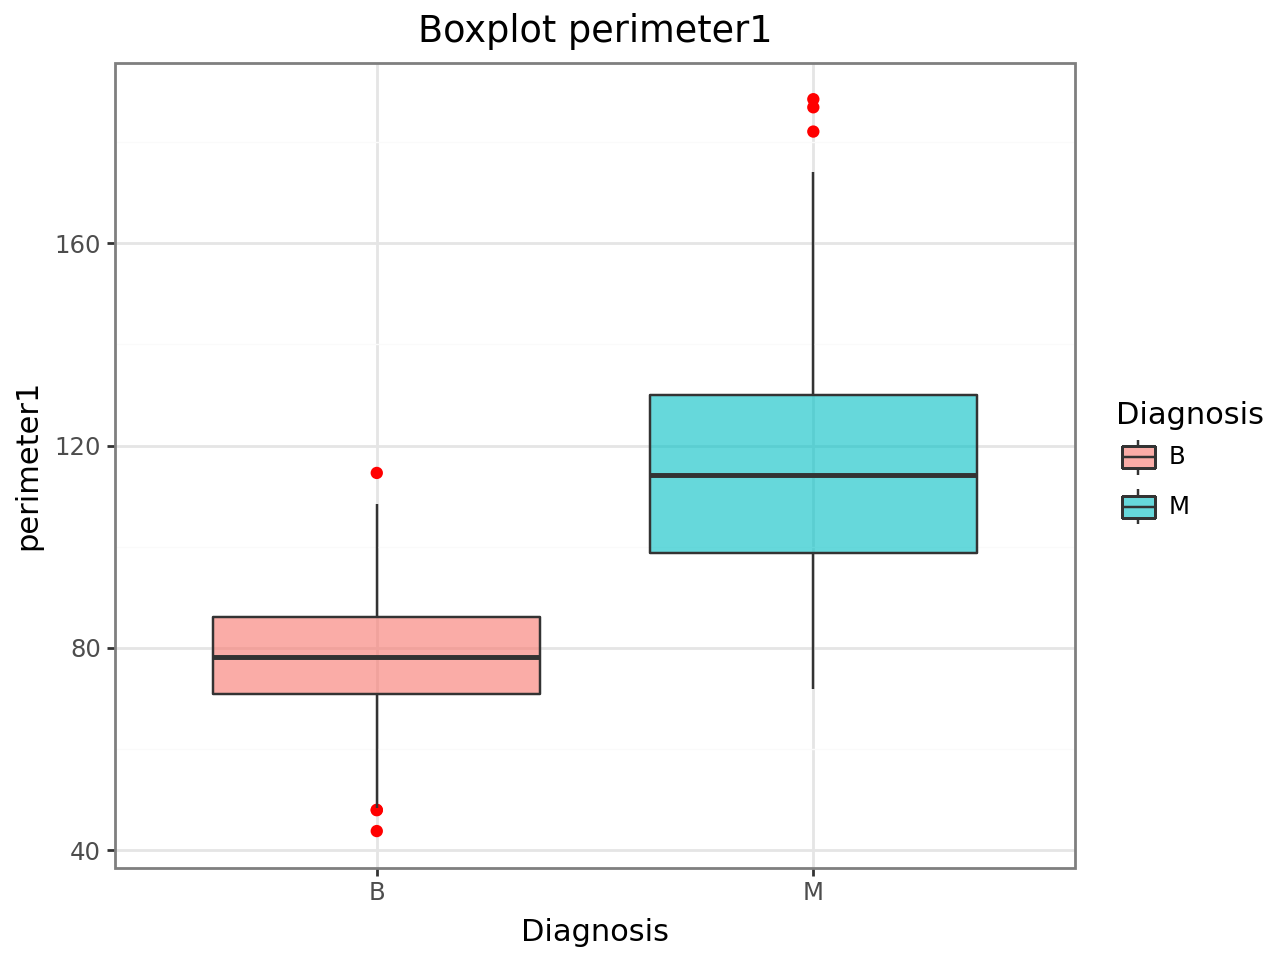

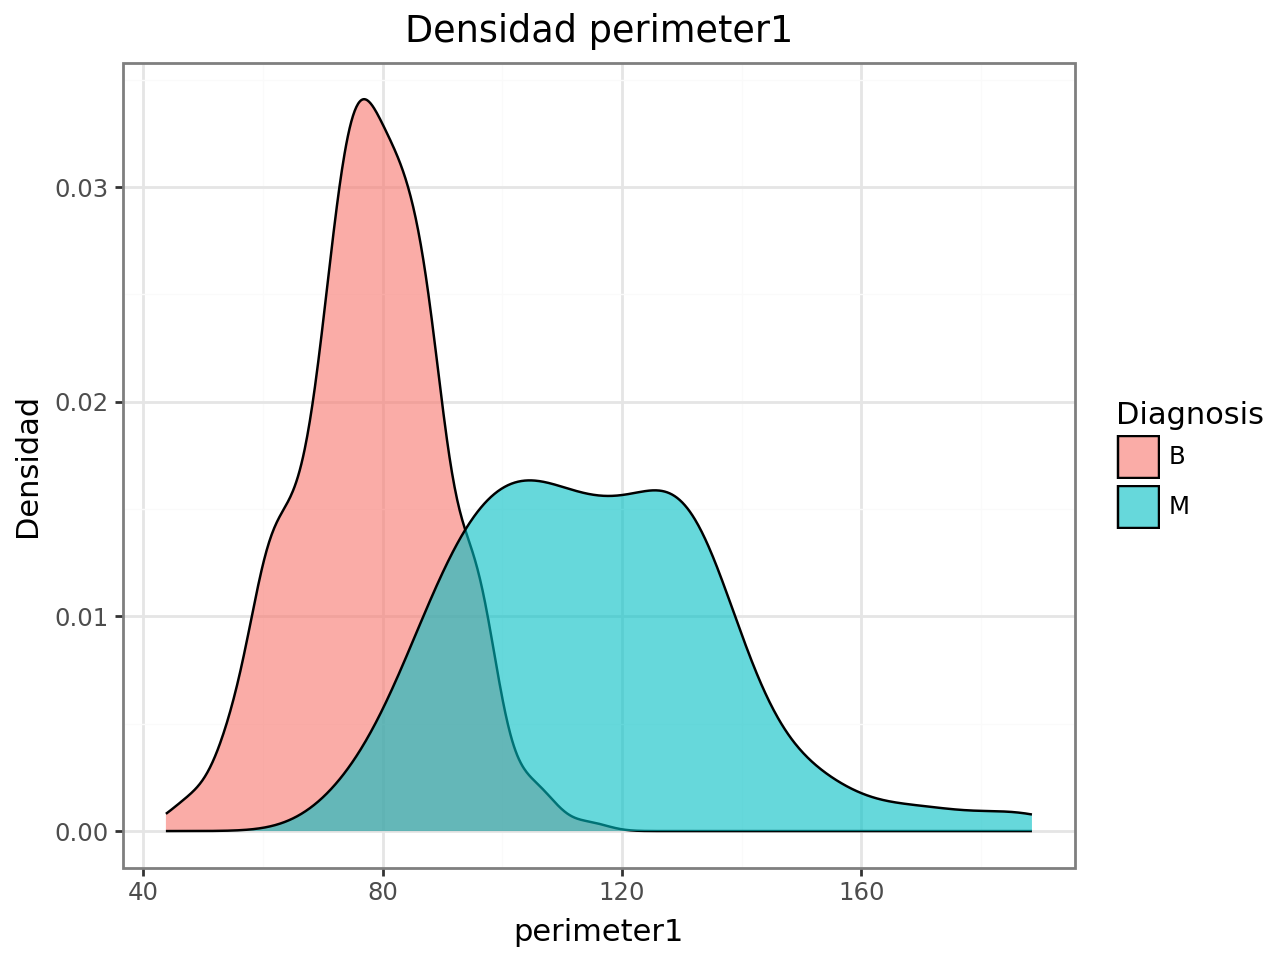

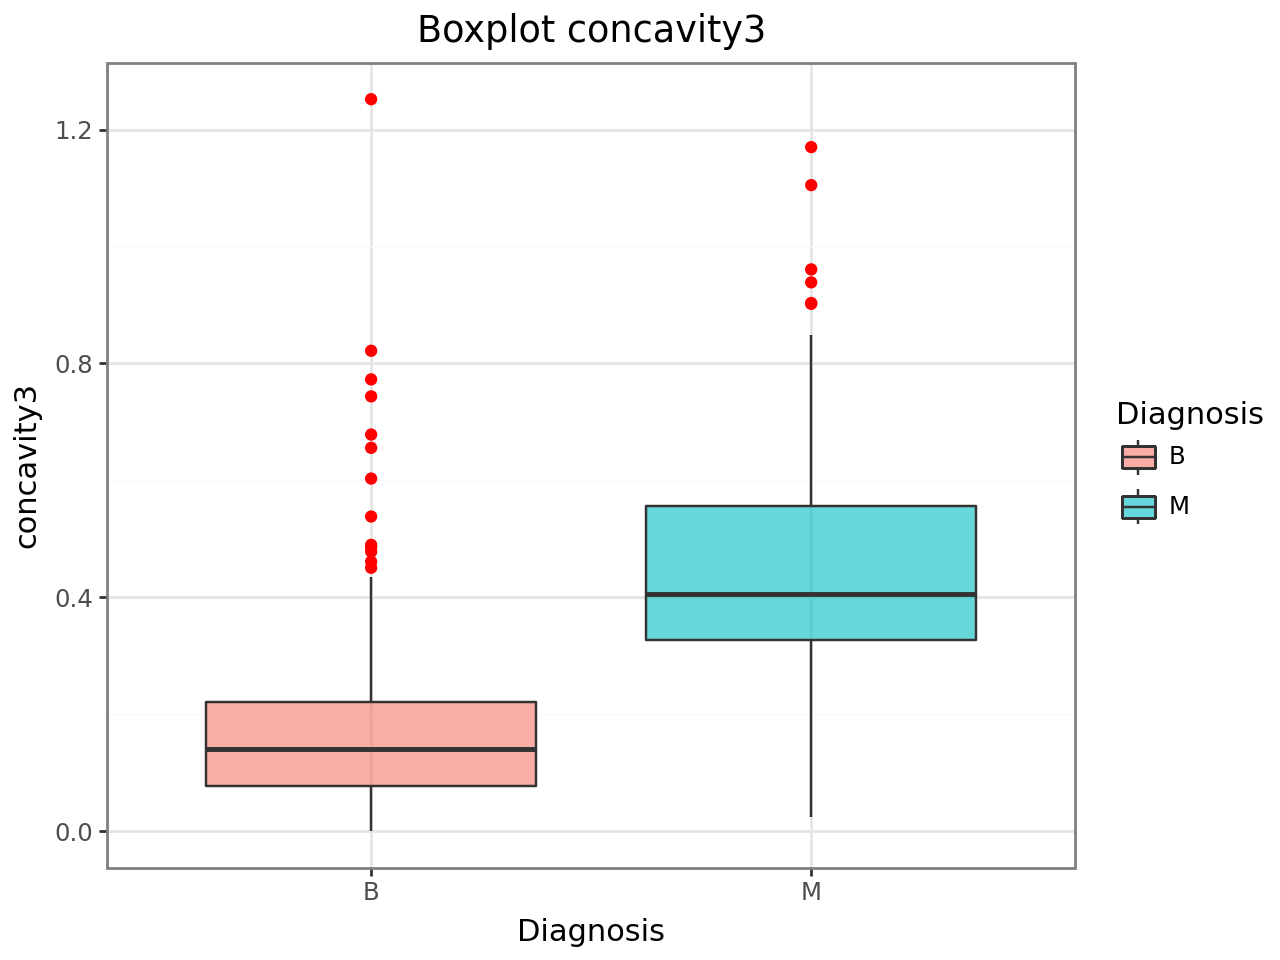

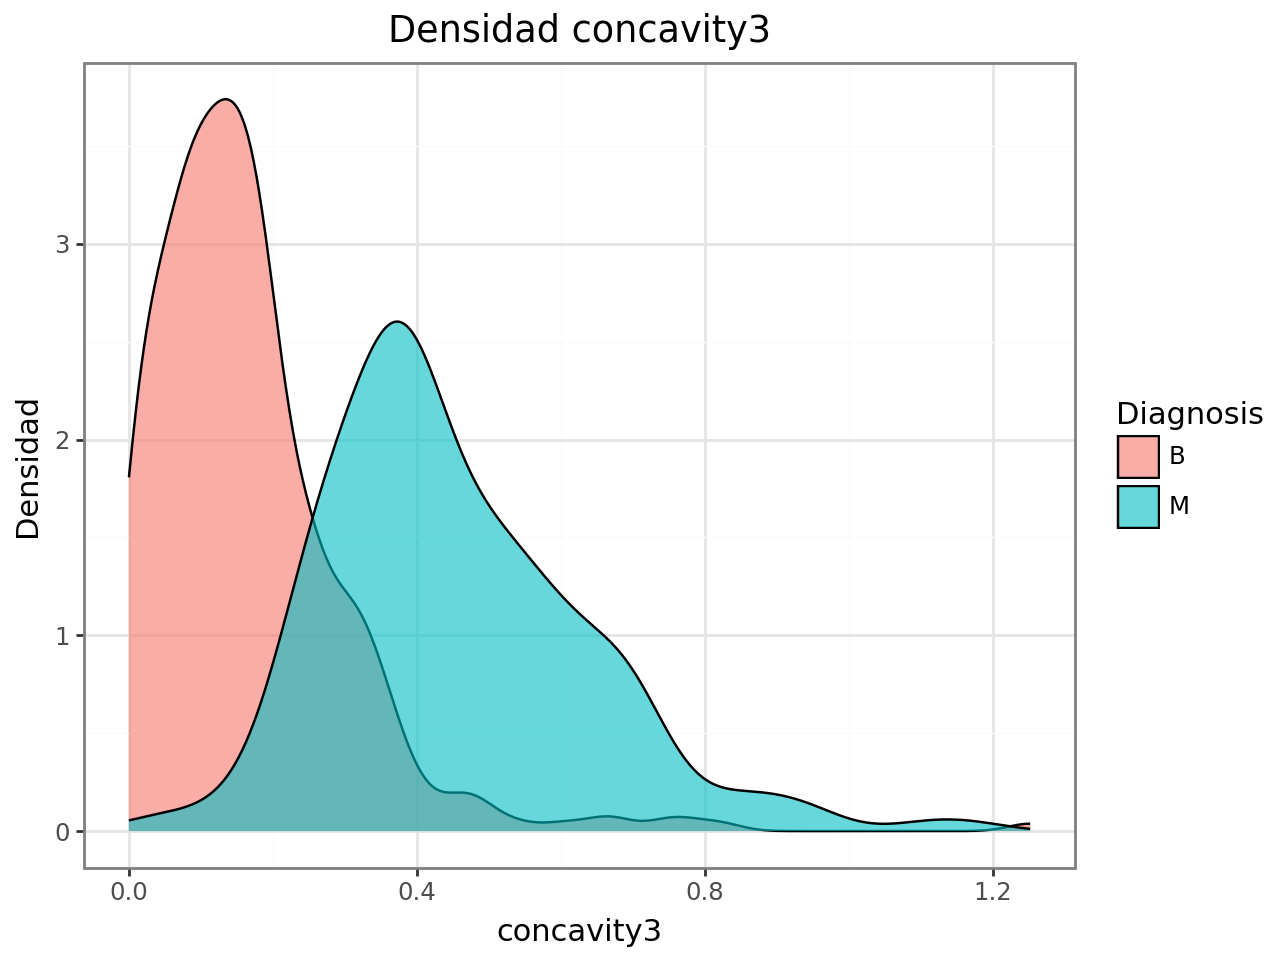

In [12]:
analisis.plot_num("Diagnosis")

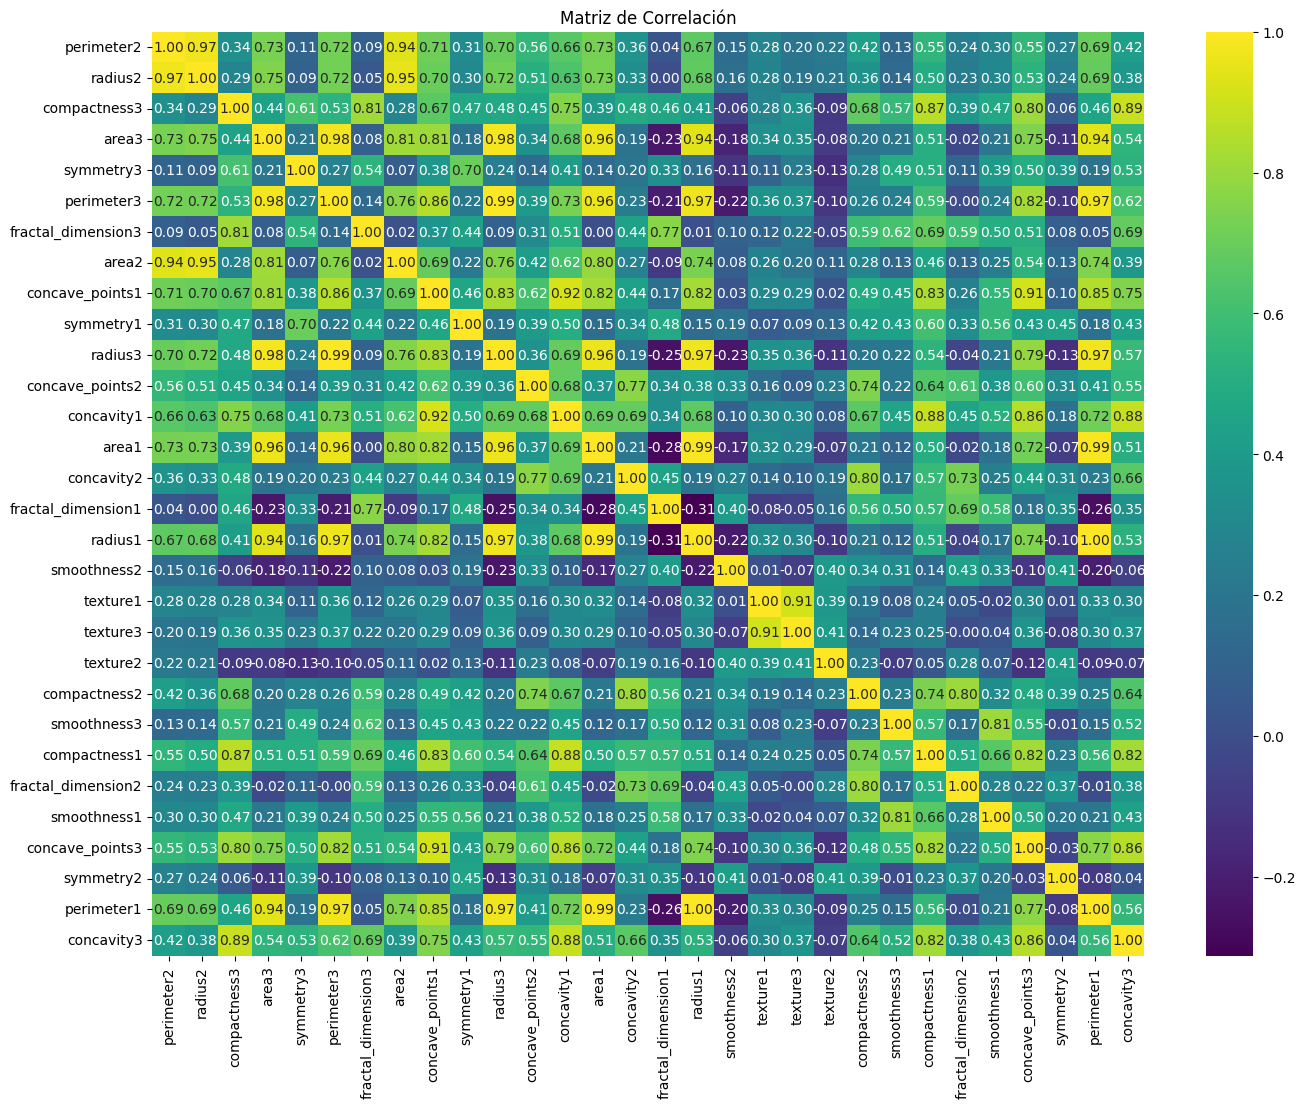

In [13]:
analisis.corr_matrix()

In [14]:
#Definimos la Curva de Andrews escalada
def andrews_curve_scaled(df):
    palette = ["#670067", "#006700"]
    df_aux = df.copy()
    
    #Escalamos solo las columnas numéricas
    numeric_cols = df_aux.select_dtypes(include=['float64', 'int64']).columns
    scaler = MinMaxScaler()
    df_aux[numeric_cols] = scaler.fit_transform(df_aux[numeric_cols])
    
    plt.figure(figsize=(12,8))
    andrews_curves(df_aux, "Diagnosis", colormap=ListedColormap(palette), alpha=0.6)
    plt.title("Curvas de Andrews")
    plt.xlabel("t (función de Fourier)")
    plt.ylabel("Valor transformado")
    plt.grid(True, color="lightgray", linestyle="--", linewidth=0.5)
    plt.show()

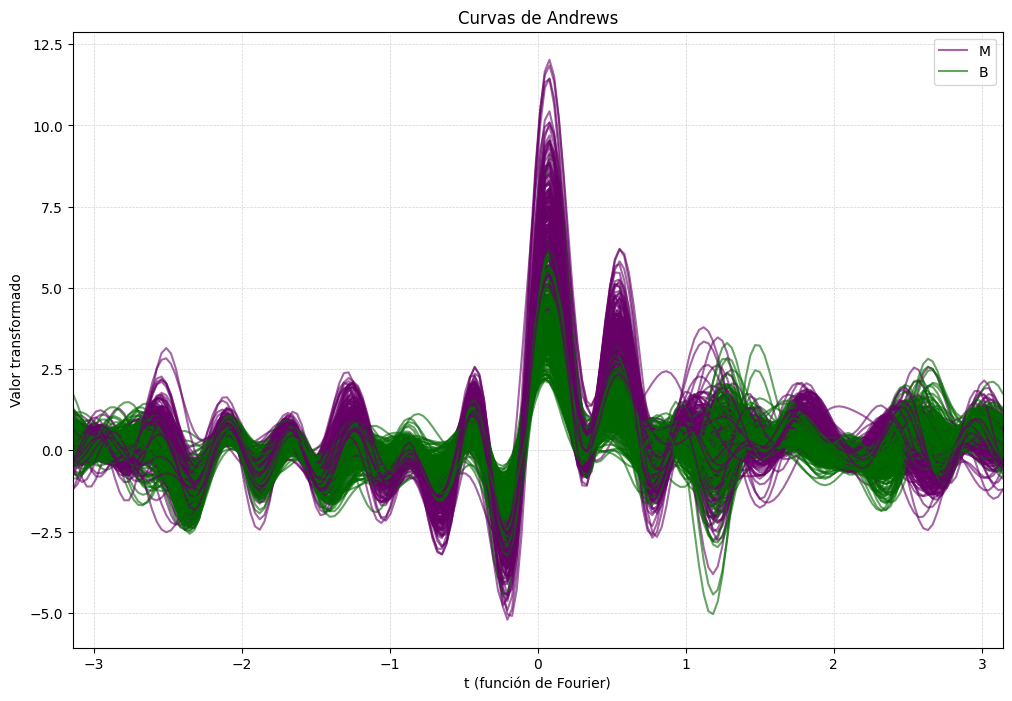

In [15]:
andrews_curve_scaled(df)

### Valores atípicos

In [16]:
#Usaremos minima covarianza
def outliers_mcd(df, contamination=0.05, random_state=1989, support_fraction=None):
    model = MCD(contamination=contamination, random_state=random_state, support_fraction=support_fraction)
    model.fit(df)
    preds = model.predict(df)
    return df[preds == 1]  #detectar

In [17]:
df_outliers = outliers_mcd(df[var_num])

#Visualizamos en el df original
df.loc[df_outliers.index]

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.990,10.380,122.800,"1,001.000",0.118,0.278,0.300,0.147,0.242,0.079,...,17.330,184.600,"2,019.000",0.162,0.666,0.712,0.265,0.460,0.119,M
12,19.170,24.800,132.400,"1,123.000",0.097,0.246,0.206,0.112,0.240,0.078,...,29.940,151.700,"1,332.000",0.104,0.390,0.364,0.177,0.318,0.102,M
18,19.810,22.150,130.000,"1,260.000",0.098,0.103,0.148,0.095,0.158,0.054,...,30.880,186.800,"2,398.000",0.151,0.315,0.537,0.239,0.277,0.076,M
23,21.160,23.040,137.200,"1,404.000",0.094,0.102,0.110,0.086,0.177,0.053,...,35.590,188.000,"2,615.000",0.140,0.260,0.316,0.201,0.282,0.075,M
24,16.650,21.380,110.000,904.600,0.112,0.146,0.152,0.092,0.200,0.063,...,31.560,177.000,"2,215.000",0.180,0.358,0.469,0.209,0.361,0.096,M
68,9.029,17.330,58.790,250.500,0.107,0.141,0.313,0.044,0.211,0.080,...,22.650,65.500,324.700,0.148,0.436,1.252,0.175,0.423,0.117,B
71,8.888,14.640,58.790,244.000,0.098,0.153,0.086,0.029,0.190,0.090,...,15.670,62.560,284.400,0.121,0.244,0.143,0.048,0.225,0.108,B
77,18.050,16.150,120.200,"1,006.000",0.106,0.215,0.168,0.108,0.215,0.067,...,18.910,150.100,"1,610.000",0.148,0.563,0.379,0.210,0.375,0.111,M
78,20.180,23.970,143.700,"1,245.000",0.129,0.345,0.375,0.160,0.291,0.081,...,31.720,170.300,"1,623.000",0.164,0.616,0.768,0.251,0.544,0.100,M
83,19.100,26.290,129.100,"1,132.000",0.121,0.179,0.194,0.147,0.163,0.072,...,32.720,141.300,"1,298.000",0.139,0.282,0.243,0.184,0.231,0.092,M


In [18]:
#Eliminamos los atipicos
df.drop(df_outliers.index, inplace=True)

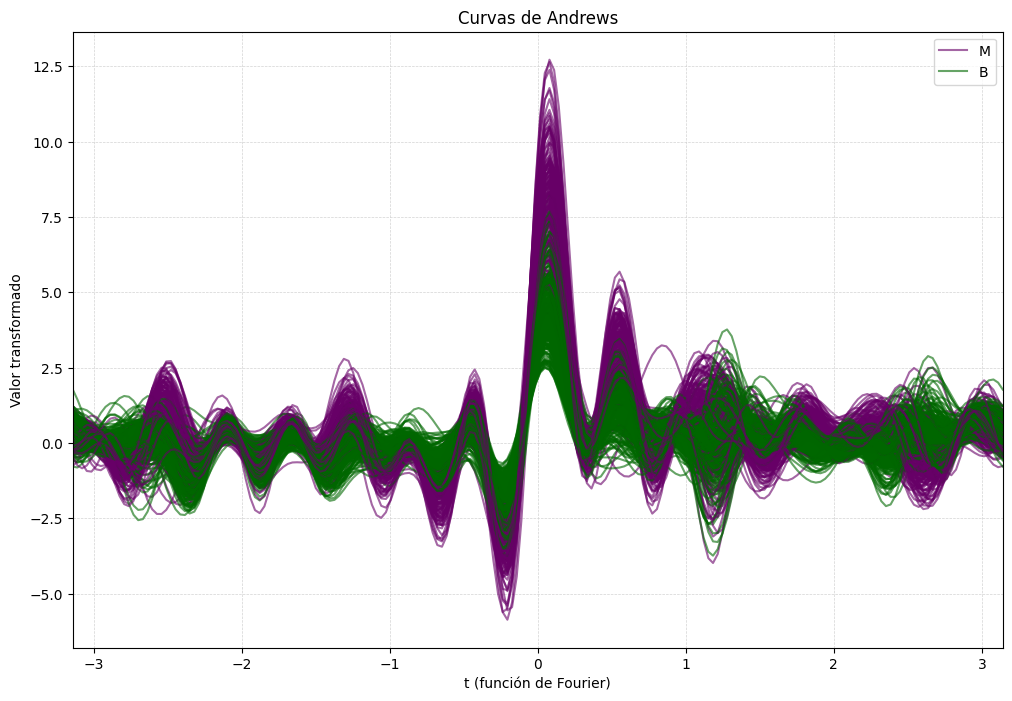

In [19]:
andrews_curve_scaled(df)

De lo anterior podemos decir lo siguiente:

    * Existen valores atípicos.

    * Hay múltiples variables que miden lo mismo.

    * Las clases están desbalanceadas.

## Modelado

#### Train/test split

In [20]:
df["Diagnosis"] = df["Diagnosis"].map(lambda x: 1 if x == "M" else 0)

In [21]:
y = df["Diagnosis"]
X = df.drop(columns = ["Diagnosis"])


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1989, stratify = y)

#### Escalamiento

In [23]:
scaler = StandardScaler()

In [24]:
#Ajustamos solo con train
scaler.fit(X_train)

#Transformar train y test
X_train[var_num] = scaler.fit_transform(X_train[var_num])
X_test[var_num] = scaler.transform(X_test[var_num])

#### PCA

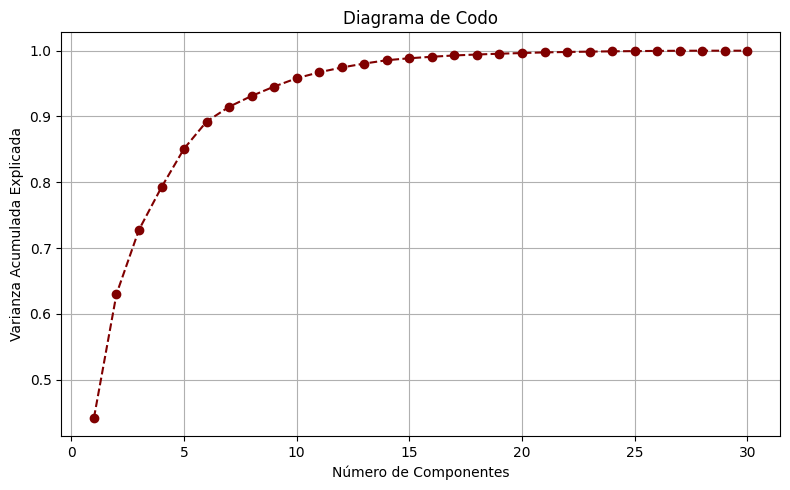

In [25]:
pca_temp = PCA().fit(X_train)
var_exp = pca_temp.explained_variance_ratio_
cum_var_exp = var_exp.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_exp) + 1), cum_var_exp, marker='o', linestyle='--', color='maroon')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Diagrama de Codo')
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
#Elegimos 7 componentes principales
pca = PCA(n_components=7)

X_train = pd.DataFrame(pca.fit_transform(X_train), columns=[f'p_{i}' for i in range(len(pca.explained_variance_ratio_))])
X_test = pd.DataFrame(pca.transform(X_test), columns=[f'p_{i}' for i in range(len(pca.explained_variance_ratio_))])


In [27]:
X_train

,p_0,p_1,p_2,p_3,p_4,p_5,p_6
0,6.081,-2.034,-0.967,0.034,-0.330,-0.558,0.151
1,-2.310,-0.044,-1.050,0.286,-0.163,0.859,0.175
2,4.943,2.985,-0.035,1.648,0.545,-1.533,1.062
3,-2.102,0.833,-1.084,1.258,0.117,-1.454,-0.098
4,-3.334,-0.967,-1.410,-1.501,0.310,-0.729,0.131
...,...,...,...,...,...,...,...
373,0.988,0.450,-0.369,1.878,0.509,-0.691,1.329
374,-3.866,0.637,0.874,0.496,0.291,-0.077,-0.477
375,-0.591,0.037,-3.036,0.221,-0.623,-0.544,0.168
376,0.078,0.128,-0.471,0.403,1.786,-0.276,0.181


In [28]:
X_test

,p_0,p_1,p_2,p_3,p_4,p_5,p_6
0,-4.925,-0.630,0.281,-1.711,1.055,1.068,-0.261
1,-2.288,-2.599,0.193,2.327,1.049,0.450,0.447
2,0.473,-0.171,0.413,0.954,3.357,0.450,0.450
3,-0.832,-1.745,-0.422,1.109,1.672,0.067,0.064
4,-2.770,0.156,1.875,-1.950,1.584,2.347,-0.634
...,...,...,...,...,...,...,...
157,-1.897,-2.101,-1.269,1.495,0.252,0.804,0.196
158,-2.918,-0.793,0.228,-0.587,-0.852,0.406,-0.092
159,-1.470,2.551,1.216,-1.320,1.173,-0.894,0.646
160,-2.126,-1.445,0.158,1.217,0.382,-1.417,0.150


### Modelos

In [29]:
#Función auxiliar para métricas
def compute_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y_true, y_proba)
    return acc, sens, spec, auc

In [30]:
#Espacios de búsqueda
param_dist = {
    'linear': {'C': np.logspace(-3, 3, 20)},
    'poly': {
        'C': np.logspace(-3, 3, 20),
        'degree': [2, 3, 4, 5],
        'gamma': ['scale', 'auto'],
        'coef0': np.linspace(0, 1, 5)
    },
    'rbf': {
        'C': np.logspace(-3, 3, 20),
        'gamma': ['scale', 'auto'] + list(np.logspace(-3, 2, 10))
    },
    'sigmoid': {
        'C': np.logspace(-3, 3, 20),
        'gamma': ['scale', 'auto'] + list(np.logspace(-3, 2, 10)),
        'coef0': np.linspace(0, 1, 5)
    }
}

In [31]:
results = []

for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    print(f"\nEntrenando kernel: {kernel.upper()}")
    
    svc = SVC(kernel=kernel, probability=True)
    random_search = RandomizedSearchCV(
        svc,
        param_distributions=param_dist[kernel],
        n_iter=28,
        scoring='roc_auc',
        cv=5,
        random_state=1989,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    
    # Predicciones
    y_pred_train = best_model.predict(X_train)
    y_proba_train = best_model.predict_proba(X_train)[:, 1]
    y_pred_test = best_model.predict(X_test)
    y_proba_test = best_model.predict_proba(X_test)[:, 1]

    # Métricas
    acc_train, sens_train, spec_train, auc_train = compute_metrics(y_train, y_pred_train, y_proba_train)
    acc_test, sens_test, spec_test, auc_test = compute_metrics(y_test, y_pred_test, y_proba_test)
    
    results.append({
        'Kernel': kernel,
        'Best Params': random_search.best_params_,
        'Train_Accuracy': acc_train,
        'Test_Accuracy': acc_test,
        'Train_Sensitivity': sens_train,
        'Test_Sensitivity': sens_test,
        'Train_Specificity': spec_train,
        'Test_Specificity': spec_test,
        'Train_AUC': auc_train,
        'Test_AUC': auc_test
    })



Entrenando kernel: LINEAR


c:\Users\raulb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:318: UserWarning: The total space of parameters 20 is smaller than n_iter=28. Running 20 iterations. For exhaustive searches, use GridSearchCV.



Entrenando kernel: POLY

Entrenando kernel: RBF

Entrenando kernel: SIGMOID


In [32]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Test_AUC', ascending=False).reset_index(drop=True)
display(df_results)

,Kernel,Best Params,Train_Accuracy,Test_Accuracy,Train_Sensitivity,Test_Sensitivity,Train_Specificity,Test_Specificity,Train_AUC,Test_AUC
0,poly,"{'gamma': 'scale', 'degree': 2, 'coef0': 1.0, ...",0.979,0.975,0.962,0.964,0.988,0.981,0.996,0.998
1,rbf,"{'gamma': 0.003593813663804626, 'C': 26.366508...",0.974,0.975,0.947,0.964,0.988,0.981,0.995,0.997
2,sigmoid,"{'gamma': 0.003593813663804626, 'coef0': 0.75,...",0.963,0.975,0.939,0.982,0.976,0.972,0.983,0.997
3,linear,{'C': 0.07847599703514611},0.976,0.975,0.962,0.964,0.984,0.981,0.995,0.996


In [33]:
print("\n Búsqueda completa. Mejor kernel según AUC de prueba:")
print(df_results.iloc[0])


 Búsqueda completa. Mejor kernel según AUC de prueba:
Kernel                                                            poly
Best Params          {'gamma': 'scale', 'degree': 2, 'coef0': 1.0, ...
Train_Accuracy                                                   0.979
Test_Accuracy                                                    0.975
Train_Sensitivity                                                0.962
Test_Sensitivity                                                 0.964
Train_Specificity                                                0.988
Test_Specificity                                                 0.981
Train_AUC                                                        0.996
Test_AUC                                                         0.998
Name: 0, dtype: object


In [34]:
df_results.iloc[0][1]

C:\Users\raulb\AppData\Local\Temp\ipykernel_24052\1780099035.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


{'gamma': 'scale',
 'degree': 2,
 'coef0': np.float64(1.0),
 'C': np.float64(1.438449888287663)}

## Vista de margen

In [45]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets

df = pd.concat([X,y], axis = 1)
df["Diagnosis"] = df["Diagnosis"].map(lambda x: 1 if x == "M" else 0)

In [46]:
y = df["Diagnosis"]
X = df.drop(columns = ["Diagnosis"])

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1989, stratify = y)

In [49]:
scaler = StandardScaler()
pca_2d = PCA(n_components=2)

# Ajustamos sobre todo el entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_pca = pca_2d.fit_transform(X_train_scaled)
X_test_pca = pca_2d.transform(X_test_scaled)

In [50]:
svm_best = SVC(
    kernel='poly',
    C=1.438449888287663,
    gamma='scale',
    degree=2,
    coef0=1.0,
    probability=True
)
svm_best.fit(X_train_pca, y_train)

SVC(C=1.438449888287663, coef0=1.0, degree=2, kernel='poly', probability=True)

In [56]:
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

Z = svm_best.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Colores para regiones y puntos
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold_train = ['#FF0000', '#00AA00']  # train
cmap_bold_test = ['#FF6666', '#66FF66']   # test

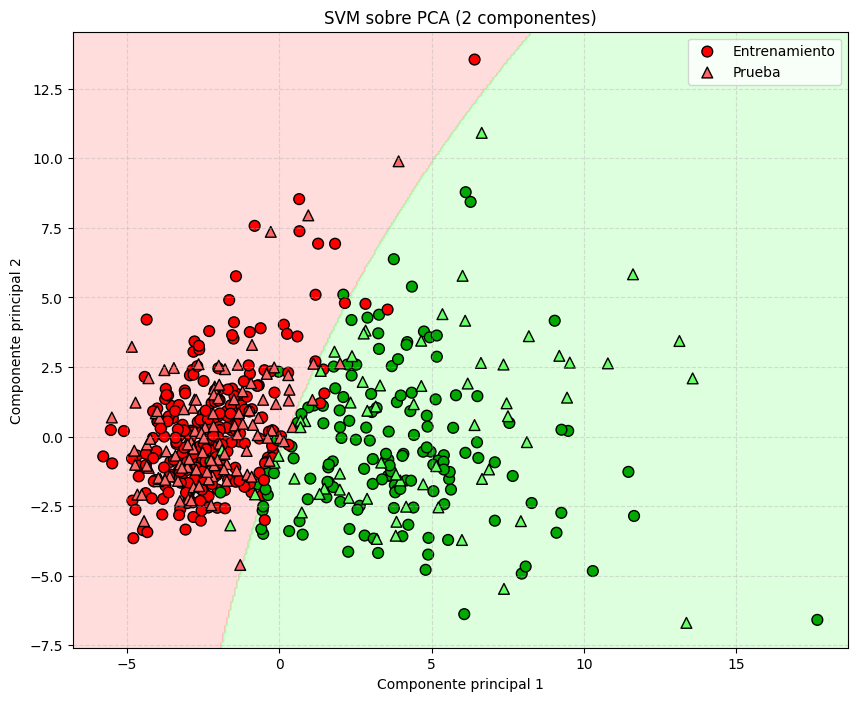

In [57]:
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)

# puntos de entrenamiento
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            c=y_train, cmap=ListedColormap(cmap_bold_train),
            edgecolor='k', s=60, label='Entrenamiento')

# puntos de prueba
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            c=y_test, cmap=ListedColormap(cmap_bold_test),
            edgecolor='k', s=60, marker='^', label='Prueba')

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('SVM sobre PCA (2 componentes)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()